# 2026-09-02 Combined-galaxy SF, ND, and NSF fractions by infall stage

This notebook replaces the individual-galaxy displays in the three 2026-09-01 notebooks with combined-galaxy curves. It keeps the same live files, inclination cut, valid-disc footprint, original SF mask, and Balmer-only category partition.

Four samples are shown side by side: **pre-peak**, **close-to-peak**, **post-peak**, and **all three stages together**. Each is measured along both $\log_{10}\Sigma_\star$ and $R/R_e$.

Two estimators are kept separate:

1. **Pooled spaxels (normal sum)**
   $$f_{c,b}^{\rm pooled}=\frac{\sum_g N_{c,g,b}}{\sum_g N_{{\rm valid},g,b}}.$$
   A galaxy with more available spaxels in bin $b$ contributes more.

2. **Equal galaxies within every bin**
   $$f_{c,b}^{\rm equal}=\frac{1}{G_b}\sum_{g\in b}\frac{N_{c,g,b}}{N_{{\rm valid},g,b}}.$$
   Equivalently, every usable spaxel of galaxy $g$ receives $w_{igb}=1/N_{{\rm valid},g,b}$, so each included galaxy has total weight one **inside that bin**. The counts are recomputed independently for every $\Sigma_\star$ and $R/R_e$ bin.

Here $c\in\{\mathrm{SF},\mathrm{ND},\mathrm{NSF}\}$. ND means H$\alpha$ or H$\beta$ fails the pipeline detection requirement. NSF means both Balmer lines are detected but the unchanged SF selection fails; it is not a physical claim that star formation is absent.

## 1. Configuration, provenance, and shared helpers

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_EDGES = np.linspace(6.0, 10.0, 13)
R_EDGES = np.arange(0.0, 1.6 + 0.2, 0.2)
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: all three infall-stage classes, science-ready primary sample with inclination < 80 deg")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: all three infall-stage classes, science-ready primary sample with inclination < 80 deg
No additional inclination correction is applied to either surface-density map.


The helper definitions below are copied from the live pre-peak source notebook. The close-to-peak and post-peak notebooks use the same definitions. In particular, the SF mask is unchanged and ND/NSF depend only on H$\alpha$/H$\beta$ detection after the valid-disc mask is set.

In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    shapes = {a.shape for a in (mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr)}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 2. Live three-stage inventory and quality control

In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_SF": int(maps["sf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")


Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


,GALID,components,stage,inclination_deg,N_valid,N_SF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,13897,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,3273,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,471,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,64097,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,31915,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                         
close-to-peak  OK                                                                                   5
post-peak      OK                                                                                  13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product     3
pre-peak       OK                                                                                   8
Name: N_galaxies, dtype: int64

## 3. Common bins and per-galaxy category counts

The bin widths follow the source notebooks: $1/3$ dex in $\log_{10}\Sigma_\star$ and 0.2 in $R/R_e$. The endpoints are aligned to the complete finite range of the passing live sample, rather than applying a percentile cut. Every valid pixel must land in exactly one bin for each variable.

In [4]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


SIGMA_BIN_WIDTH = float(np.median(np.diff(SIGMA_EDGES)))
RADIUS_BIN_WIDTH = float(np.median(np.diff(R_EDGES)))
passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}


def count_categories_in_bins(galid, stage, values, maps, edges, variable):
    rows = []
    valid = maps["valid_disc_mask"]
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        masks = {
            "valid": valid & in_bin,
            "SF": maps["sf_mask"] & in_bin,
            "ND": maps["nd_mask"] & in_bin,
            "NSF": maps["nsf_mask"] & in_bin,
        }
        counts = {name: int(mask.sum()) for name, mask in masks.items()}
        assert counts["SF"] + counts["ND"] + counts["NSF"] == counts["valid"]
        rows.append({
            "GALID": galid, "stage": stage, "variable": variable,
            "bin_left": float(lo), "bin_right": float(hi),
            "center": float((lo + hi) / 2),
            "N_valid": counts["valid"], "N_SF": counts["SF"],
            "N_ND": counts["ND"], "N_NSF": counts["NSF"],
        })
    if sum(row["N_valid"] for row in rows) != int(valid.sum()):
        raise AssertionError(f"{galid} {variable}: common bins lost valid pixels")
    return rows


count_rows = []
global_rows = []
for row in sample.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry)
    valid = maps["valid_disc_mask"]
    global_counts = {
        label: int(maps[key].sum()) for label, key in
        (("SF", "sf_mask"), ("ND", "nd_mask"), ("NSF", "nsf_mask"))
    }
    assert sum(global_counts.values()) == int(valid.sum())
    global_rows.append({
        "GALID": row.GALID, "stage": row.stage, "N_valid": int(valid.sum()),
        **{"N_" + label: value for label, value in global_counts.items()},
    })
    for variable, edges in COMMON_EDGES.items():
        count_rows.extend(count_categories_in_bins(
            row.GALID, row.stage, maps[variable], maps, edges, variable
        ))
    del maps

BIN_COUNTS_BY_GALAXY = pd.DataFrame(count_rows)
GLOBAL_COUNTS_BY_GALAXY = pd.DataFrame(global_rows)

expected_rows = len(sample) * sum(len(edges) - 1 for edges in COMMON_EDGES.values())
assert len(BIN_COUNTS_BY_GALAXY) == expected_rows
assert np.array_equal(
    BIN_COUNTS_BY_GALAXY.N_SF + BIN_COUNTS_BY_GALAXY.N_ND
    + BIN_COUNTS_BY_GALAXY.N_NSF,
    BIN_COUNTS_BY_GALAXY.N_valid,
)
print("Common log Sigma_star range:", COMMON_EDGES["log_sigma_star"][[0, -1]])
print("Common R/Re range:", COMMON_EDGES["radius_re"][[0, -1]])
print(f"Per-galaxy/bin count rows: {len(BIN_COUNTS_BY_GALAXY):,}")


Common log Sigma_star range: [ 5.66666667 11.33333333]
Common R/Re range: [0. 8.]
Per-galaxy/bin count rows: 1,482


## 4. Pooled-spaxel and equal-galaxy estimators

The pooled estimator requires at least 50 valid spaxels after summing the relevant galaxies. For the equal-galaxy estimator, a galaxy enters a particular bin only when it has at least 50 valid spaxels in that bin. This is the same support threshold used for the individual fraction curves, now applied before averaging galaxies. The contributing spaxel or galaxy counts are reported directly in each panel.

In [5]:
MIN_VALID_PIXELS_POOLED_BIN = MIN_VALID_PIXELS_PER_BIN
MIN_VALID_PIXELS_PER_GALAXY_BIN = MIN_VALID_PIXELS_PER_BIN
CATEGORY_ORDER = ("SF", "ND", "NSF")


def add_all_stage_rows(frame):
    all_rows = frame.copy()
    all_rows["stage"] = "all stages"
    return pd.concat([frame, all_rows], ignore_index=True)


expanded_counts = add_all_stage_rows(BIN_COUNTS_BY_GALAXY)
group_columns = ["stage", "variable", "bin_left", "bin_right", "center"]
count_columns = ["N_valid", "N_SF", "N_ND", "N_NSF"]

POOLED_FRACTIONS = (
    expanded_counts.groupby(group_columns, observed=True, sort=False)[count_columns]
    .sum().reset_index()
)
POOLED_GALAXIES = (
    expanded_counts.loc[expanded_counts.N_valid.gt(0)]
    .groupby(group_columns, observed=True, sort=False).GALID.nunique()
    .rename("N_galaxies").reset_index()
)
POOLED_FRACTIONS = POOLED_FRACTIONS.merge(
    POOLED_GALAXIES, on=group_columns, how="left", validate="one_to_one"
)
POOLED_FRACTIONS["N_galaxies"] = POOLED_FRACTIONS.N_galaxies.fillna(0).astype(int)
pooled_supported = POOLED_FRACTIONS.N_valid.ge(MIN_VALID_PIXELS_POOLED_BIN)
for label in CATEGORY_ORDER:
    POOLED_FRACTIONS["f_" + label] = np.where(
        pooled_supported,
        POOLED_FRACTIONS["N_" + label] / POOLED_FRACTIONS.N_valid,
        np.nan,
    )
assert np.array_equal(
    POOLED_FRACTIONS.N_SF + POOLED_FRACTIONS.N_ND + POOLED_FRACTIONS.N_NSF,
    POOLED_FRACTIONS.N_valid,
)
assert np.allclose(
    POOLED_FRACTIONS.loc[pooled_supported, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1),
    1.0,
)

equal_input = expanded_counts.loc[
    expanded_counts.N_valid.ge(MIN_VALID_PIXELS_PER_GALAXY_BIN)
].copy()
for label in CATEGORY_ORDER:
    equal_input["f_" + label] = equal_input["N_" + label] / equal_input.N_valid
equal_input["pixel_weight"] = 1.0 / equal_input.N_valid
equal_input["weight_total"] = equal_input.pixel_weight * equal_input.N_valid
assert np.allclose(equal_input.weight_total, 1.0)

equal_rows = []
for keys, group in equal_input.groupby(group_columns, observed=True, sort=False):
    row = dict(zip(group_columns, keys))
    row["N_galaxies"] = int(group.GALID.nunique())
    row["N_valid"] = int(group.N_valid.sum())
    for label in CATEGORY_ORDER:
        values = group["f_" + label].to_numpy(dtype=float)
        row["f_" + label] = float(np.mean(values))
    equal_rows.append(row)
EQUAL_GALAXY_FRACTIONS = pd.DataFrame(equal_rows)
assert np.allclose(
    EQUAL_GALAXY_FRACTIONS[["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1.0
)

# Compact whole-sample summaries for provenance and a direct estimator comparison.
expanded_global = add_all_stage_rows(GLOBAL_COUNTS_BY_GALAXY)
pooled_global = (
    expanded_global.groupby("stage", observed=True)[count_columns].sum().reset_index()
)
pooled_global["N_galaxies"] = (
    expanded_global.groupby("stage", observed=True).GALID.nunique().reindex(pooled_global.stage).to_numpy()
)
for label in CATEGORY_ORDER:
    pooled_global["f_" + label] = pooled_global["N_" + label] / pooled_global.N_valid

global_fraction_rows = []
for row in expanded_global.itertuples(index=False):
    global_fraction_rows.append({
        "GALID": row.GALID, "stage": row.stage,
        **{f"f_{label}": getattr(row, f"N_{label}") / row.N_valid
           for label in CATEGORY_ORDER},
    })
equal_global = (
    pd.DataFrame(global_fraction_rows).groupby("stage", observed=True)
    [["f_SF", "f_ND", "f_NSF"]].mean().reset_index()
)
equal_global["N_galaxies"] = (
    expanded_global.groupby("stage", observed=True).GALID.nunique().reindex(equal_global.stage).to_numpy()
)

order_map = {stage: index for index, stage in enumerate(PANEL_ORDER)}
pooled_global = pooled_global.sort_values("stage", key=lambda s: s.map(order_map)).reset_index(drop=True)
equal_global = equal_global.sort_values("stage", key=lambda s: s.map(order_map)).reset_index(drop=True)

print("Whole-sample pooled-spaxel fractions")
display(pooled_global[["stage", "N_galaxies", "N_valid", "f_SF", "f_ND", "f_NSF"]].round(4))
print("Whole-sample equal-galaxy mean fractions")
display(equal_global[["stage", "N_galaxies", "f_SF", "f_ND", "f_NSF"]].round(4))


Whole-sample pooled-spaxel fractions
Whole-sample equal-galaxy mean fractions


,stage,N_galaxies,N_valid,f_SF,f_ND,f_NSF
0,pre-peak,8,3812578,0.4582,0.2443,0.2975
1,close-to-peak,5,2089106,0.3596,0.4016,0.2389
2,post-peak,13,3703758,0.0627,0.7138,0.2235
3,all stages,26,9605442,0.2842,0.4596,0.2562


,stage,N_galaxies,f_SF,f_ND,f_NSF
0,pre-peak,8,0.3880,0.3119,0.3001
1,close-to-peak,5,0.2510,0.5095,0.2395
2,post-peak,13,0.0662,0.7275,0.2063
3,all stages,26,0.2008,0.5577,0.2415


## 5. Version 1 — normal summed-spaxel fractions

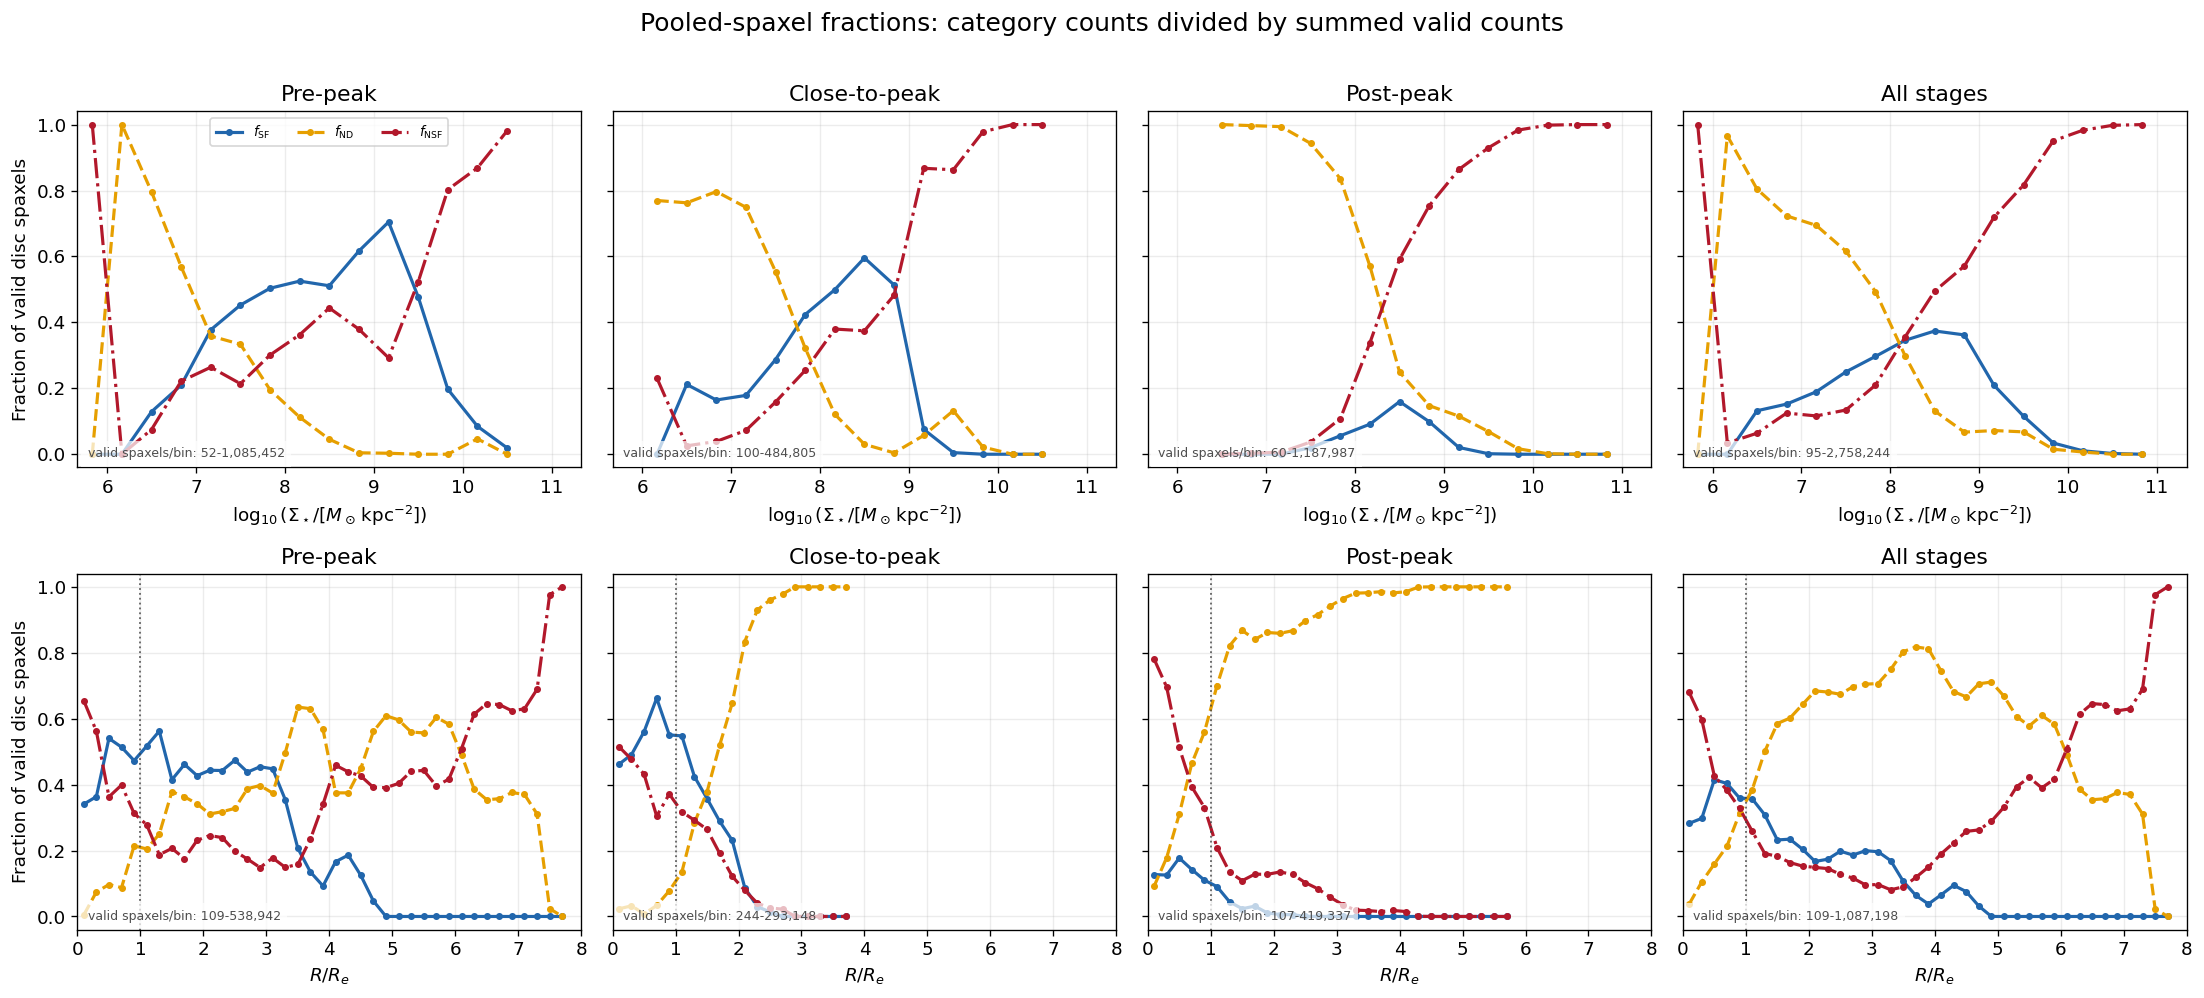

In [6]:
FULL_ROW_X_LIMITS = {
    variable: (float(edges[0]), float(edges[-1]))
    for variable, edges in COMMON_EDGES.items()
}


def plot_fraction_grid(table, *, equal_galaxy=False, row_x_limits=None):
    if row_x_limits is None:
        row_x_limits = FULL_ROW_X_LIMITS
    fig, axes = plt.subplots(2, 4, figsize=(18.5, 8.2), sharey=True)
    variables = ("log_sigma_star", "radius_re")
    for row_index, variable in enumerate(variables):
        for column_index, stage in enumerate(PANEL_ORDER):
            axis = axes[row_index, column_index]
            panel = table.loc[
                table.stage.eq(stage) & table.variable.eq(variable)
            ].sort_values("center")
            for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
                axis.plot(
                    panel.center, panel["f_" + label], marker="o", ms=3.2,
                    lw=1.9, ls=linestyle, color=CATEGORY_COLORS[label],
                    label=r"$f_{\rm " + label + "}$",
                )
            axis.set_ylim(-0.04, 1.04)
            axis.set_xlim(*row_x_limits[variable])
            axis.grid(alpha=0.24)
            axis.set_title(STAGE_LABELS[stage])
            axis.set_xlabel(VARIABLE_LABELS[variable])
            if column_index == 0:
                axis.set_ylabel(
                    "Mean per-galaxy fraction" if equal_galaxy
                    else "Fraction of valid disc spaxels"
                )
            if variable == "radius_re":
                axis.axvline(1.0, color="0.25", ls=":", lw=1.1, alpha=0.8)
            supported = panel.loc[panel[["f_SF", "f_ND", "f_NSF"]].notna().all(axis=1)]
            if len(supported):
                if equal_galaxy:
                    support_text = (
                        f"galaxies/bin: {supported.N_galaxies.min()}-"
                        f"{supported.N_galaxies.max()}"
                    )
                else:
                    support_text = (
                        f"valid spaxels/bin: {supported.N_valid.min():,}-"
                        f"{supported.N_valid.max():,}"
                    )
                axis.text(
                    0.02, 0.02, support_text, transform=axis.transAxes,
                    fontsize=7.5, color="0.3", va="bottom",
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72},
                )
    axes[0, 0].legend(ncol=3, fontsize=8, loc="best")
    title = (
        "Equal-galaxy mean fractions; weights recomputed within every bin"
        if equal_galaxy else
        "Pooled-spaxel fractions: category counts divided by summed valid counts"
    )
    fig.suptitle(title, fontsize=15, y=1.01)
    fig.tight_layout()
    return fig, axes


fig_pooled, axes_pooled = plot_fraction_grid(
    POOLED_FRACTIONS, equal_galaxy=False, row_x_limits=FULL_ROW_X_LIMITS
)
plt.show()


## 6. Version 2 — equal-galaxy fractions

For each displayed bin, the available valid-spaxel count is recomputed separately for every galaxy. A galaxy with 10,000 valid spaxels and one with 1,000 valid spaxels therefore each contribute total weight one when both pass the 50-spaxel support threshold in that bin. Galaxies do **not** borrow counts from other bins or from the other horizontal variable.

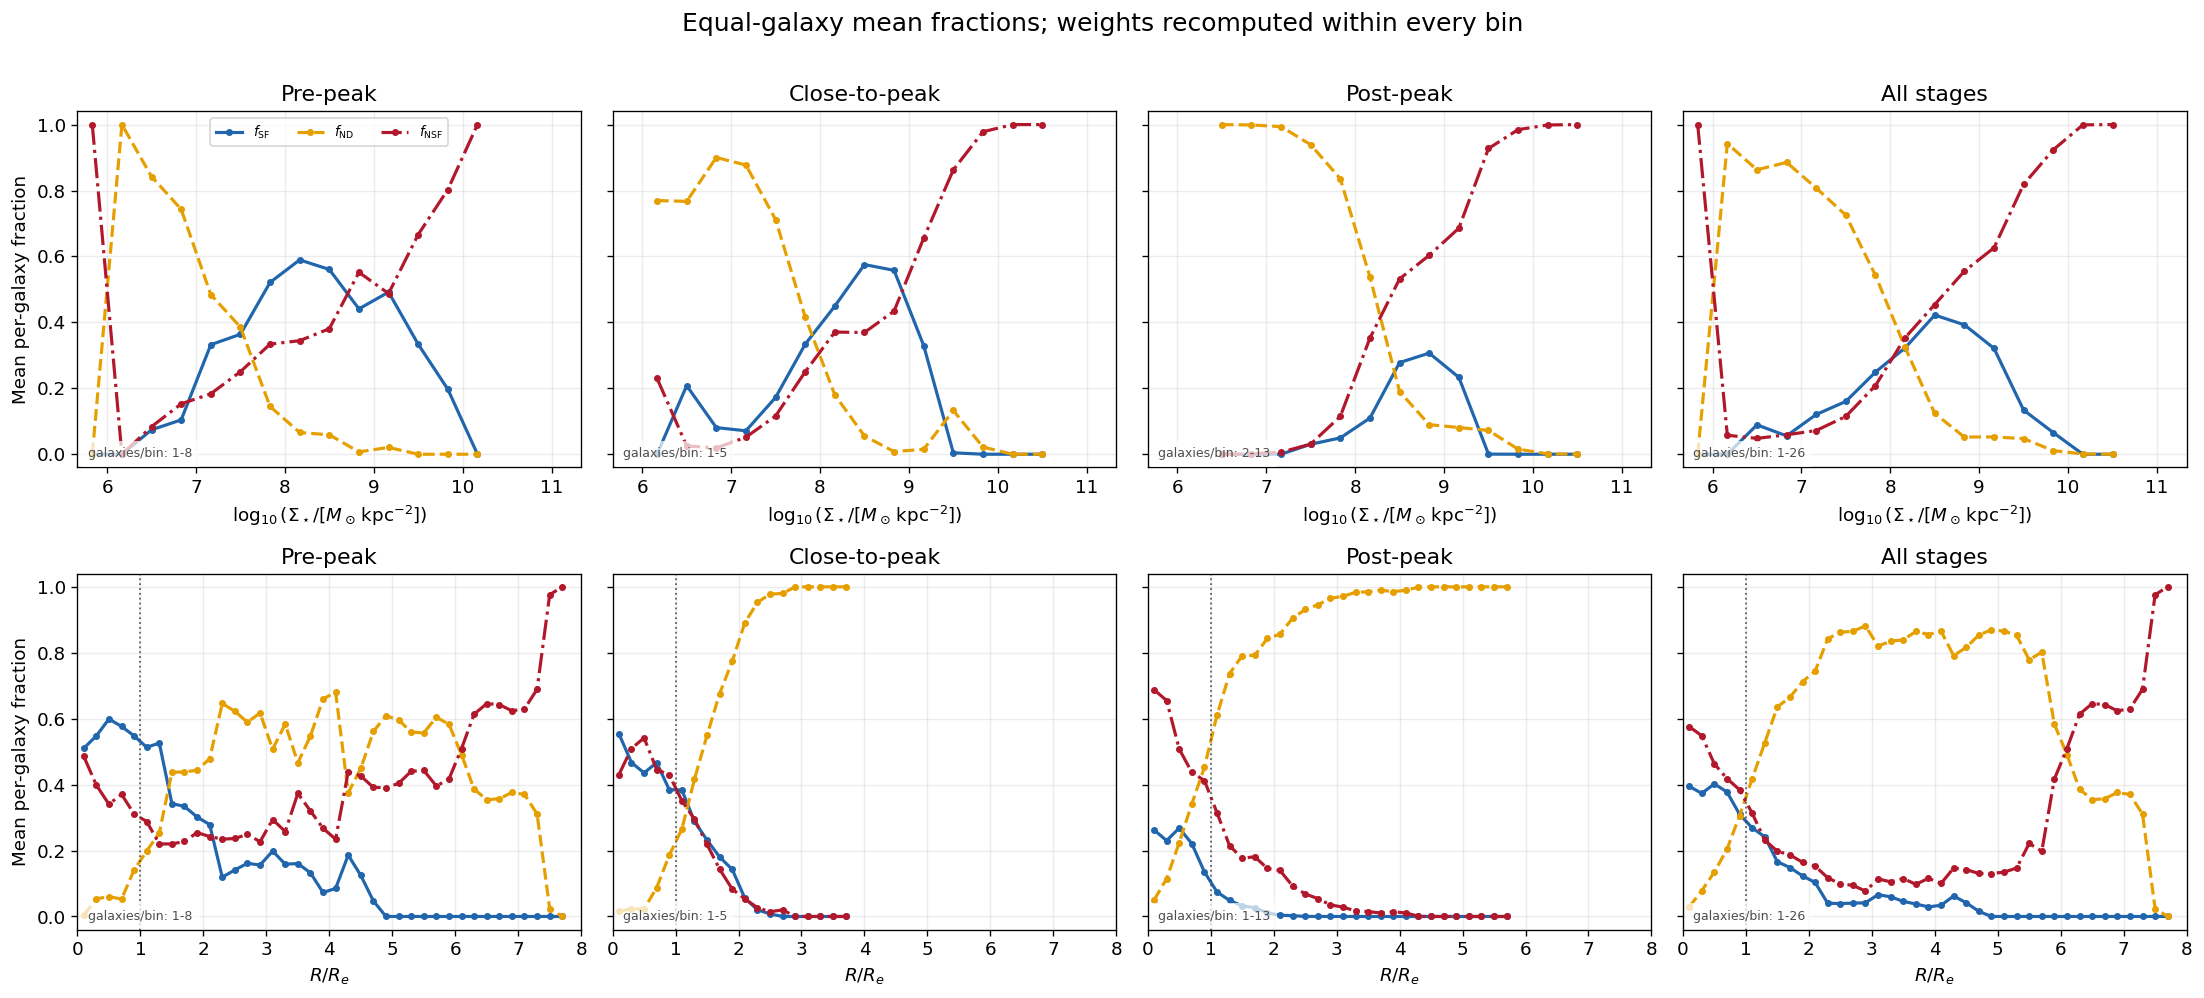

In [7]:
fig_equal, axes_equal = plot_fraction_grid(
    EQUAL_GALAXY_FRACTIONS, equal_galaxy=True, row_x_limits=FULL_ROW_X_LIMITS
)
plt.show()


## 7. Sensitivity check — retain only $R/R_e<4$ in every galaxy

These two additional figures leave the main results unchanged. For the sensitivity calculation only, valid spaxels at $R/R_e\geq4$ are removed separately from every galaxy before both the $\Sigma_\star$ and $R/R_e$ counts are recomputed. All four stage panels in a given row use exactly the same horizontal range.

In [8]:
ALL_GALAXIES_RADIUS_RE_MAX = 4.0


def compute_fraction_estimators_from_bin_counts(bin_counts):
    # Recompute pooled and equal-galaxy fractions from per-galaxy bin counts.
    if bin_counts.empty:
        raise ValueError("No per-galaxy bin counts supplied")
    expanded = add_all_stage_rows(bin_counts)

    pooled = (
        expanded.groupby(group_columns, observed=True, sort=False)[count_columns]
        .sum().reset_index()
    )
    contributing = (
        expanded.loc[expanded.N_valid.gt(0)]
        .groupby(group_columns, observed=True, sort=False).GALID.nunique()
        .rename("N_galaxies").reset_index()
    )
    pooled = pooled.merge(
        contributing, on=group_columns, how="left", validate="one_to_one"
    )
    pooled["N_galaxies"] = pooled.N_galaxies.fillna(0).astype(int)
    supported = pooled.N_valid.ge(MIN_VALID_PIXELS_POOLED_BIN)
    for label in CATEGORY_ORDER:
        pooled["f_" + label] = np.where(
            supported, pooled["N_" + label] / pooled.N_valid, np.nan
        )
    assert np.array_equal(
        pooled.N_SF + pooled.N_ND + pooled.N_NSF, pooled.N_valid
    )
    assert np.allclose(
        pooled.loc[supported, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1.0
    )

    equal_input_local = expanded.loc[
        expanded.N_valid.ge(MIN_VALID_PIXELS_PER_GALAXY_BIN)
    ].copy()
    for label in CATEGORY_ORDER:
        equal_input_local["f_" + label] = (
            equal_input_local["N_" + label] / equal_input_local.N_valid
        )
    equal_input_local["pixel_weight"] = 1.0 / equal_input_local.N_valid
    equal_input_local["weight_total"] = (
        equal_input_local.pixel_weight * equal_input_local.N_valid
    )
    assert np.allclose(equal_input_local.weight_total, 1.0)

    equal_rows_local = []
    for keys, group in equal_input_local.groupby(
        group_columns, observed=True, sort=False
    ):
        row = dict(zip(group_columns, keys))
        row["N_galaxies"] = int(group.GALID.nunique())
        row["N_valid"] = int(group.N_valid.sum())
        for label in CATEGORY_ORDER:
            row["f_" + label] = float(group["f_" + label].mean())
        equal_rows_local.append(row)
    equal = pd.DataFrame(equal_rows_local)
    assert np.allclose(equal[["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1.0)
    return pooled, equal, equal_input_local


all_cut_count_rows = []
all_cut_summary_rows = []
for galaxy_row in sample.itertuples(index=False):
    maps = load_galaxy_maps(galaxy_row, geometry)
    original_valid = maps["valid_disc_mask"].copy()
    outside_radius_cut = original_valid & (
        maps["radius_re"] >= ALL_GALAXIES_RADIUS_RE_MAX
    )
    keep = original_valid & ~outside_radius_cut
    if int(keep.sum()) == 0:
        raise AssertionError(f"{galaxy_row.GALID}: no valid spaxels remain inside 4 Re")
    filtered_maps = maps.copy()
    filtered_maps["valid_disc_mask"] = keep
    for key in ("sf_mask", "nd_mask", "nsf_mask"):
        filtered_maps[key] = maps[key] & keep
    assert np.array_equal(
        filtered_maps["sf_mask"].astype(np.int8)
        + filtered_maps["nd_mask"].astype(np.int8)
        + filtered_maps["nsf_mask"].astype(np.int8),
        keep.astype(np.int8),
    )
    for variable, edges in COMMON_EDGES.items():
        all_cut_count_rows.extend(count_categories_in_bins(
            galaxy_row.GALID, galaxy_row.stage, filtered_maps[variable],
            filtered_maps, edges, variable,
        ))
    all_cut_summary_rows.append({
        "GALID": galaxy_row.GALID, "stage": galaxy_row.stage,
        "N_valid_original": int(original_valid.sum()),
        "N_removed_radius_ge_4Re": int(outside_radius_cut.sum()),
        "N_valid_retained": int(keep.sum()),
    })
    del maps, filtered_maps

BIN_COUNTS_ALL_RADIUS_CUT = pd.DataFrame(all_cut_count_rows)
ALL_RADIUS_CUT_SUMMARY = pd.DataFrame(all_cut_summary_rows)
assert set(BIN_COUNTS_ALL_RADIUS_CUT.GALID) == set(BIN_COUNTS_BY_GALAXY.GALID)

(
    POOLED_FRACTIONS_ALL_RADIUS_CUT,
    EQUAL_GALAXY_FRACTIONS_ALL_RADIUS_CUT,
    EQUAL_INPUT_ALL_RADIUS_CUT,
) = compute_fraction_estimators_from_bin_counts(
    BIN_COUNTS_ALL_RADIUS_CUT
)

SENSITIVITY_GALAXY_COUNTS = (
    add_all_stage_rows(ALL_RADIUS_CUT_SUMMARY)
    .groupby("stage", observed=True).GALID.nunique().reindex(PANEL_ORDER)
)
assert SENSITIVITY_GALAXY_COUNTS.to_dict() == {
    "pre-peak": 8,
    "close-to-peak": 5,
    "post-peak": 13,
    "all stages": 26,
}
display(ALL_RADIUS_CUT_SUMMARY)
display(ALL_RADIUS_CUT_SUMMARY.groupby("stage")[[
    "N_valid_original", "N_removed_radius_ge_4Re", "N_valid_retained"
]].sum())


,GALID,stage,N_valid_original,N_removed_radius_ge_4Re,N_valid_retained
0,NGC4298,close-to-peak,498540,0,498540
1,NGC4424,close-to-peak,172561,0,172561
2,NGC4501,close-to-peak,664236,0,664236
3,NGC4654,close-to-peak,659231,0,659231
4,NGC4694,close-to-peak,94538,0,94538
5,IC3392,post-peak,94575,0,94575
6,NGC4064,post-peak,179882,0,179882
7,NGC4293,post-peak,261523,0,261523
8,NGC4380,post-peak,502065,0,502065
9,NGC4394,post-peak,180654,0,180654


,N_valid_original,N_removed_radius_ge_4Re,N_valid_retained
stage,,,
close-to-peak,2089106,0,2089106
post-peak,3703758,44769,3658989
pre-peak,3812578,105350,3707228


### 7.1 Version 1 restricted to $R/R_e<4$ for all galaxies

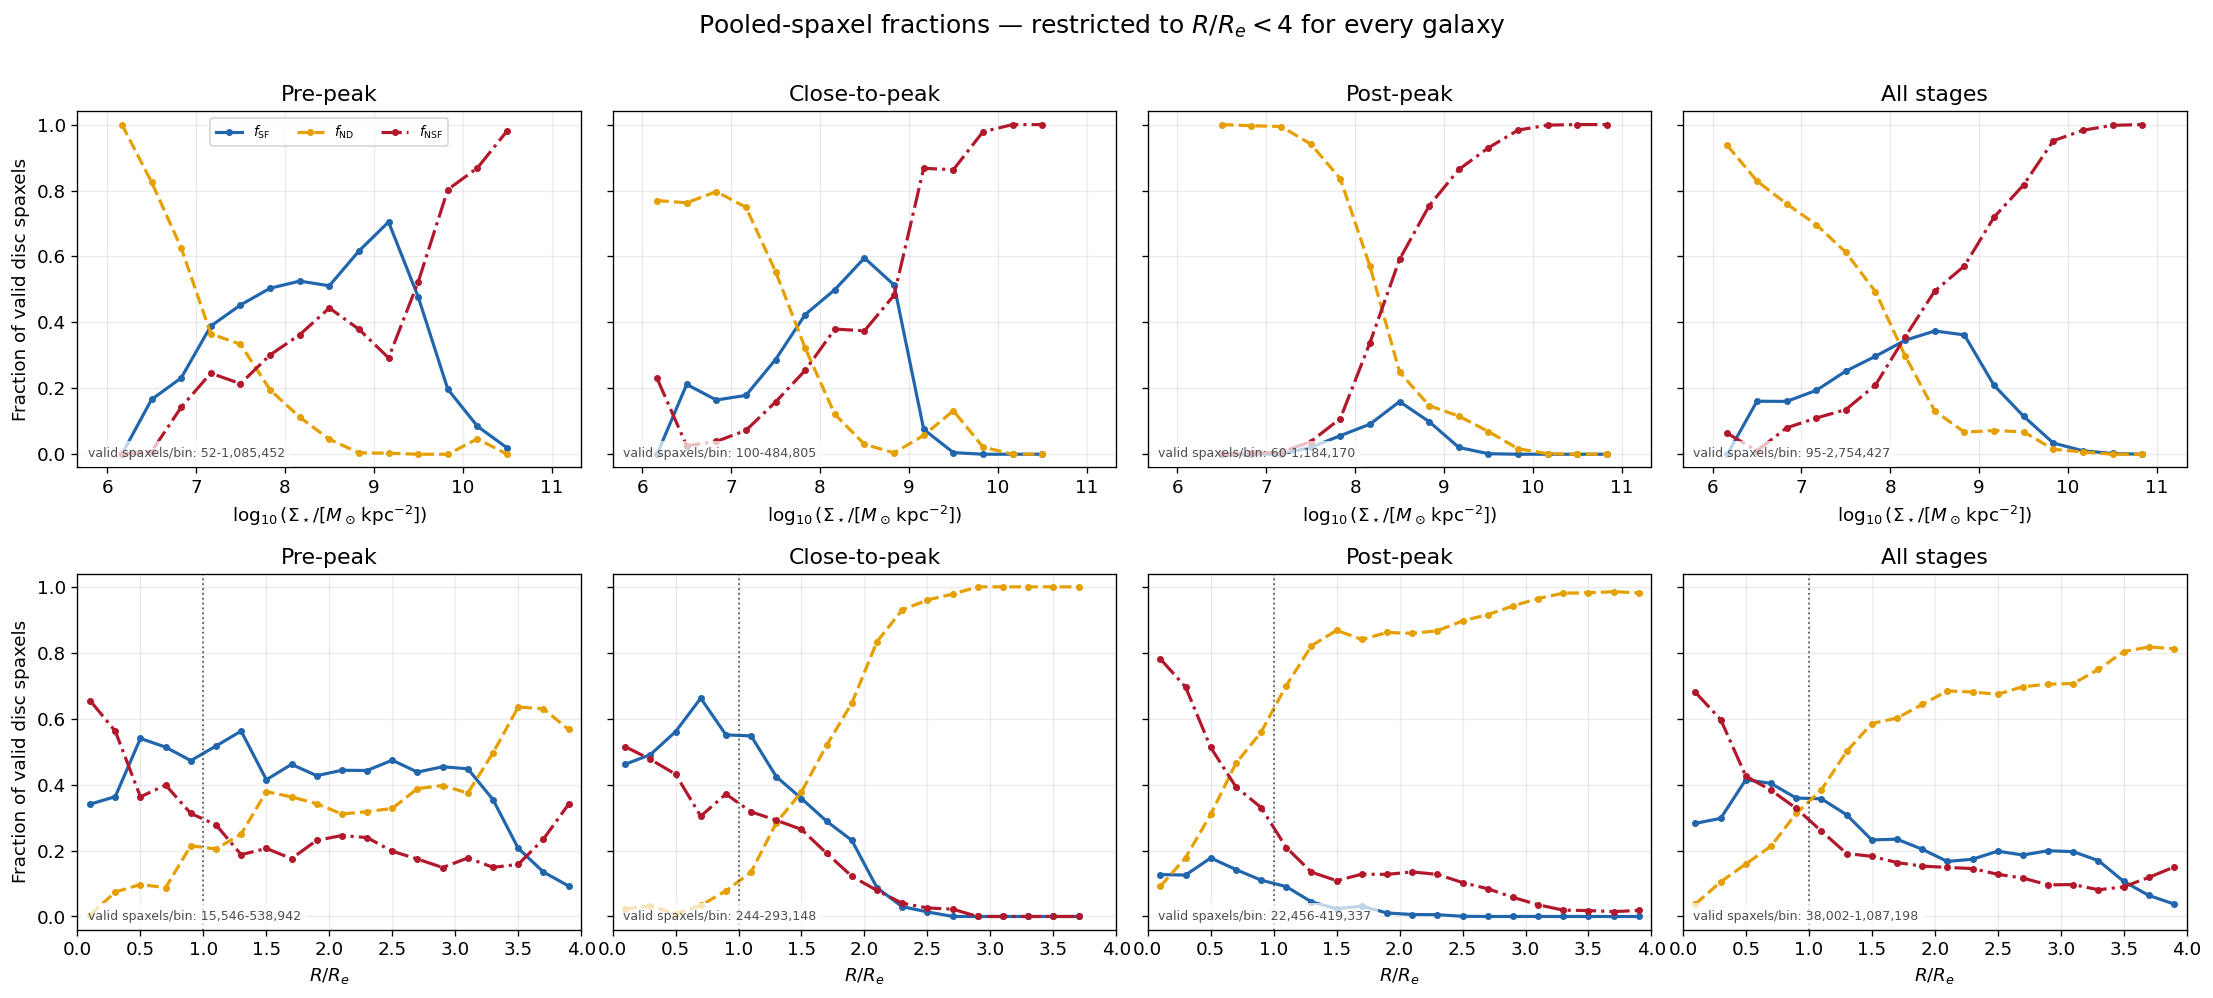

In [9]:
RADIUS_CUT_ROW_X_LIMITS = {
    "log_sigma_star": FULL_ROW_X_LIMITS["log_sigma_star"],
    "radius_re": (0.0, ALL_GALAXIES_RADIUS_RE_MAX),
}
fig_pooled_all_radius_cut, axes_pooled_all_radius_cut = plot_fraction_grid(
    POOLED_FRACTIONS_ALL_RADIUS_CUT, equal_galaxy=False,
    row_x_limits=RADIUS_CUT_ROW_X_LIMITS,
)
fig_pooled_all_radius_cut.suptitle(
    r"Pooled-spaxel fractions — restricted to $R/R_e<4$ for every galaxy",
    fontsize=15, y=1.01,
)
plt.show()


### 7.2 Version 2 restricted to $R/R_e<4$ for all galaxies

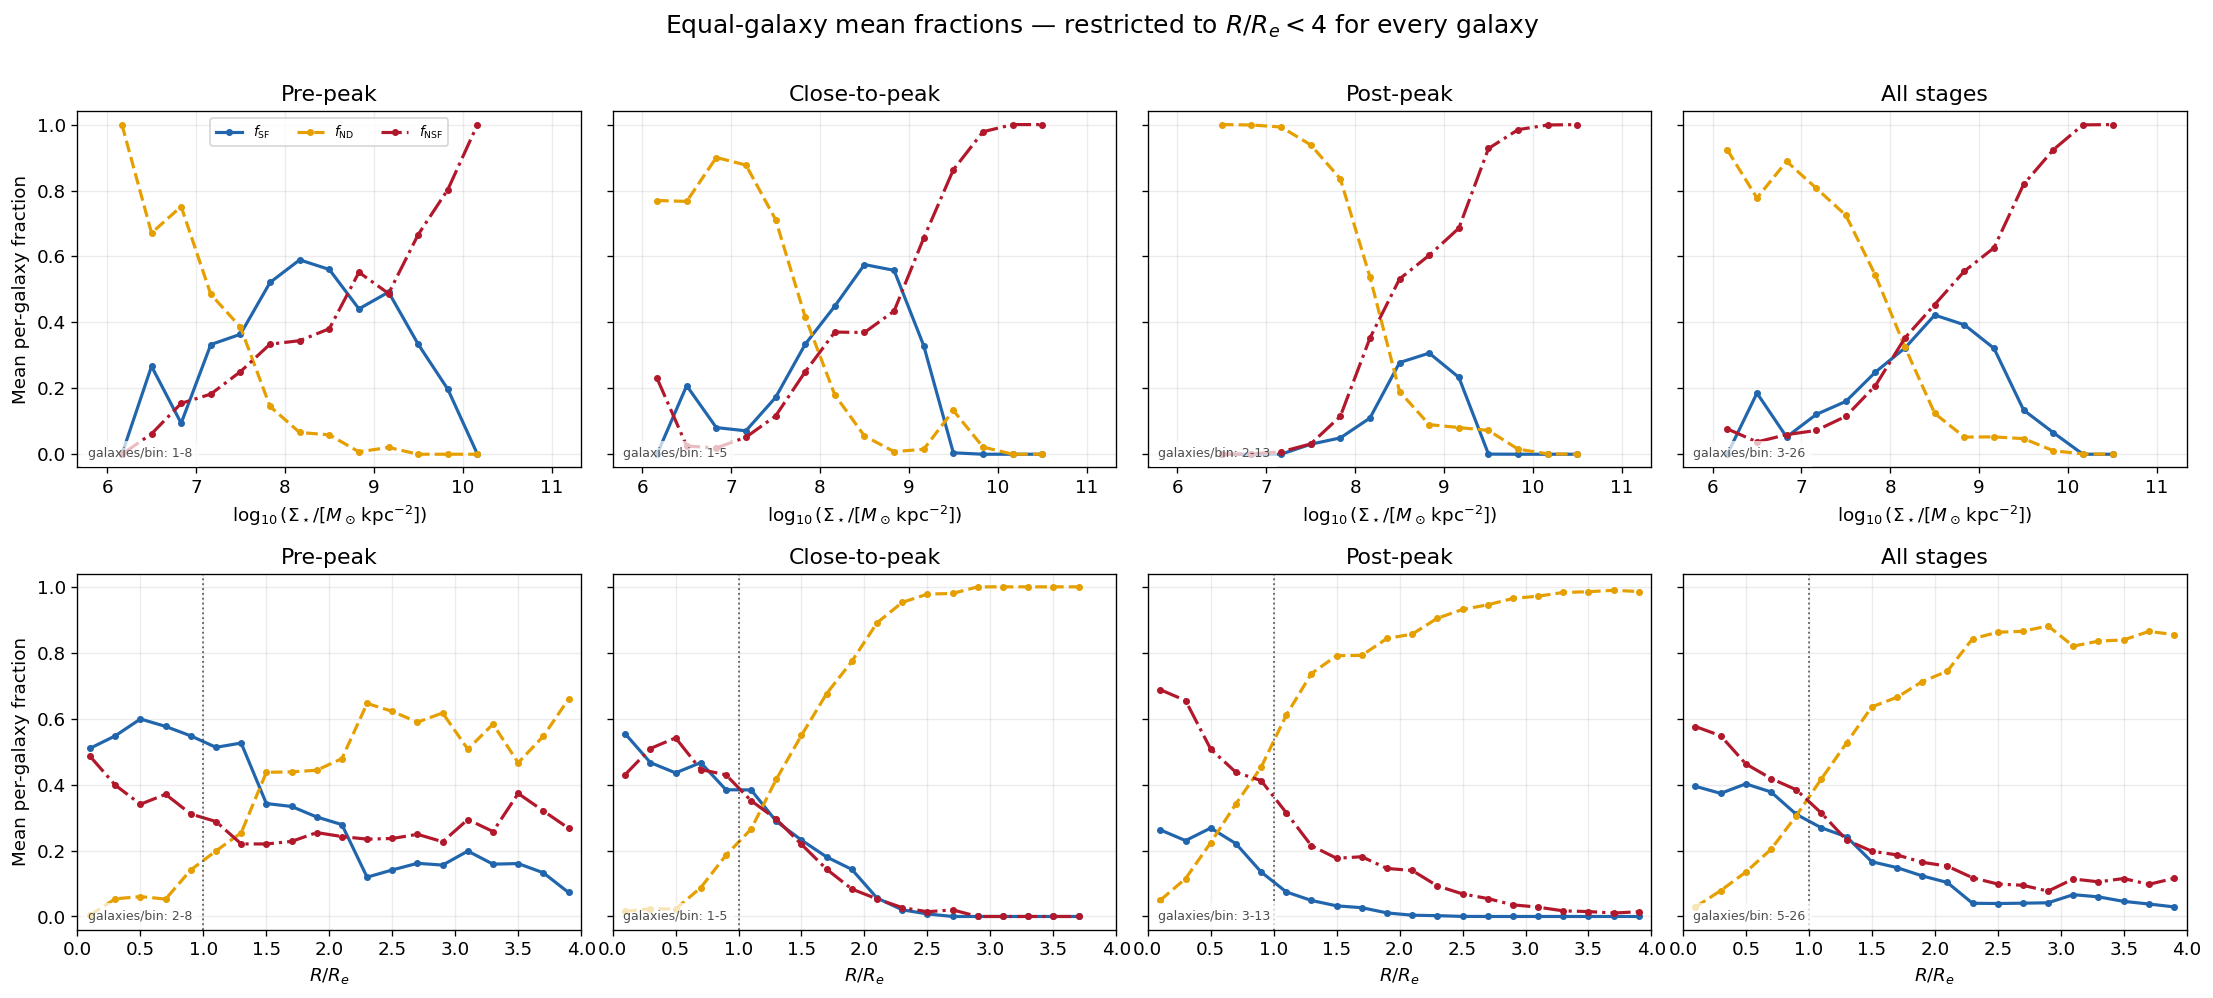

In [10]:
fig_equal_all_radius_cut, axes_equal_all_radius_cut = plot_fraction_grid(
    EQUAL_GALAXY_FRACTIONS_ALL_RADIUS_CUT, equal_galaxy=True,
    row_x_limits=RADIUS_CUT_ROW_X_LIMITS,
)
fig_equal_all_radius_cut.suptitle(
    r"Equal-galaxy mean fractions — restricted to $R/R_e<4$ for every galaxy",
    fontsize=15, y=1.01,
)
plt.show()


## 8. Verification tables and interpretation

In [11]:
# Show the exact numerical curves used by both figures.
pooled_columns = [
    "stage", "variable", "bin_left", "bin_right", "N_galaxies", "N_valid",
    "f_SF", "f_ND", "f_NSF",
]
equal_columns = [
    "stage", "variable", "bin_left", "bin_right", "N_galaxies", "N_valid",
    "f_SF", "f_ND", "f_NSF",
]
print("Pooled-spaxel curves")
display(POOLED_FRACTIONS[pooled_columns].round(4))
print("Equal-galaxy curves")
display(EQUAL_GALAXY_FRACTIONS[equal_columns].round(4))

verification = {
    "all_three_stages_present": set(sample.stage) == set(STAGE_ORDER),
    "every_galaxy_variable_has_complete_valid_count": True,
    "per_galaxy_category_accounting_exact": bool(np.array_equal(
        BIN_COUNTS_BY_GALAXY.N_SF + BIN_COUNTS_BY_GALAXY.N_ND
        + BIN_COUNTS_BY_GALAXY.N_NSF,
        BIN_COUNTS_BY_GALAXY.N_valid,
    )),
    "pooled_supported_fractions_sum_to_one": bool(np.allclose(
        POOLED_FRACTIONS.loc[
            POOLED_FRACTIONS.N_valid.ge(MIN_VALID_PIXELS_POOLED_BIN),
            ["f_SF", "f_ND", "f_NSF"],
        ].sum(axis=1), 1.0,
    )),
    "equal_galaxy_fractions_sum_to_one": bool(np.allclose(
        EQUAL_GALAXY_FRACTIONS[["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1.0
    )),
    "every_included_galaxy_bin_has_unit_total_weight": bool(np.allclose(
        equal_input.weight_total, 1.0
    )),
    "all_galaxies_retained_in_sensitivity_sample": bool(
        set(BIN_COUNTS_ALL_RADIUS_CUT.GALID) == set(BIN_COUNTS_BY_GALAXY.GALID)
    ),
    "sensitivity_sample_keeps_26_galaxies": bool(
        SENSITIVITY_GALAXY_COUNTS.to_dict() == {
            "pre-peak": 8, "close-to-peak": 5,
            "post-peak": 13, "all stages": 26,
        }
    ),
    "all_retained_spaxels_meet_radius_cut": bool(
        int(ALL_RADIUS_CUT_SUMMARY["N_removed_radius_ge_4Re"].sum()) > 0
        and int(ALL_RADIUS_CUT_SUMMARY.N_valid_retained.sum()) > 0
    ),
    "radius_cut_pooled_fractions_sum_to_one": bool(np.allclose(
        POOLED_FRACTIONS_ALL_RADIUS_CUT.loc[
            POOLED_FRACTIONS_ALL_RADIUS_CUT.N_valid.ge(
                MIN_VALID_PIXELS_POOLED_BIN
            ),
            ["f_SF", "f_ND", "f_NSF"],
        ].sum(axis=1), 1.0,
    )),
    "radius_cut_equal_fractions_sum_to_one": bool(np.allclose(
        EQUAL_GALAXY_FRACTIONS_ALL_RADIUS_CUT[
            ["f_SF", "f_ND", "f_NSF"]
        ].sum(axis=1), 1.0,
    )),
    "radius_cut_equal_bin_weights_sum_to_one": bool(np.allclose(
        EQUAL_INPUT_ALL_RADIUS_CUT.weight_total, 1.0
    )),
}
for row in sample.itertuples(index=False):
    expected = int(GLOBAL_COUNTS_BY_GALAXY.loc[
        GLOBAL_COUNTS_BY_GALAXY.GALID.eq(row.GALID), "N_valid"
    ].iloc[0])
    for variable in COMMON_EDGES:
        measured = int(BIN_COUNTS_BY_GALAXY.loc[
            BIN_COUNTS_BY_GALAXY.GALID.eq(row.GALID)
            & BIN_COUNTS_BY_GALAXY.variable.eq(variable), "N_valid"
        ].sum())
        verification["every_galaxy_variable_has_complete_valid_count"] &= measured == expected

VERIFICATION = pd.Series(verification, name="passed")
display(VERIFICATION)
if not VERIFICATION.all():
    raise AssertionError("One or more final verification checks failed")
print("FINAL_VERIFICATION_OK")


Pooled-spaxel curves
Equal-galaxy curves
FINAL_VERIFICATION_OK


,stage,variable,bin_left,bin_right,N_galaxies,N_valid,f_SF,f_ND,f_NSF
0,close-to-peak,log_sigma_star,5.6667,6.0000,0,0,NaN,NaN,NaN
1,close-to-peak,log_sigma_star,6.0000,6.3333,1,5054,0.0000,0.7697,0.2303
2,close-to-peak,log_sigma_star,6.3333,6.6667,2,22036,0.2119,0.7627,0.0255
3,close-to-peak,log_sigma_star,6.6667,7.0000,4,111319,0.1645,0.7967,0.0388
4,close-to-peak,log_sigma_star,7.0000,7.3333,5,355061,0.1785,0.7492,0.0724
...,...,...,...,...,...,...,...,...,...
223,all stages,radius_re,7.0000,7.2000,1,978,0.0000,0.3701,0.6299
224,all stages,radius_re,7.2000,7.4000,1,563,0.0000,0.3108,0.6892
225,all stages,radius_re,7.4000,7.6000,1,251,0.0000,0.0239,0.9761
226,all stages,radius_re,7.6000,7.8000,1,109,0.0000,0.0000,1.0000


,stage,variable,bin_left,bin_right,N_galaxies,N_valid,f_SF,f_ND,f_NSF
0,close-to-peak,log_sigma_star,6.3333,6.6667,2,22036,0.2080,0.7670,0.0250
1,close-to-peak,log_sigma_star,6.6667,7.0000,4,111319,0.0808,0.9001,0.0190
2,close-to-peak,log_sigma_star,7.0000,7.3333,5,355061,0.0711,0.8772,0.0517
3,close-to-peak,log_sigma_star,7.3333,7.6667,5,461117,0.1722,0.7120,0.1158
4,close-to-peak,log_sigma_star,7.6667,8.0000,5,484805,0.3336,0.4163,0.2500
...,...,...,...,...,...,...,...,...,...
177,all stages,radius_re,6.8000,7.0000,1,1348,0.0000,0.3761,0.6239
178,all stages,radius_re,7.0000,7.2000,1,978,0.0000,0.3701,0.6299
179,all stages,radius_re,7.2000,7.4000,1,563,0.0000,0.3108,0.6892
180,all stages,radius_re,7.4000,7.6000,1,251,0.0000,0.0239,0.9761


all_three_stages_present                           True
every_galaxy_variable_has_complete_valid_count     True
per_galaxy_category_accounting_exact               True
pooled_supported_fractions_sum_to_one              True
equal_galaxy_fractions_sum_to_one                  True
every_included_galaxy_bin_has_unit_total_weight    True
all_galaxies_retained_in_sensitivity_sample        True
sensitivity_sample_keeps_26_galaxies               True
all_retained_spaxels_meet_radius_cut               True
radius_cut_pooled_fractions_sum_to_one             True
radius_cut_equal_fractions_sum_to_one              True
radius_cut_equal_bin_weights_sum_to_one            True
Name: passed, dtype: bool

### Reading the two versions

- The **pooled-spaxel** curves answer: “What fraction of all measured valid-disc spaxels in this stage and bin belongs to each category?” They describe the sampled spaxel population, so large or densely sampled galaxies contribute more.
- The **equal-galaxy** curves answer: “What is the mean galaxy's category fraction in this stage and bin?” They prevent a galaxy with many available spaxels from dominating, but their support can change from bin to bin. Always read the displayed contributing-galaxy range.
- SF, ND, and NSF are exhaustive selection outcomes over the unchanged valid-disc footprint. ND is a Balmer detection outcome. NSF is a detected non-selection outcome, not proof of zero star formation.
- Differences between stage panels are descriptive. Neither estimator controls for stellar mass, morphology, spatial resolution, or cluster history, so the curves alone do not establish an evolutionary or causal effect.

## 9. Individual-galaxy spatial SF/ND/NSF maps

The final cell reproduces the source notebook's WCS category-map style for every QC-passing galaxy. Colours show the unchanged full valid-disc SF/ND/NSF partition. The black dotted contour marks $1R_e$ and the black solid contour marks $4R_e$, which is the boundary used by the sensitivity calculation above.

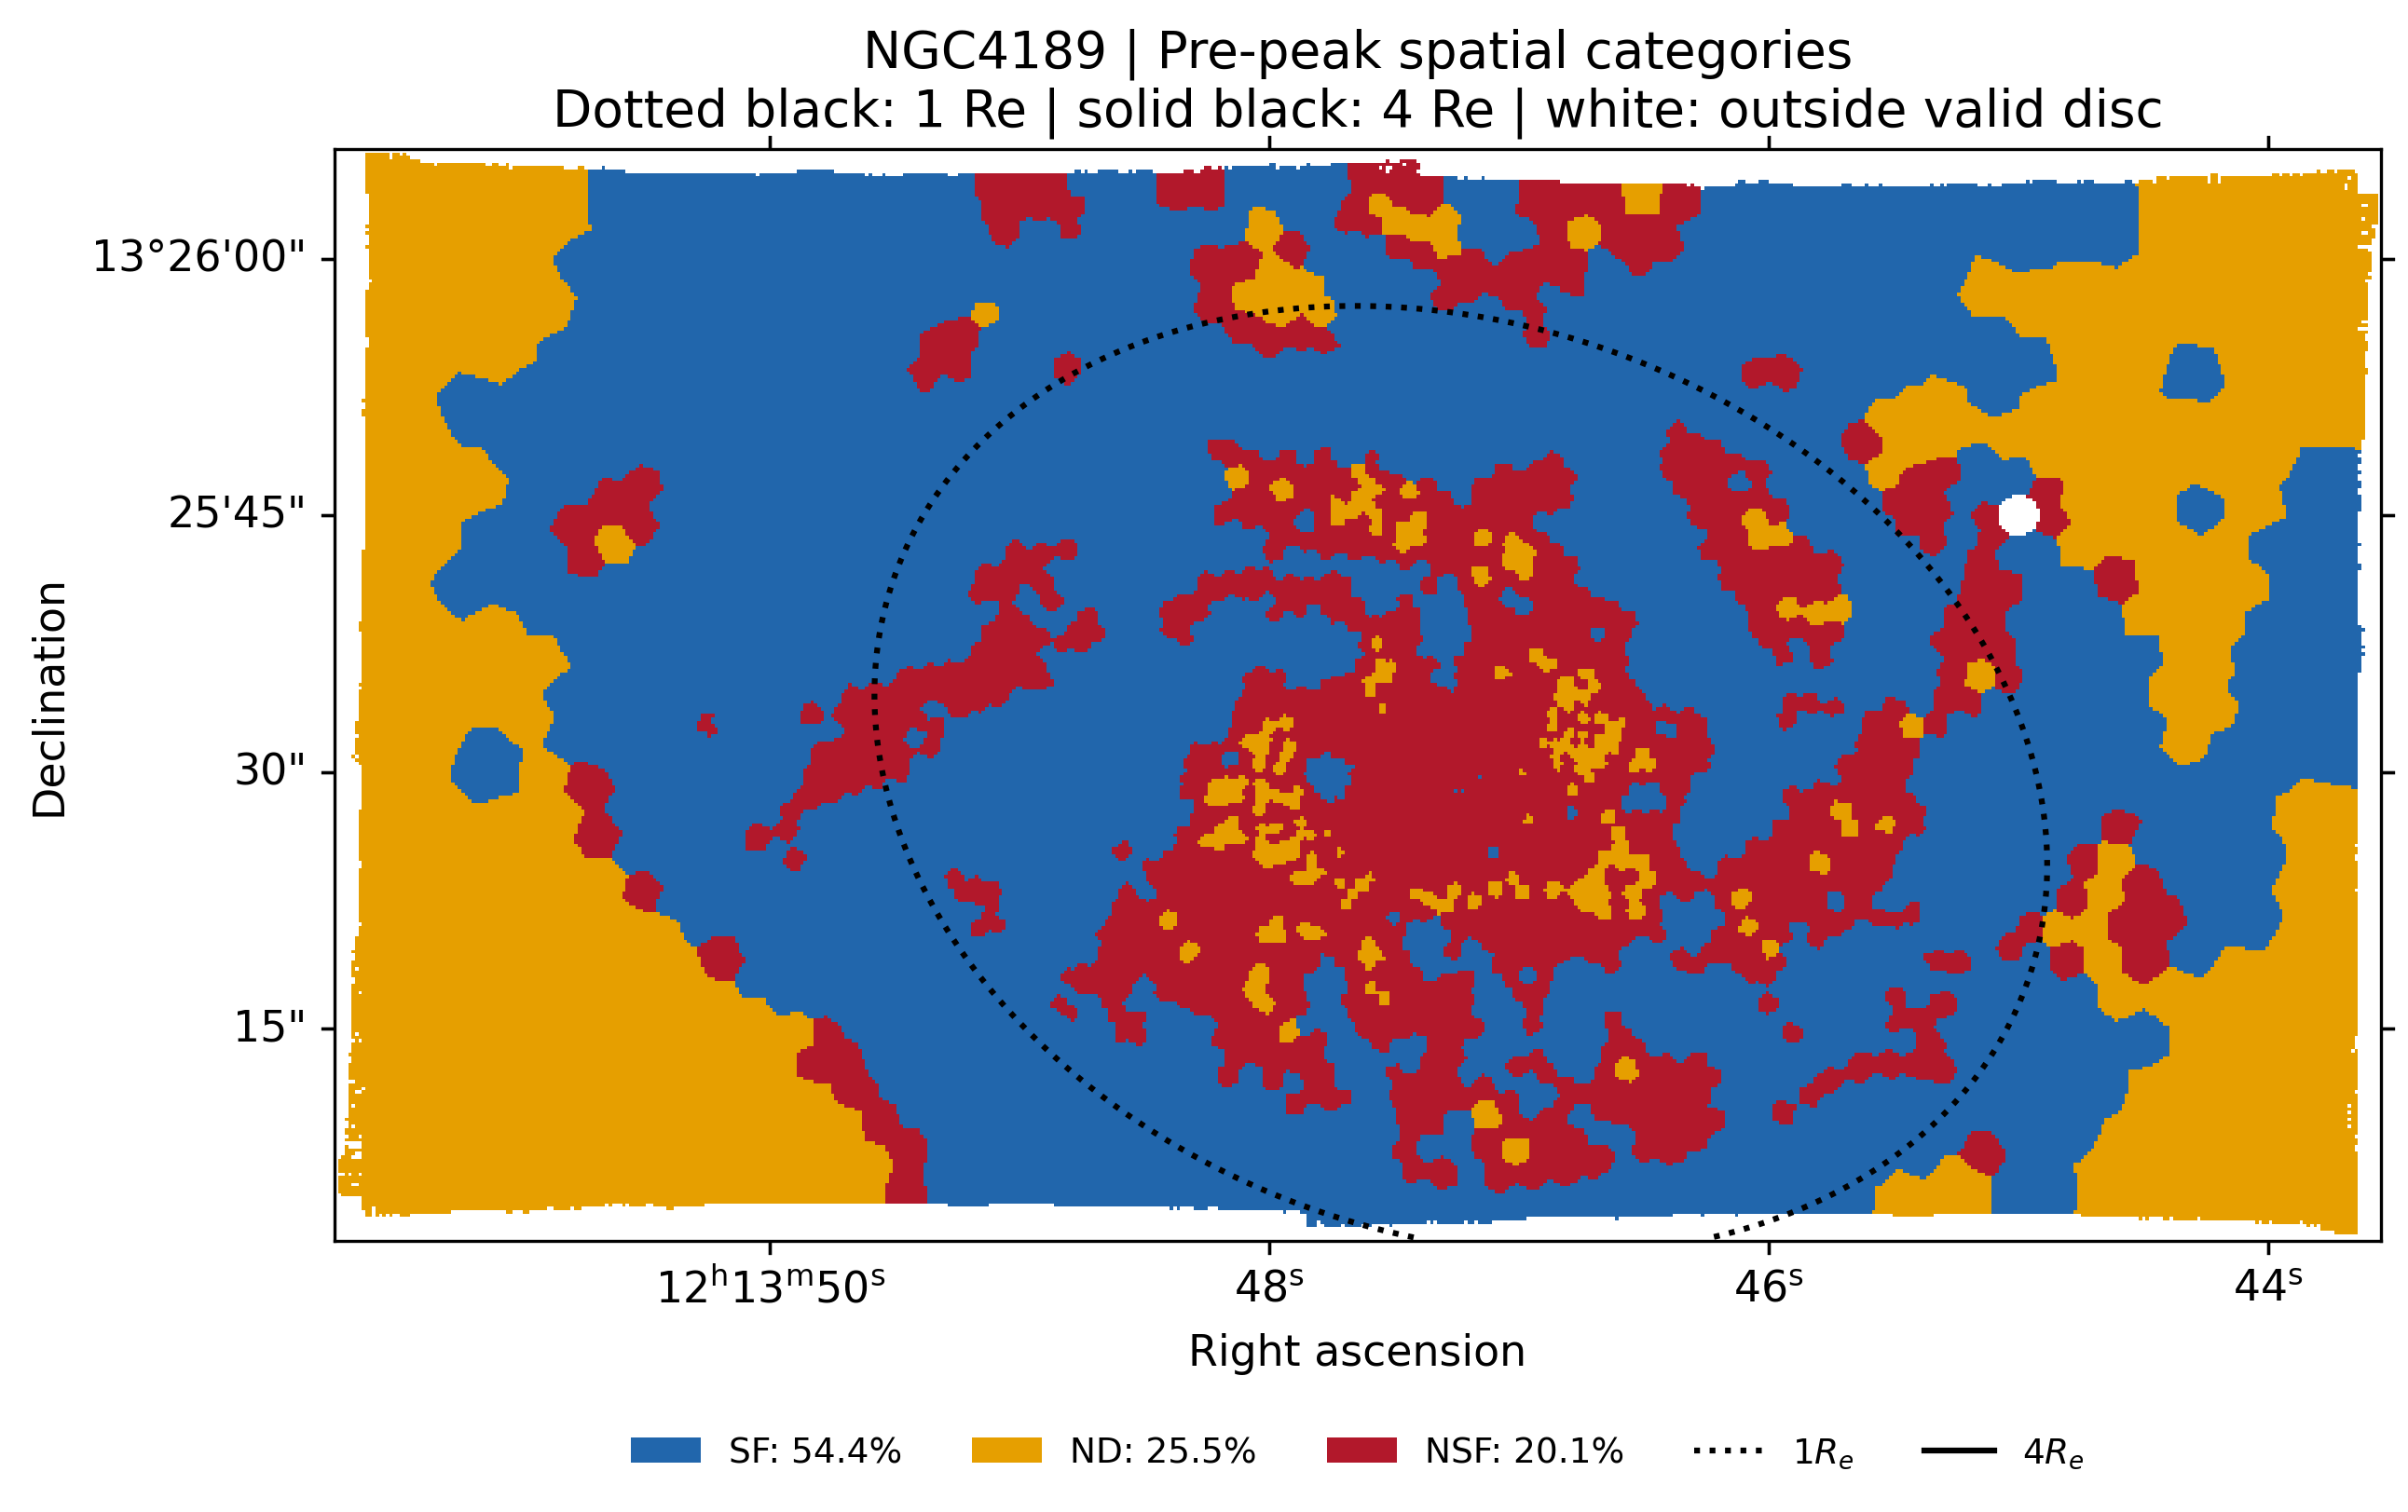

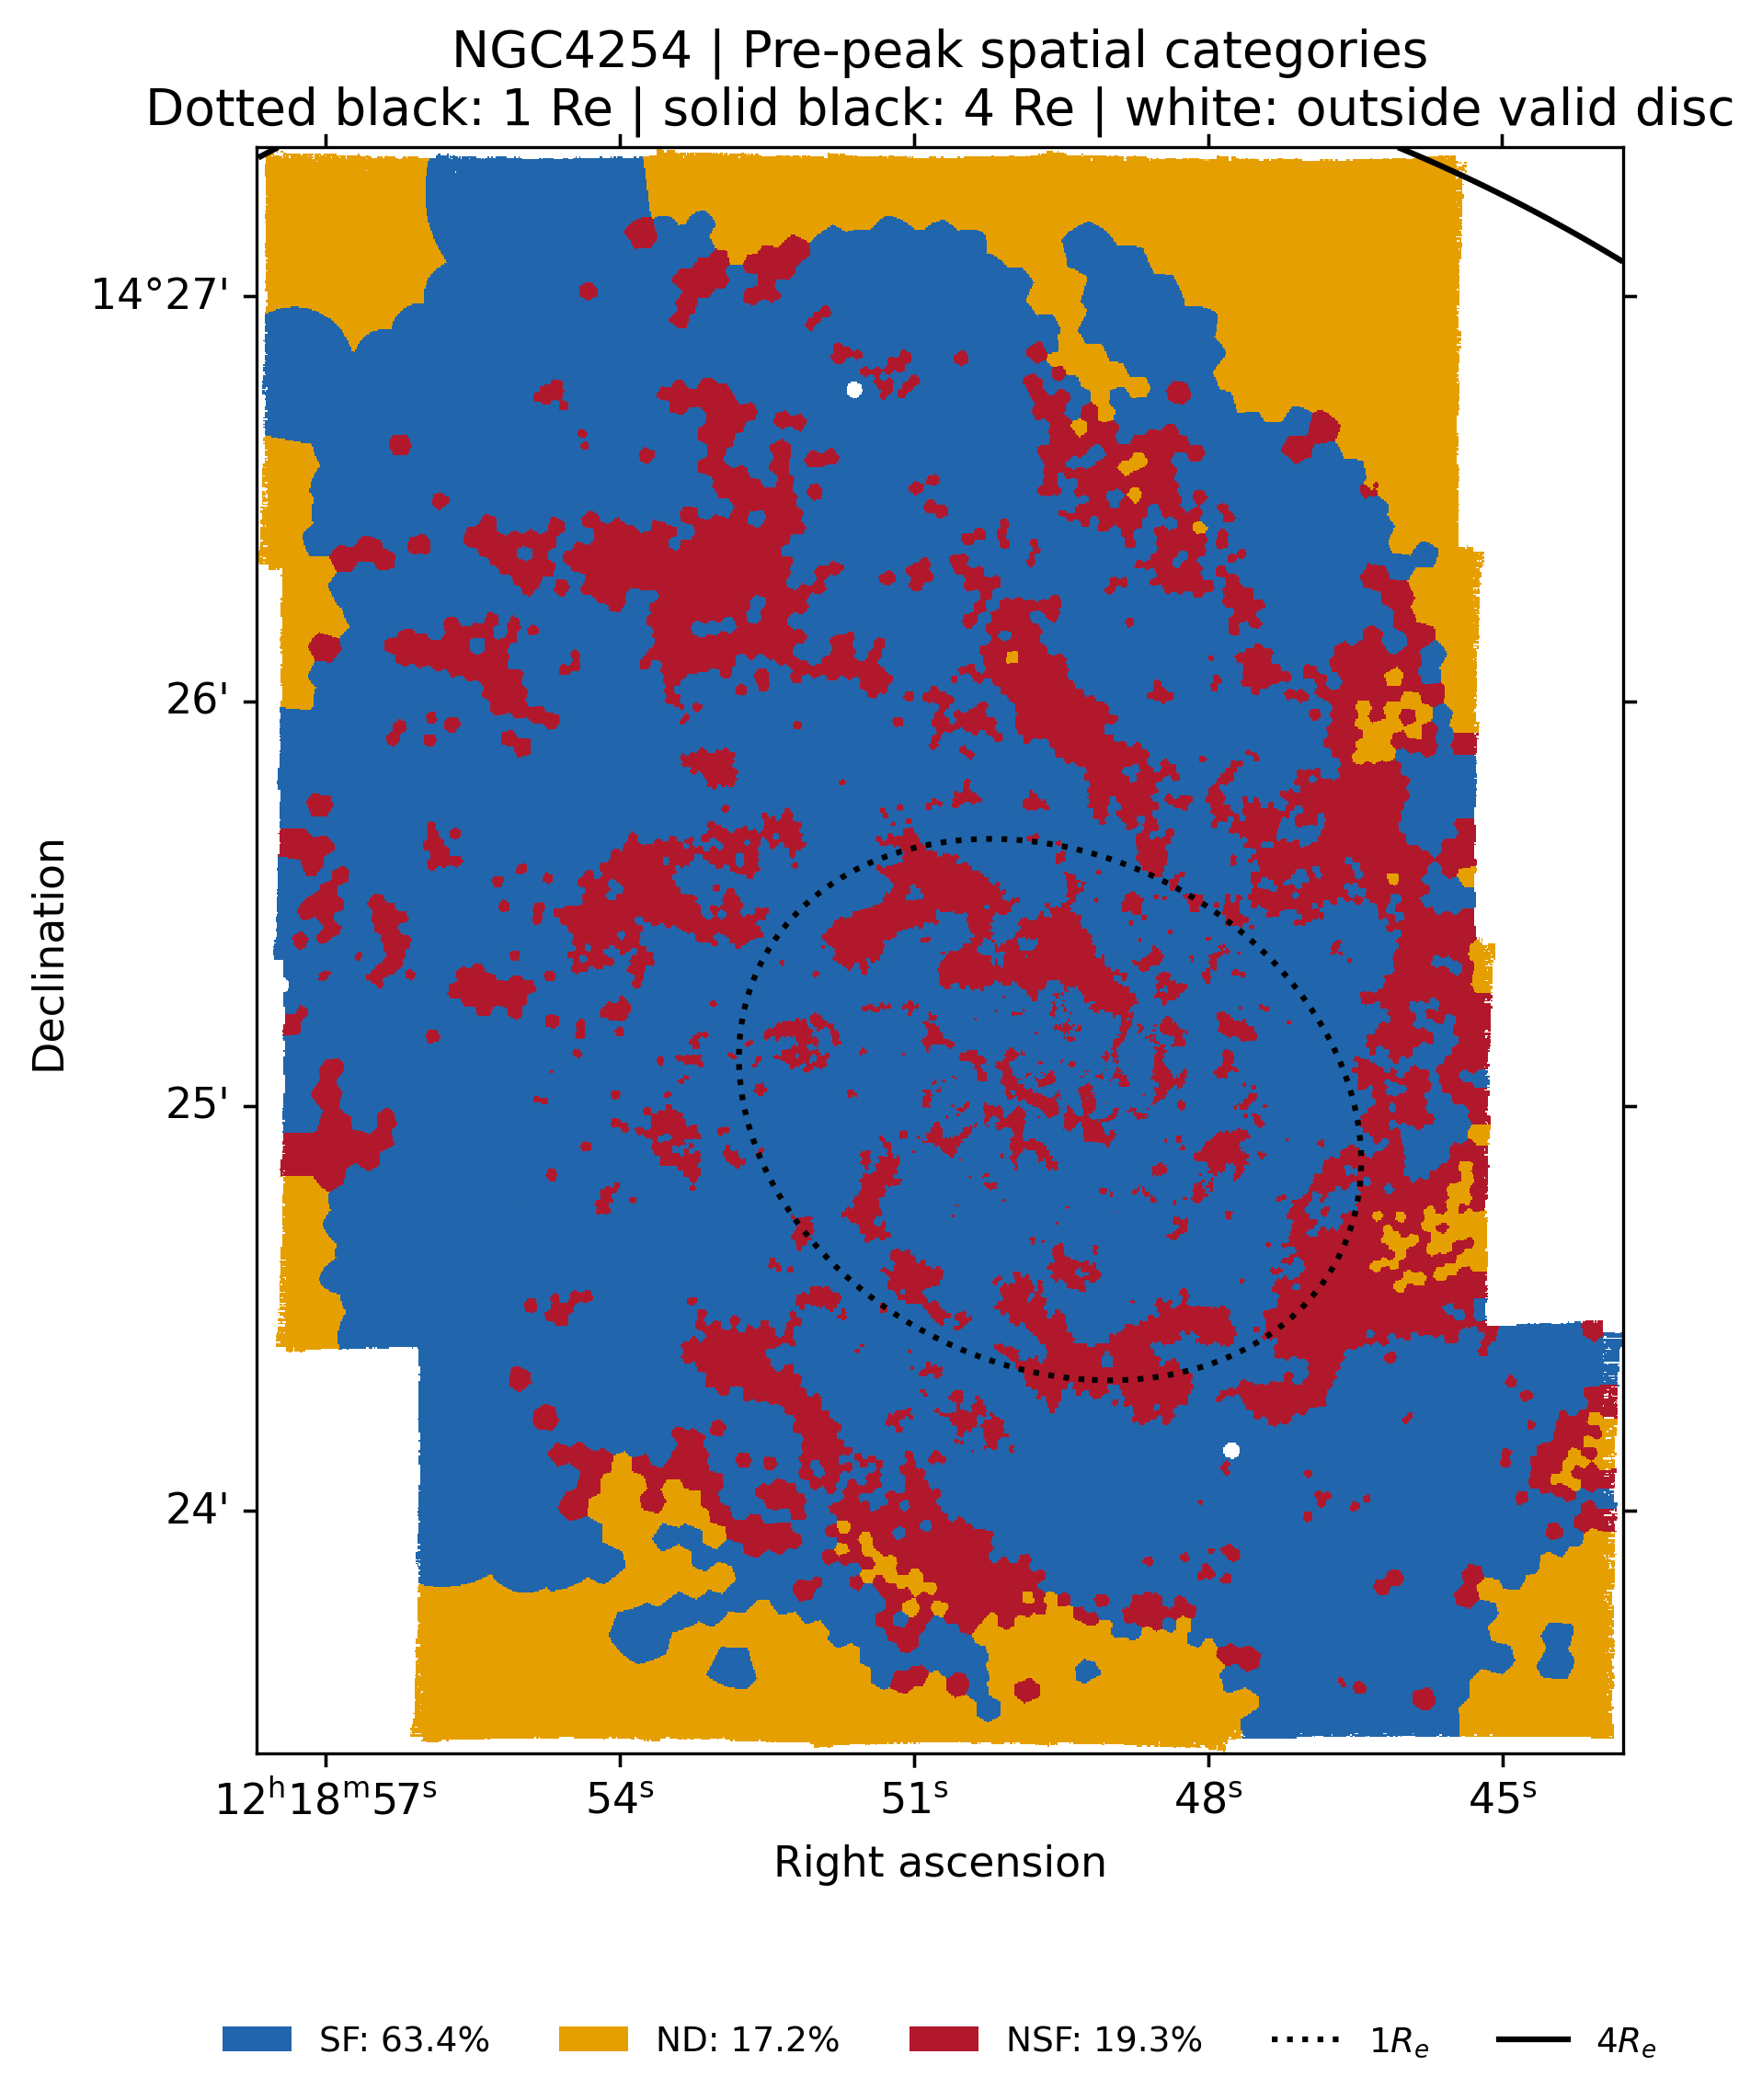

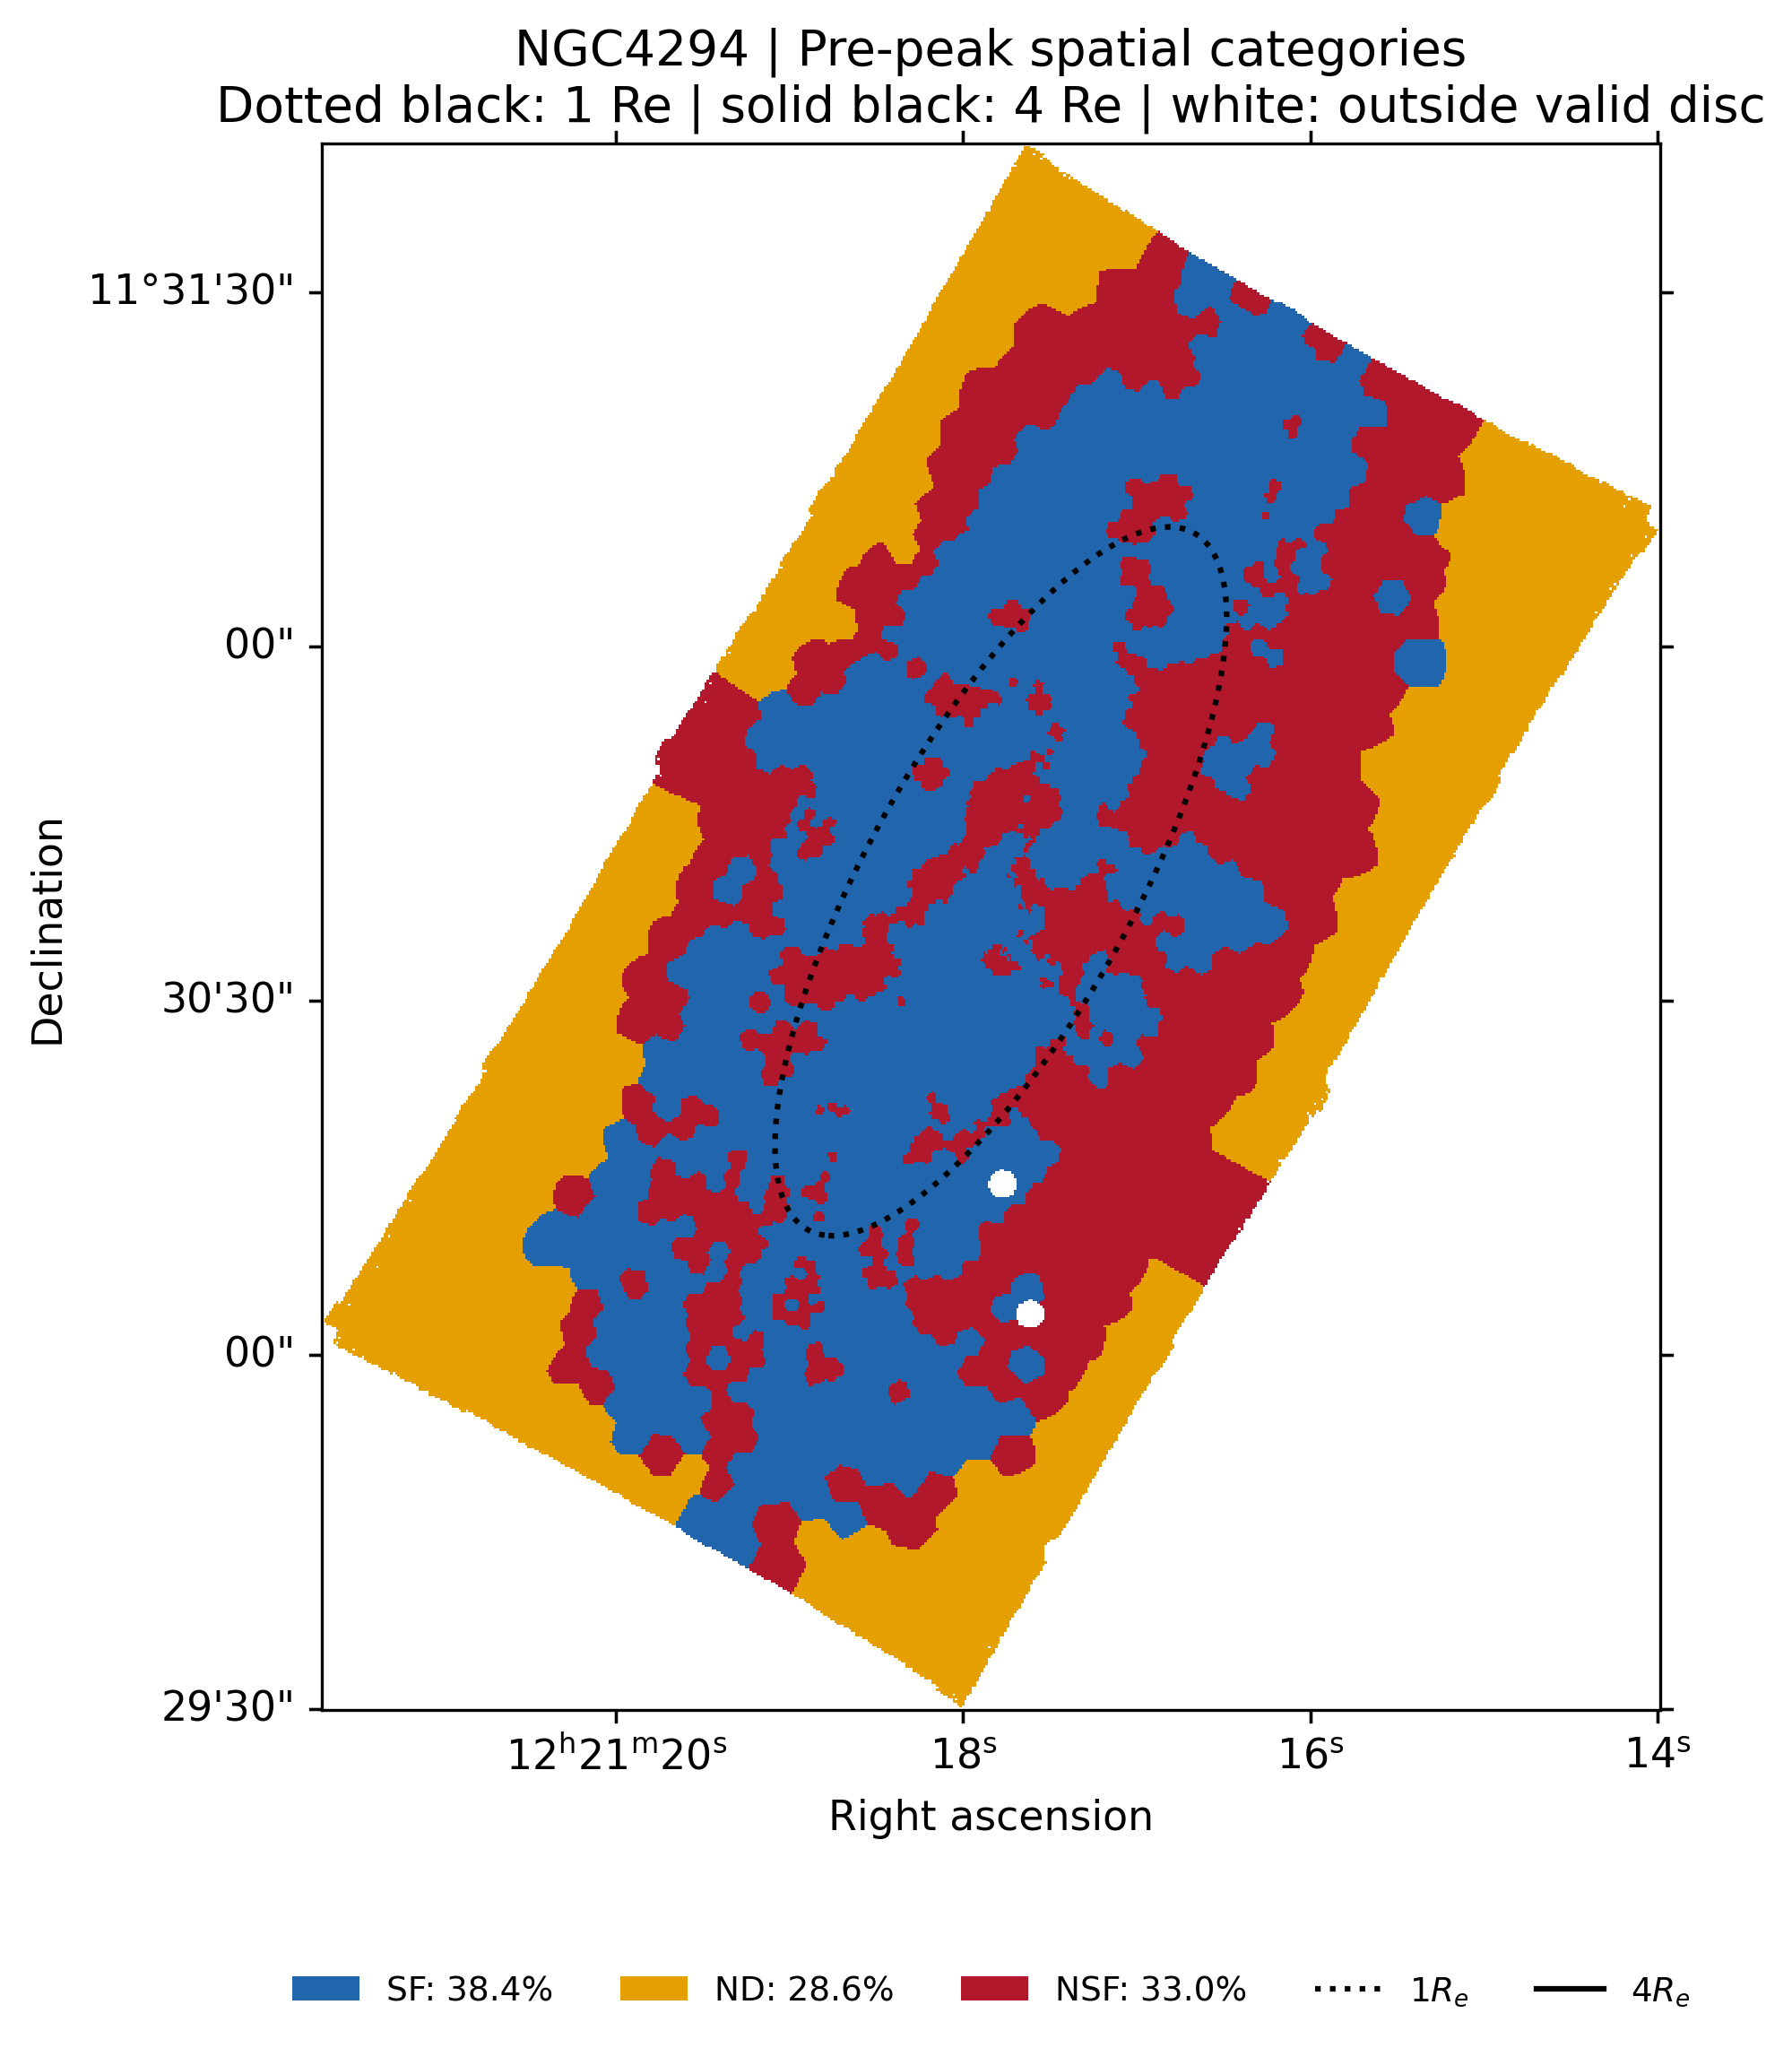

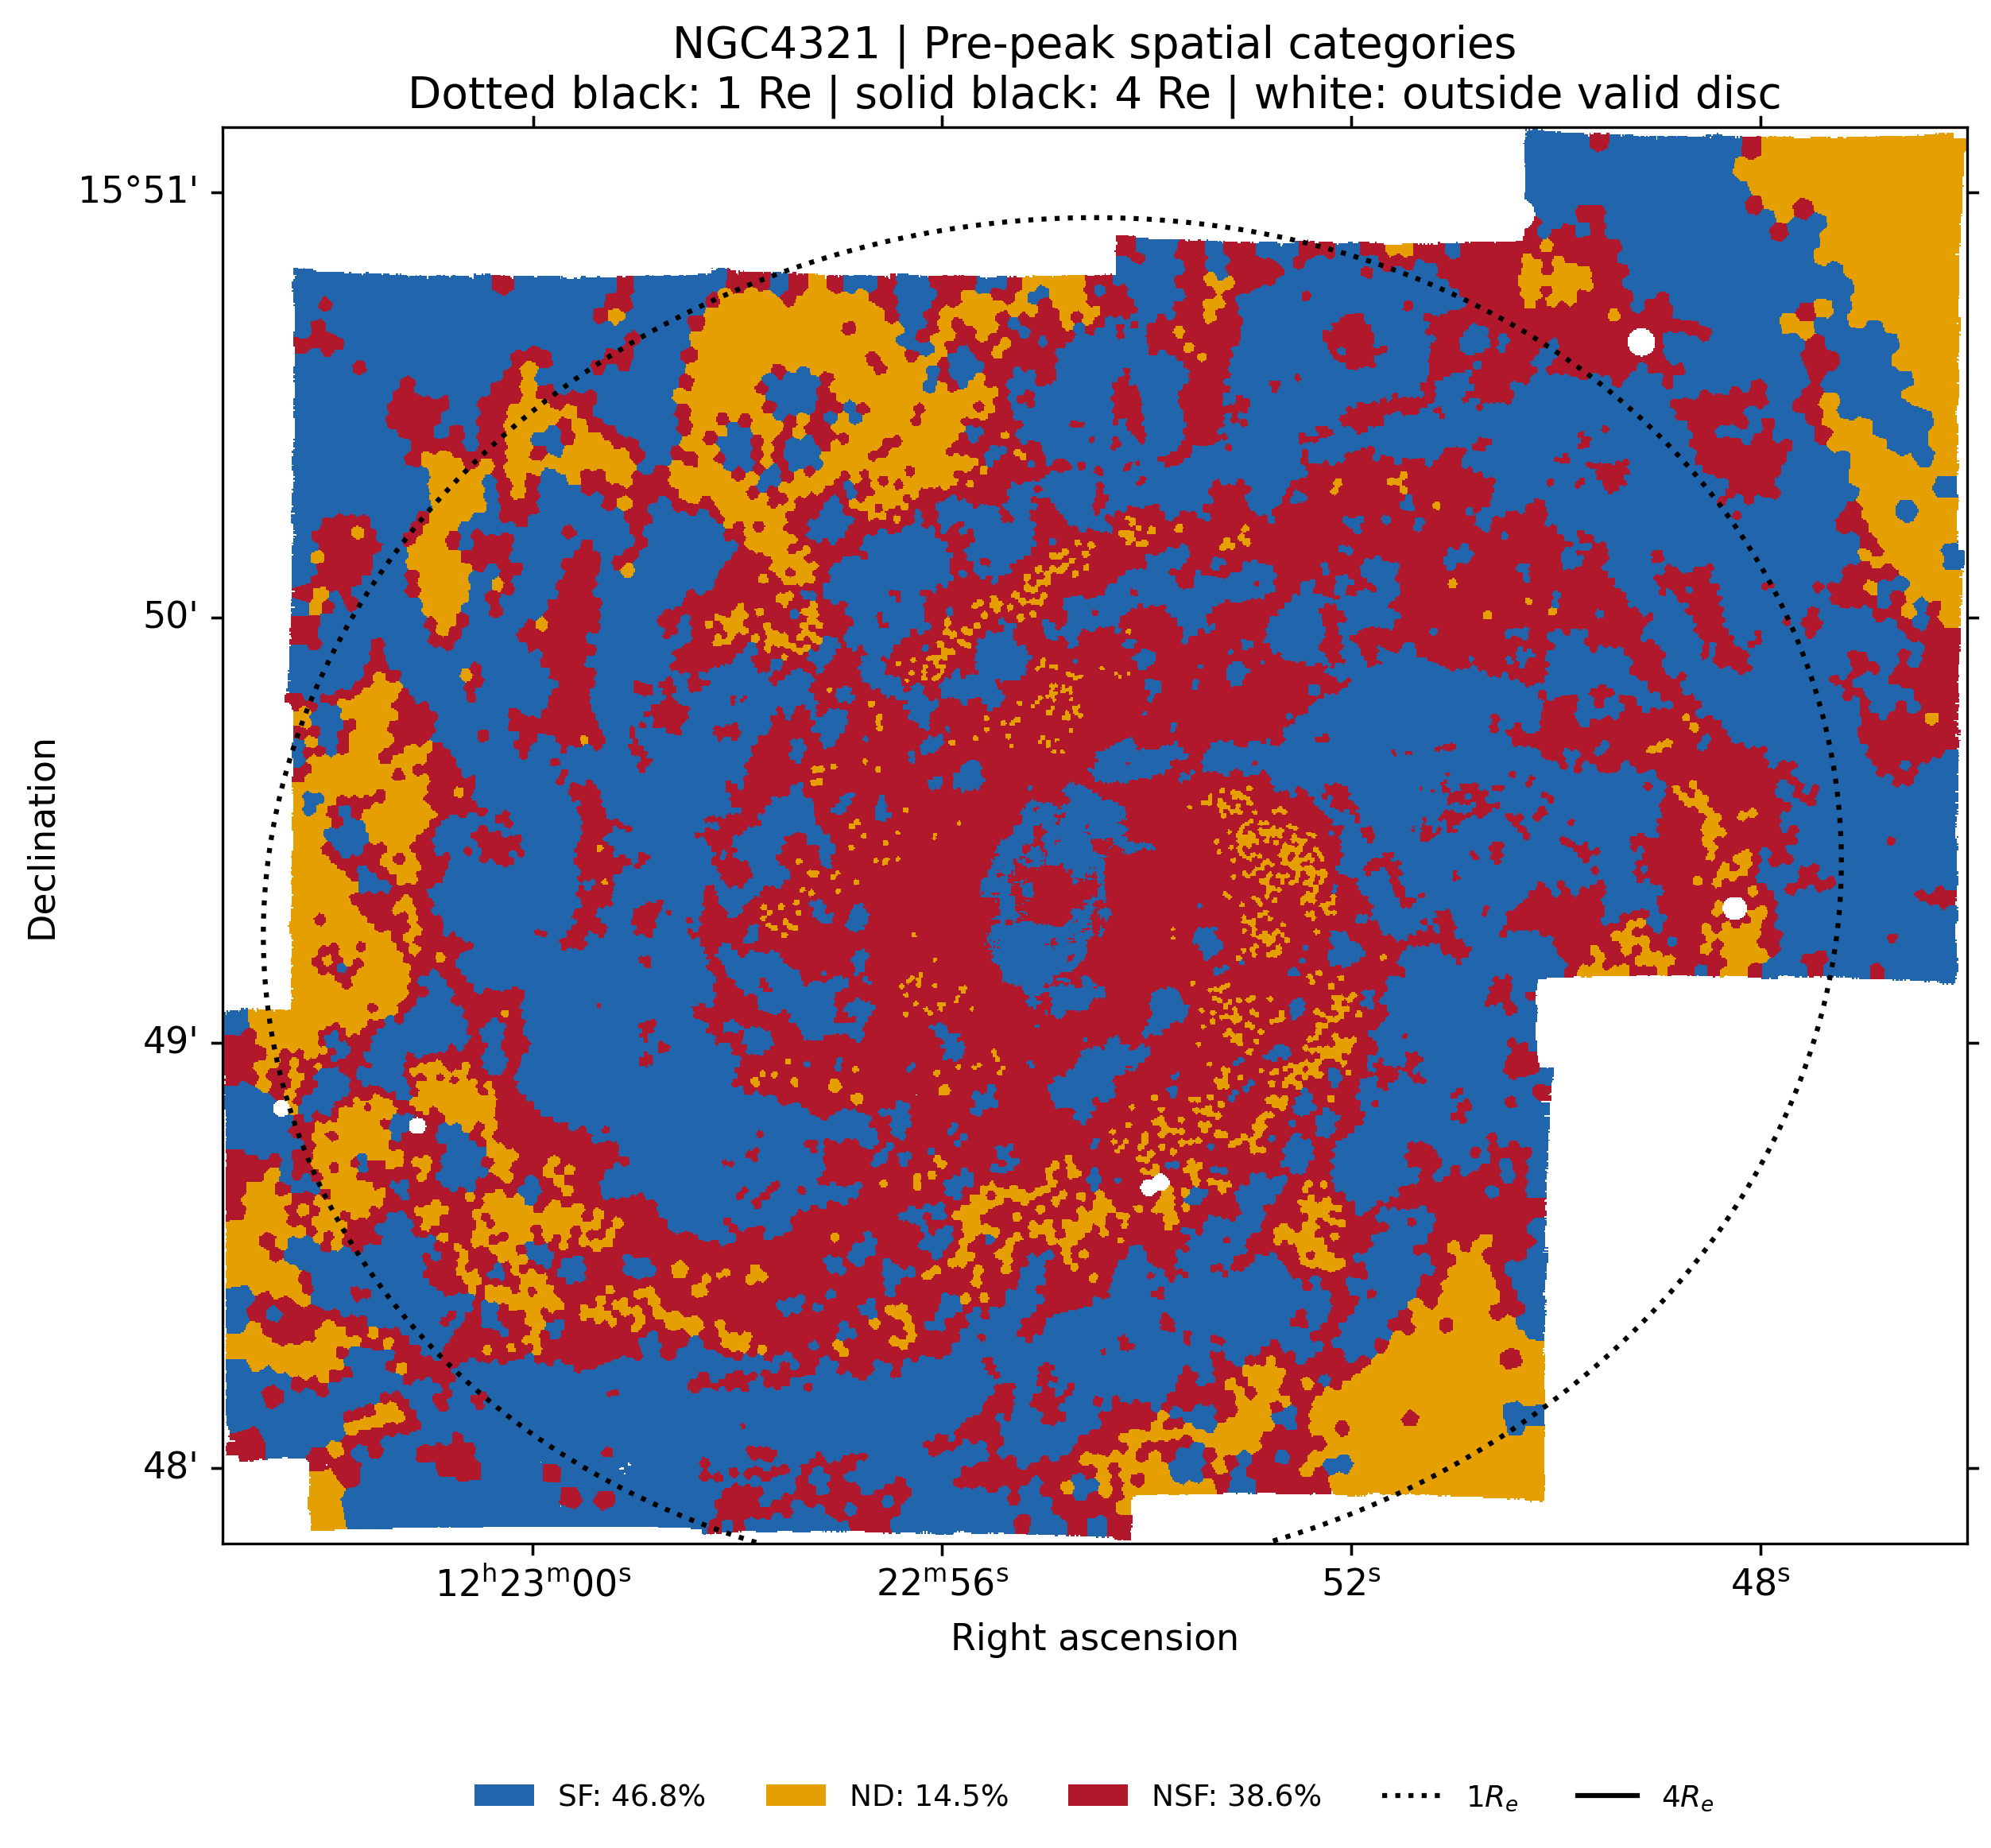

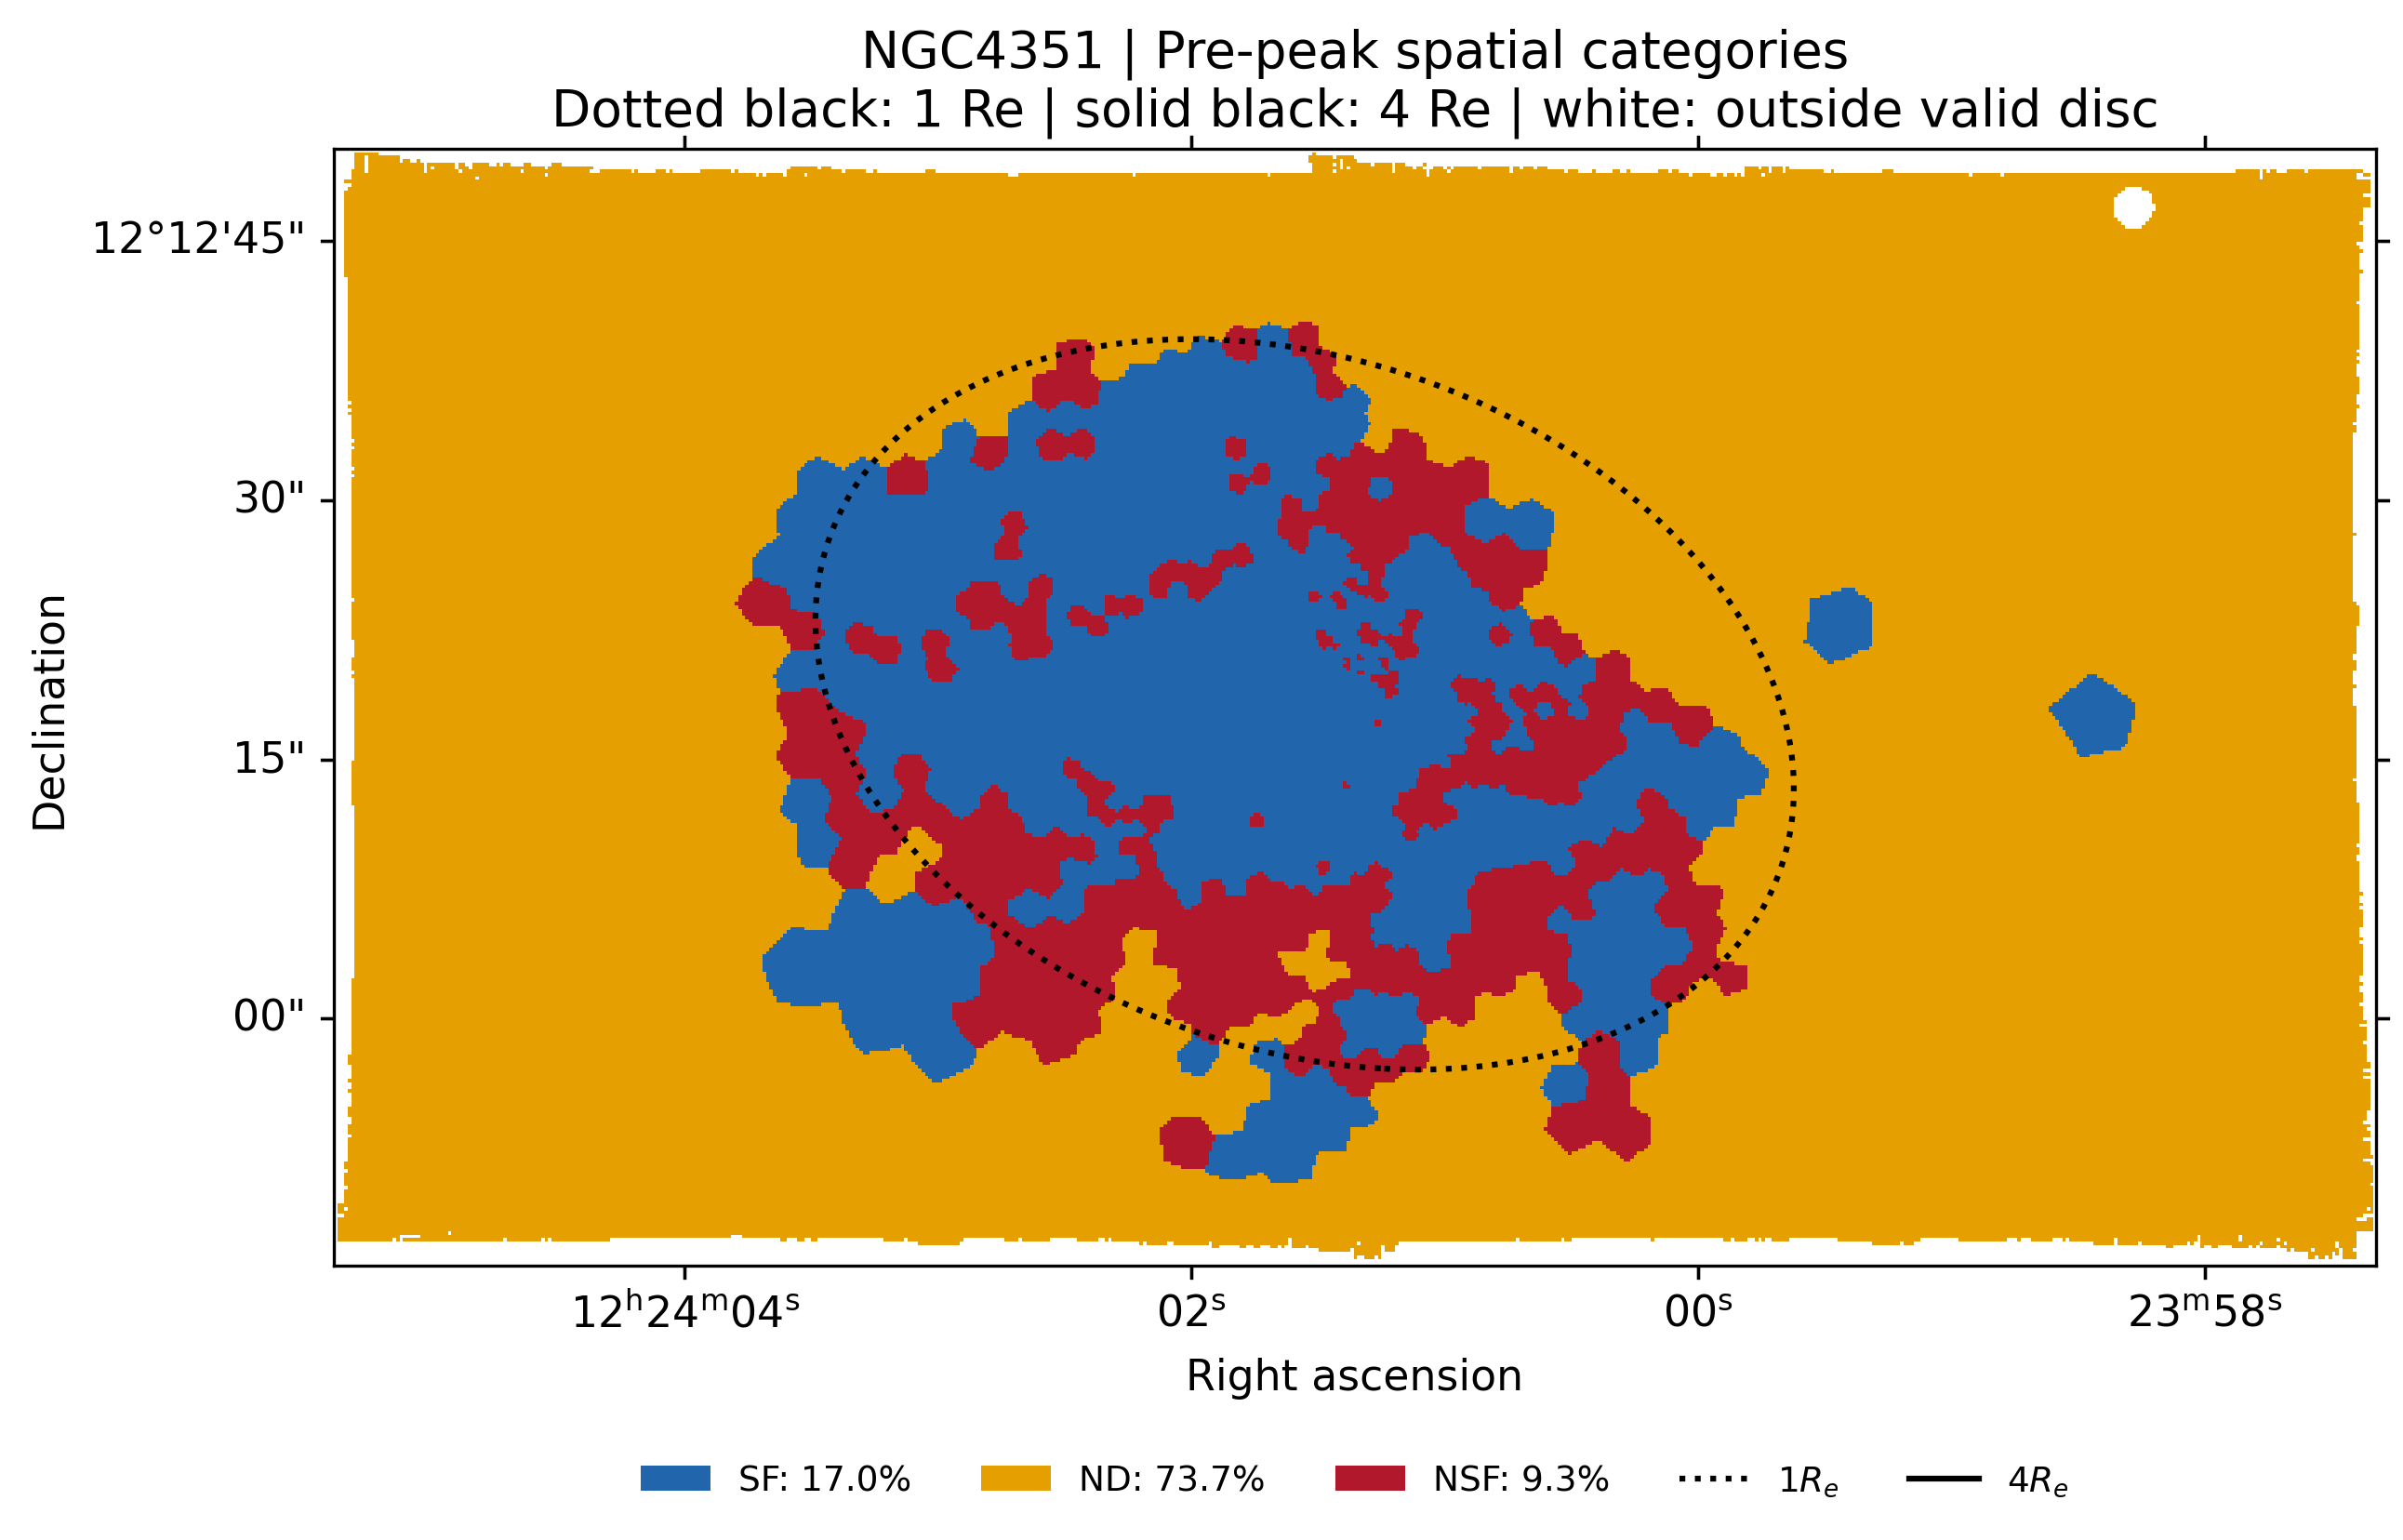

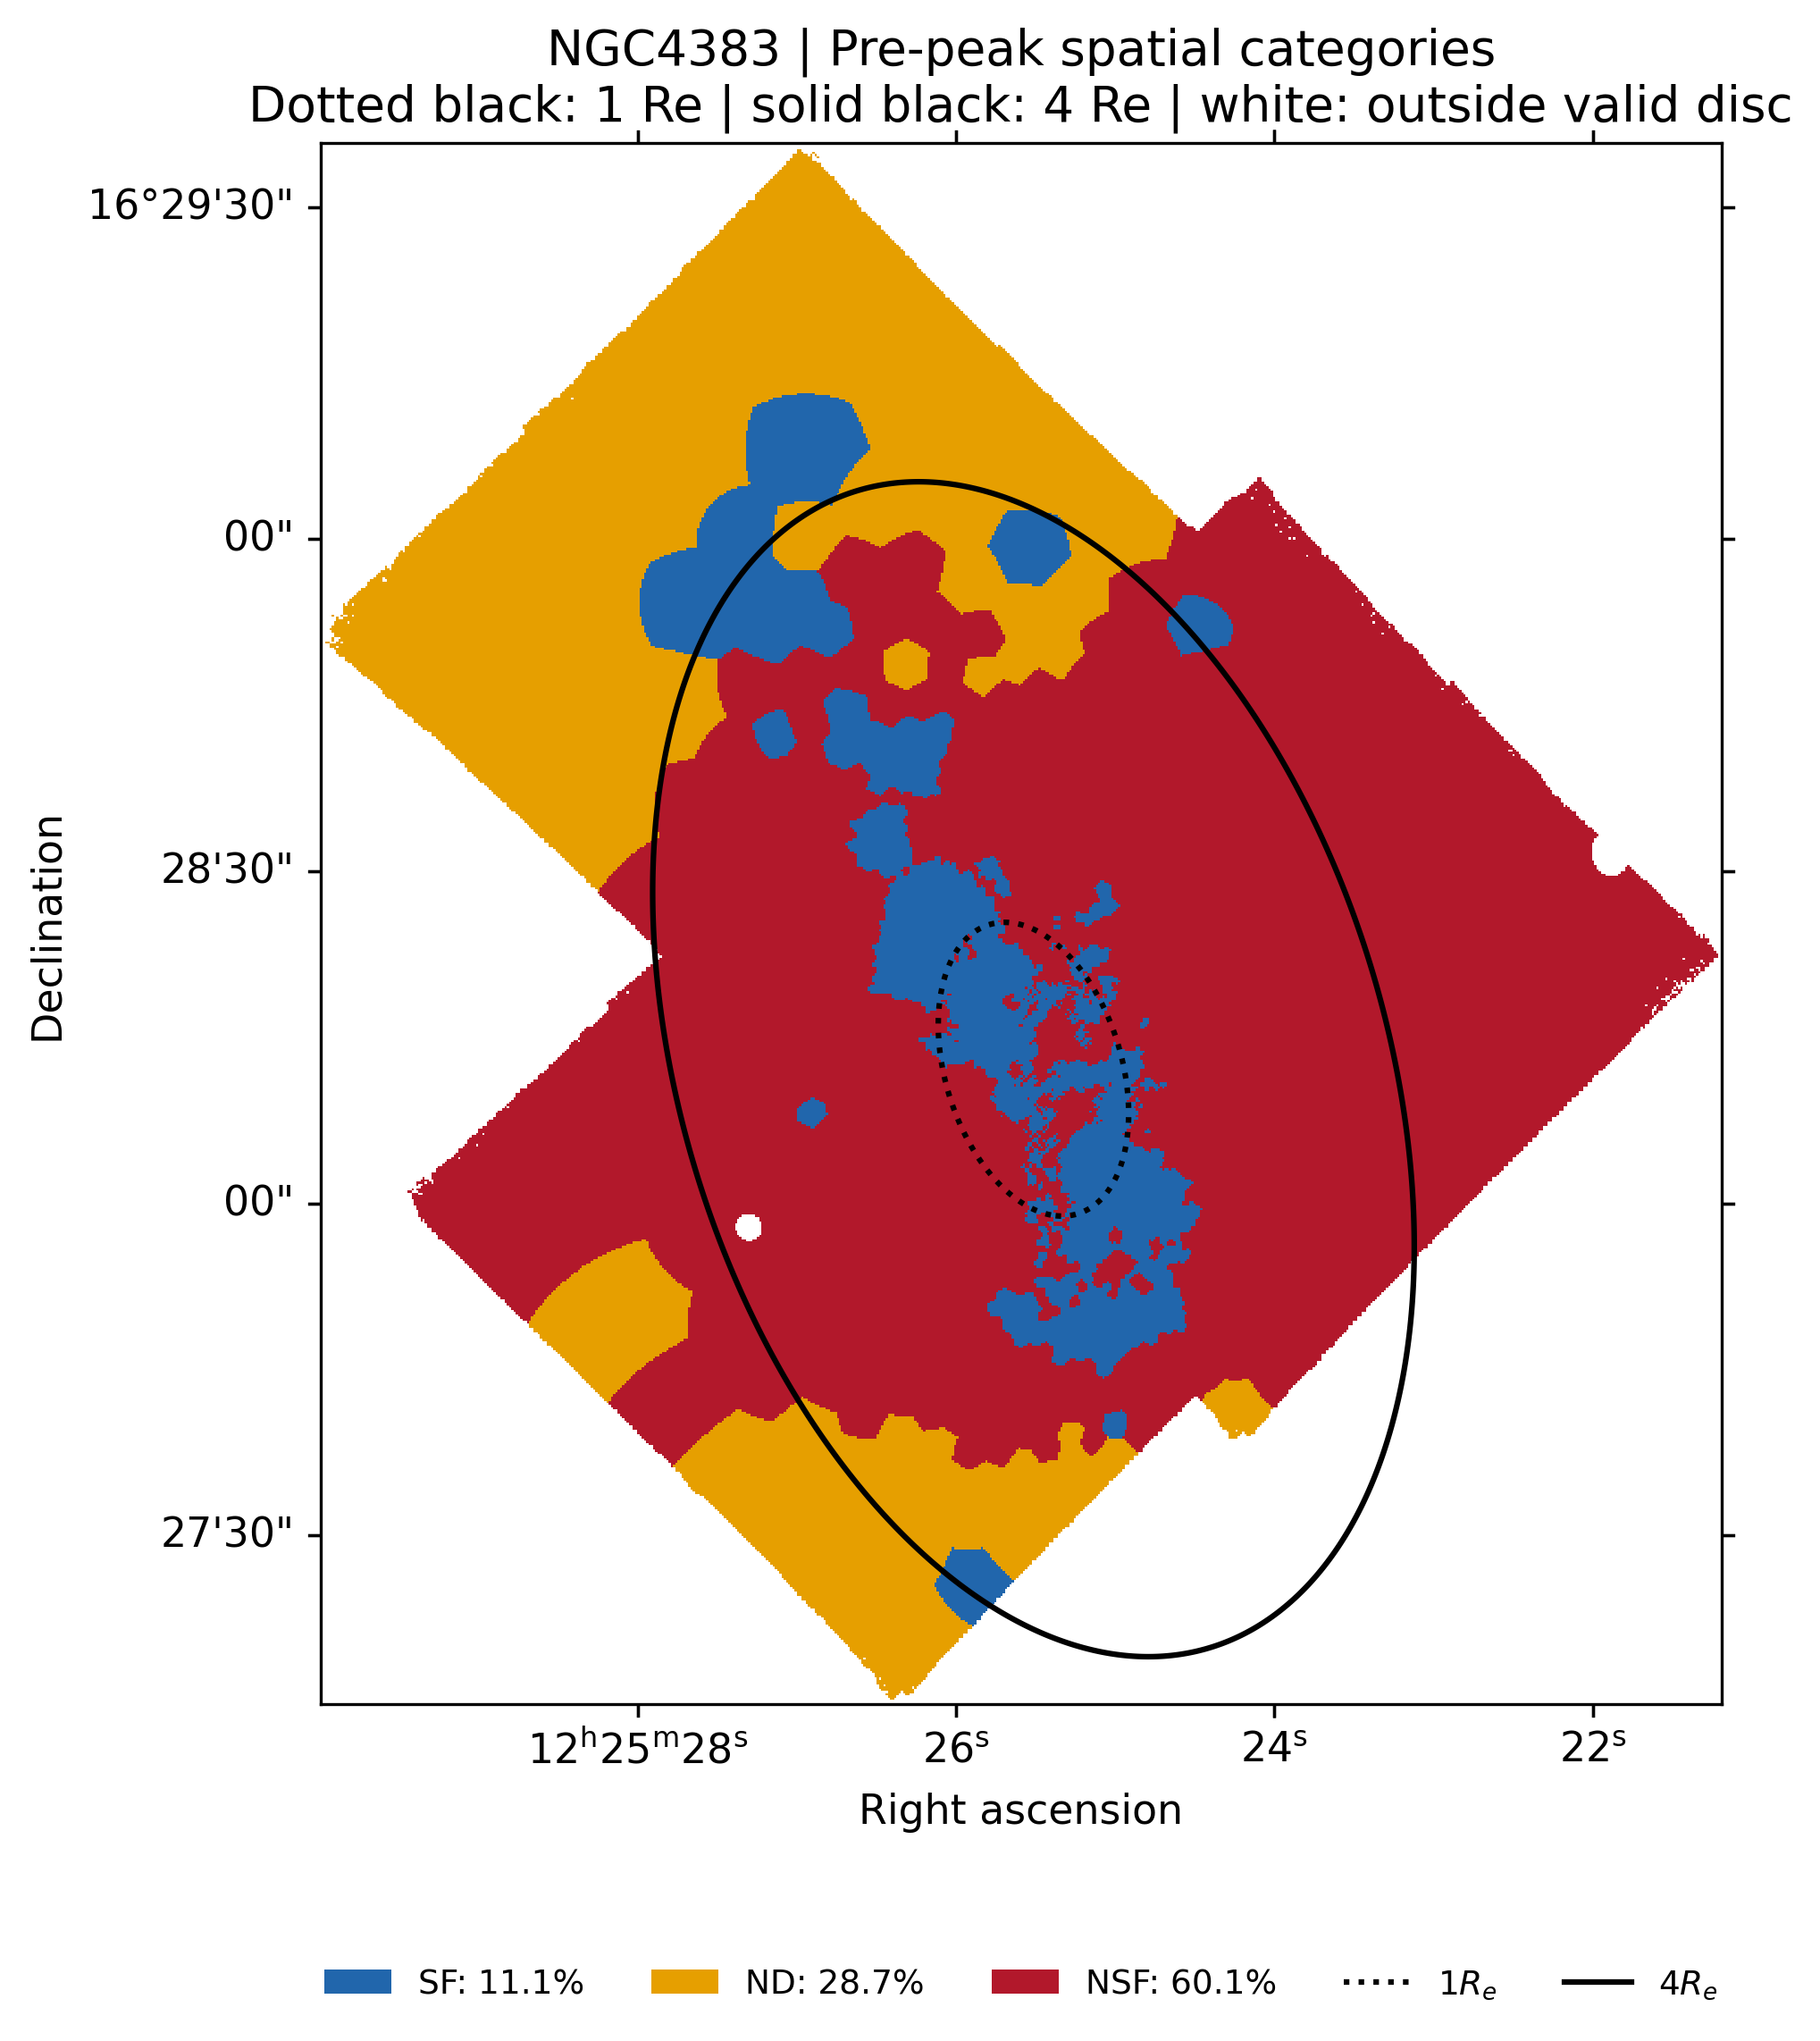

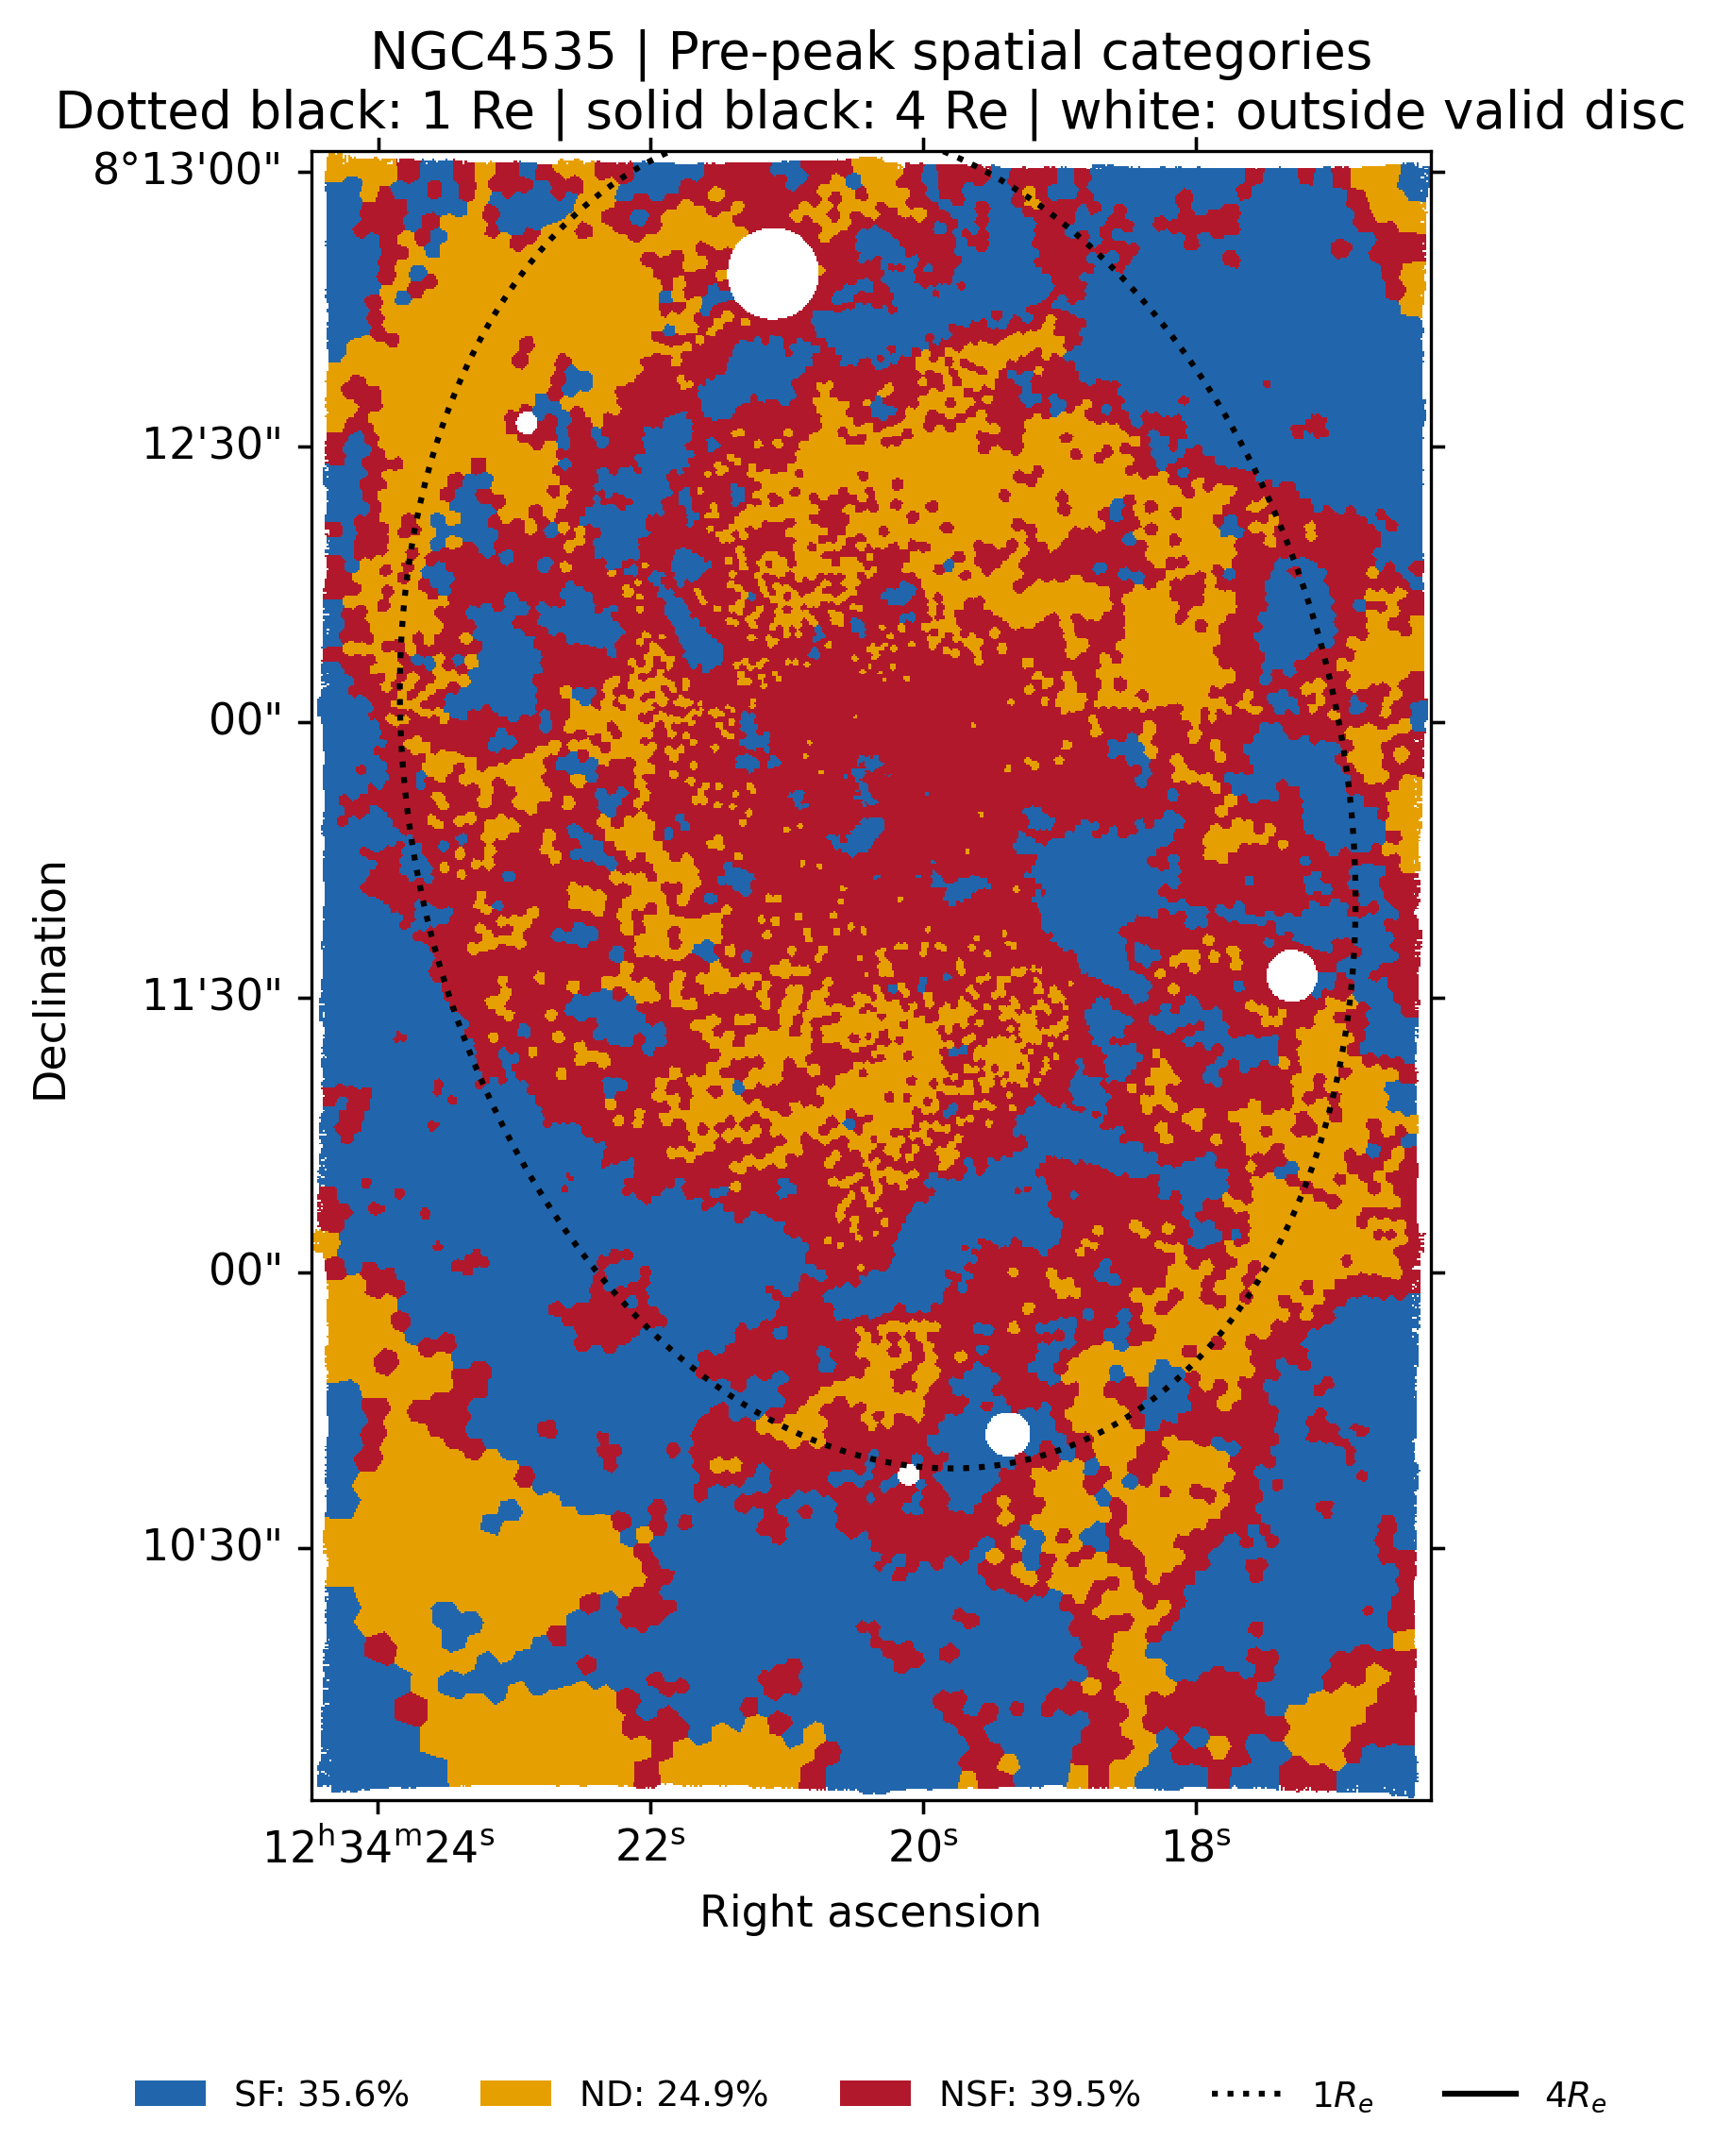

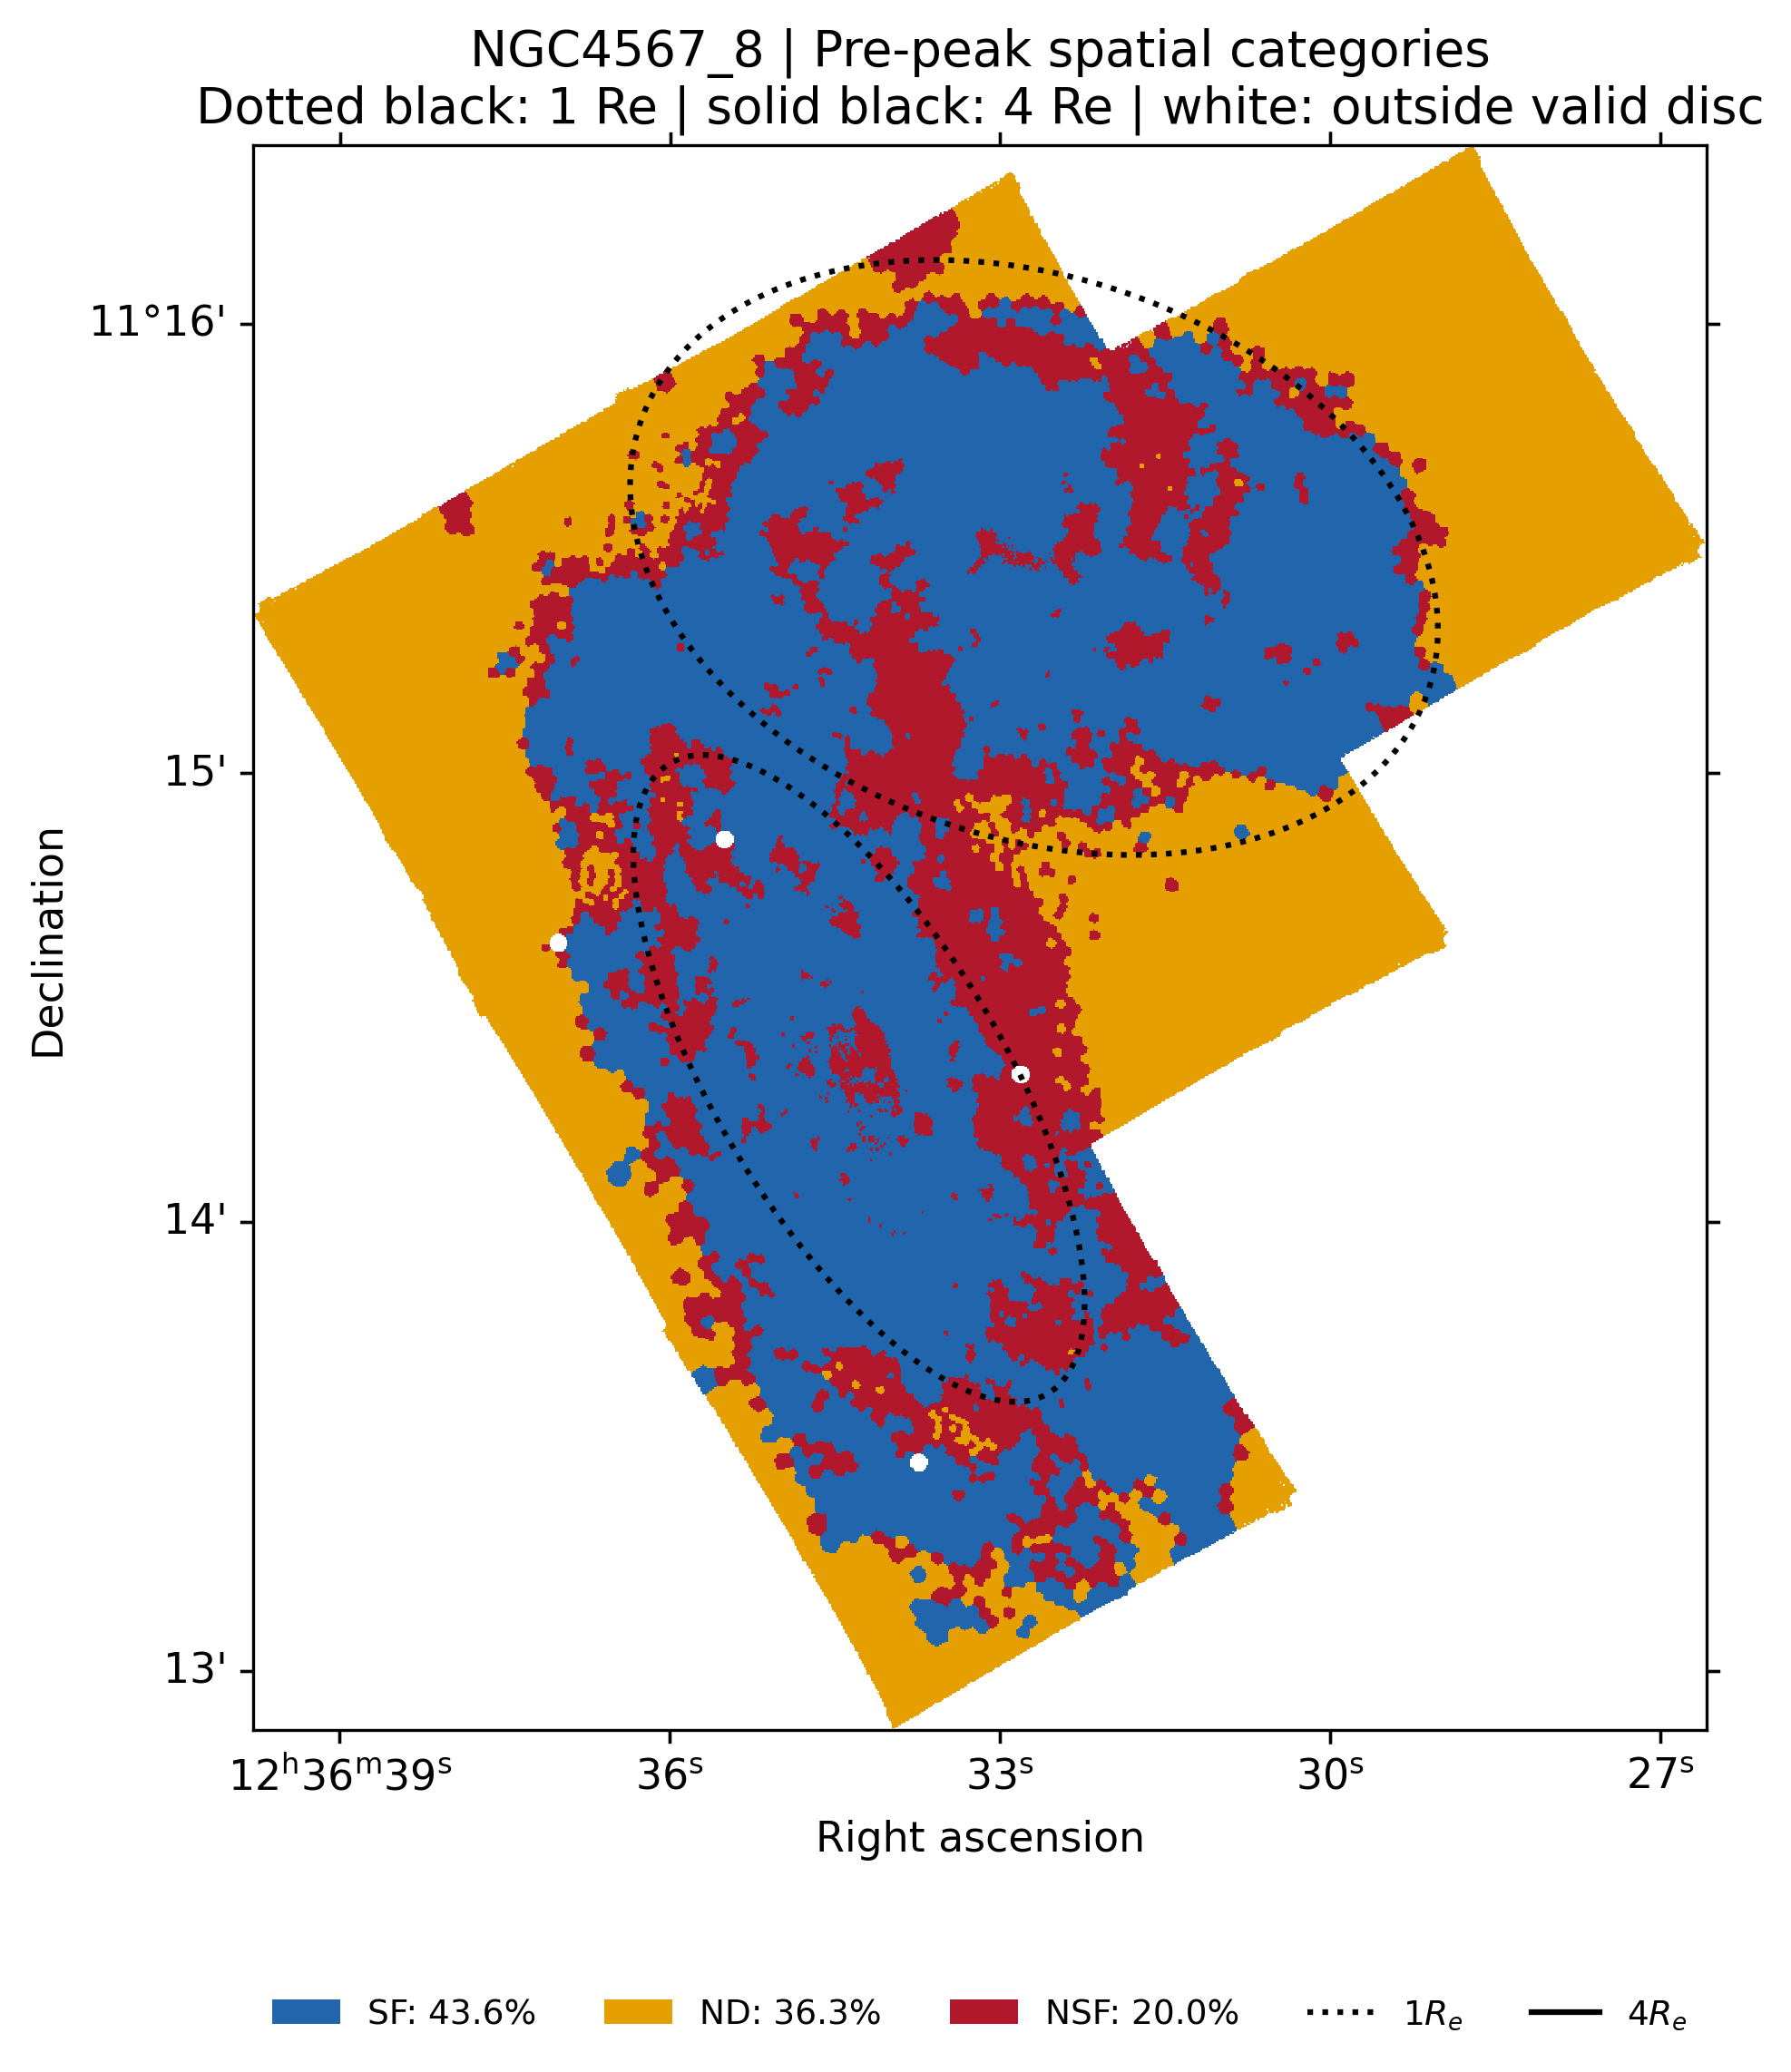

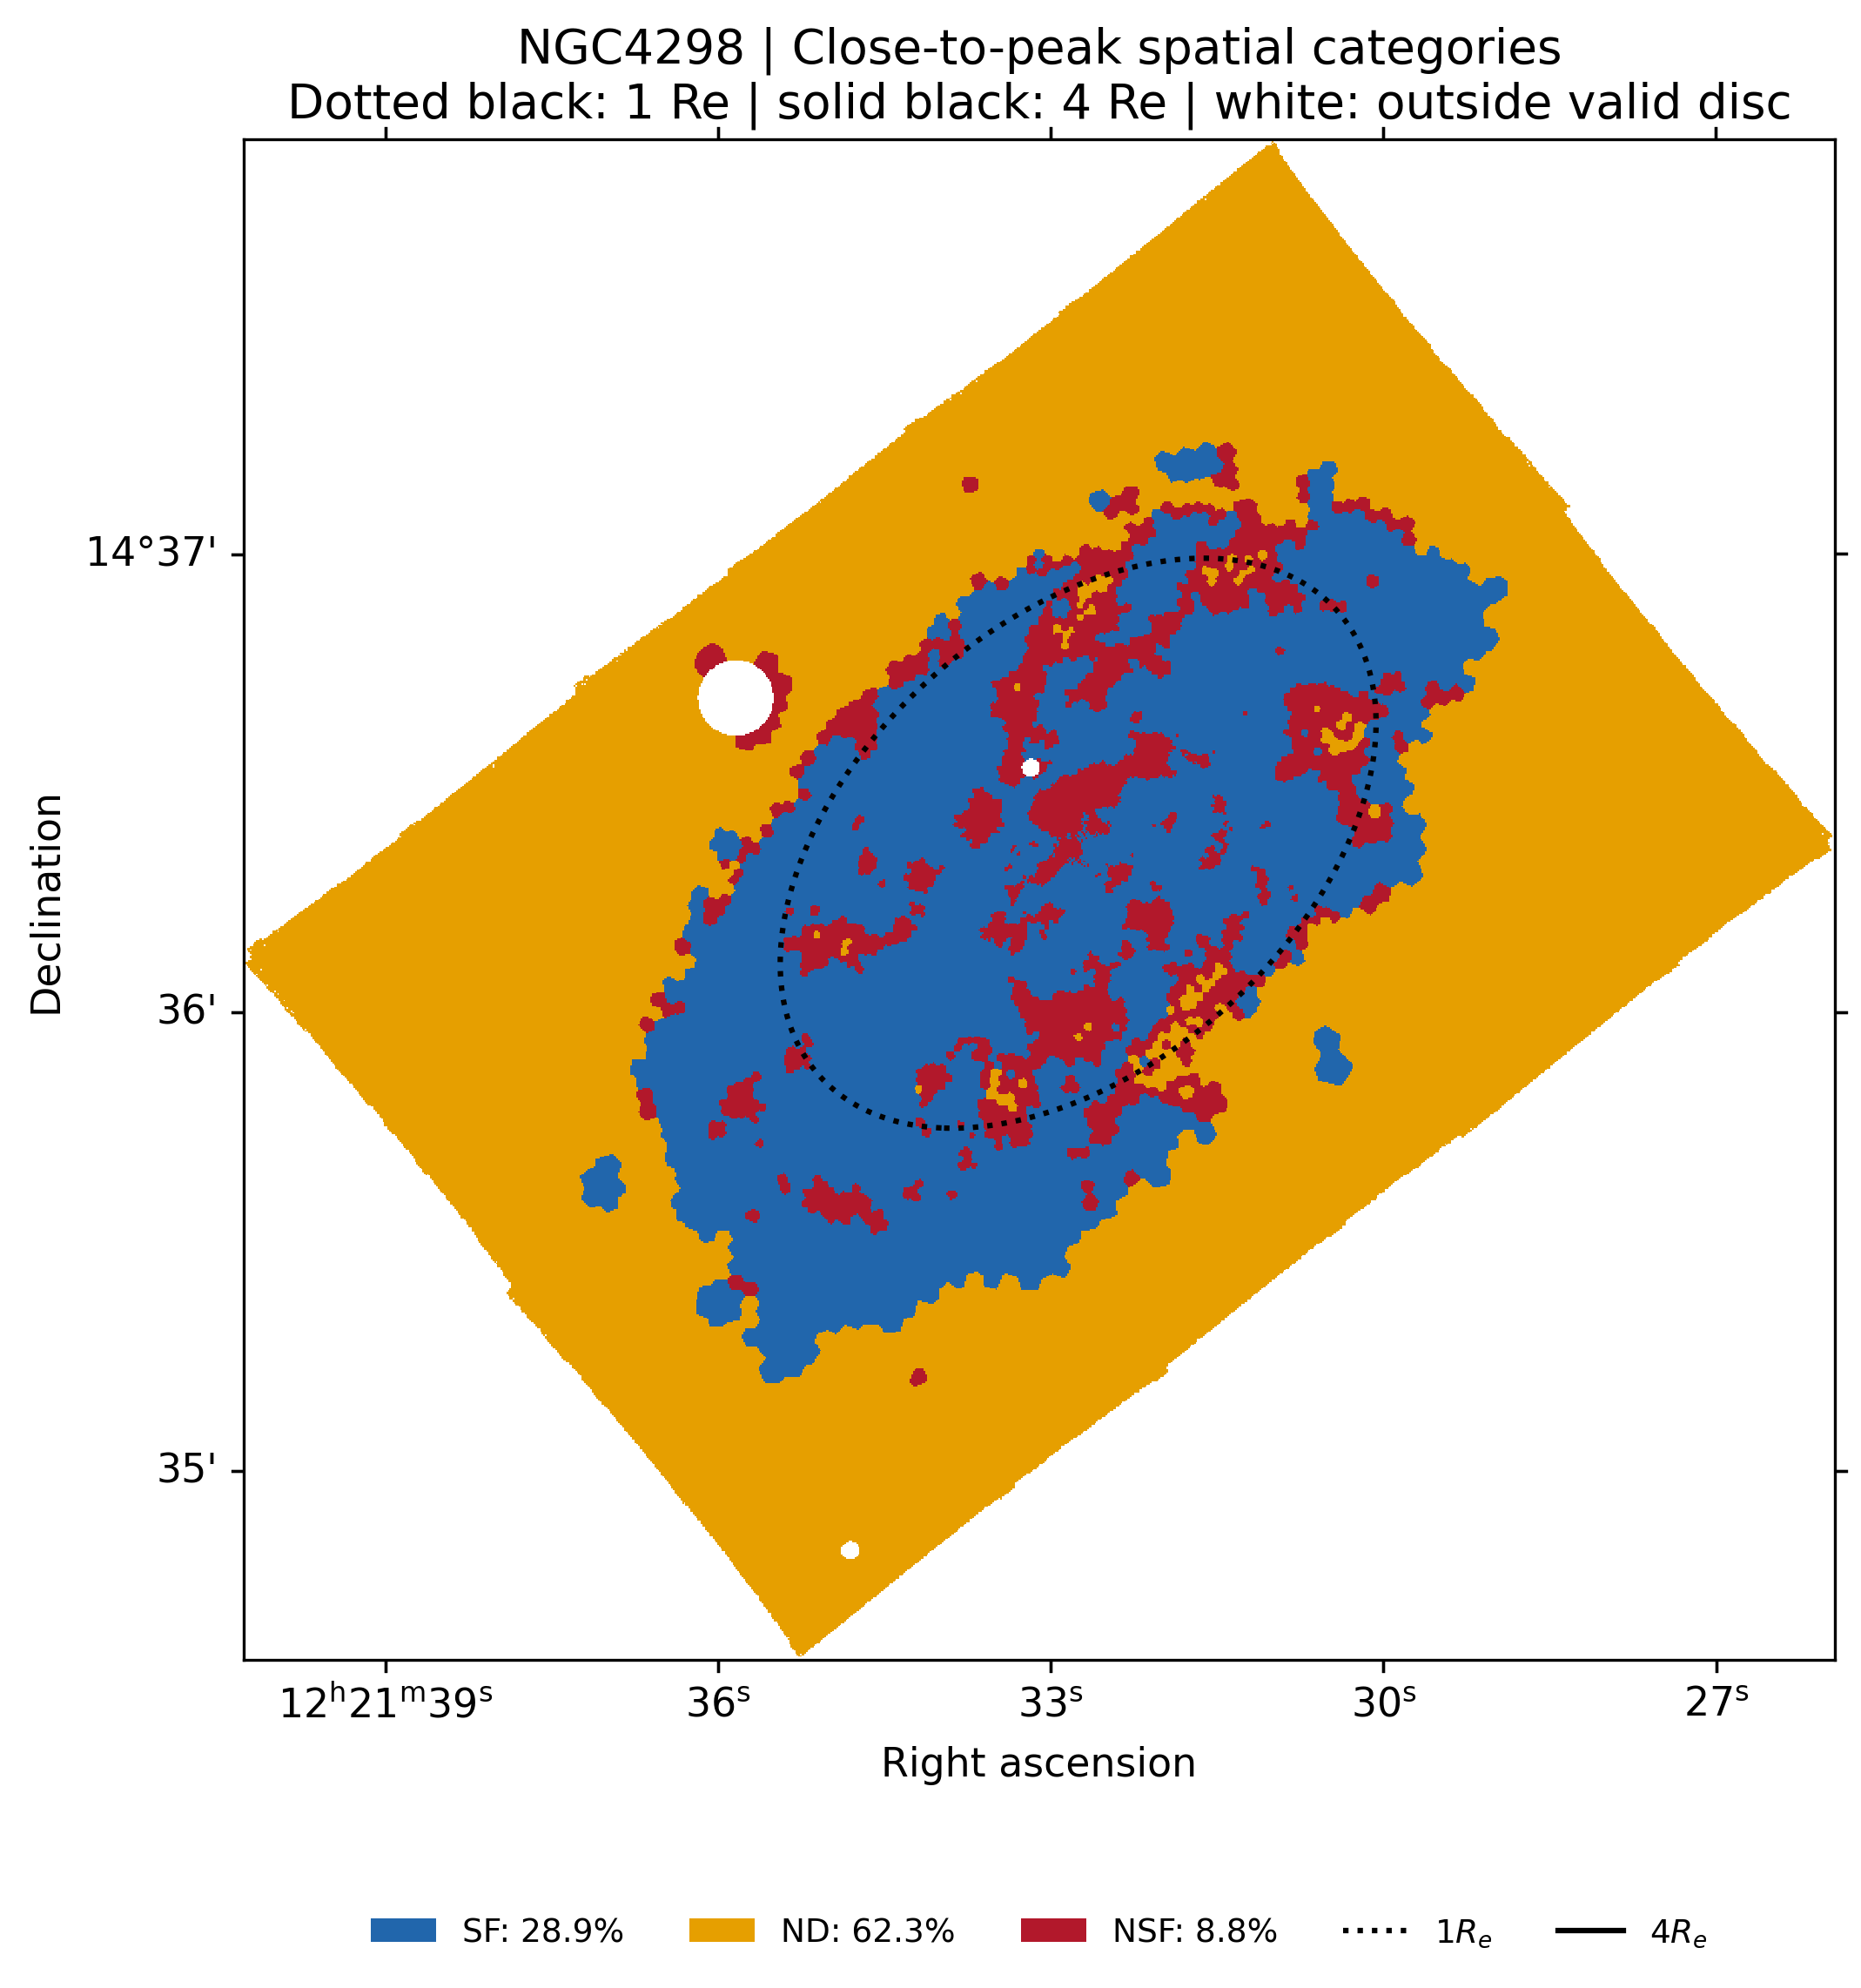

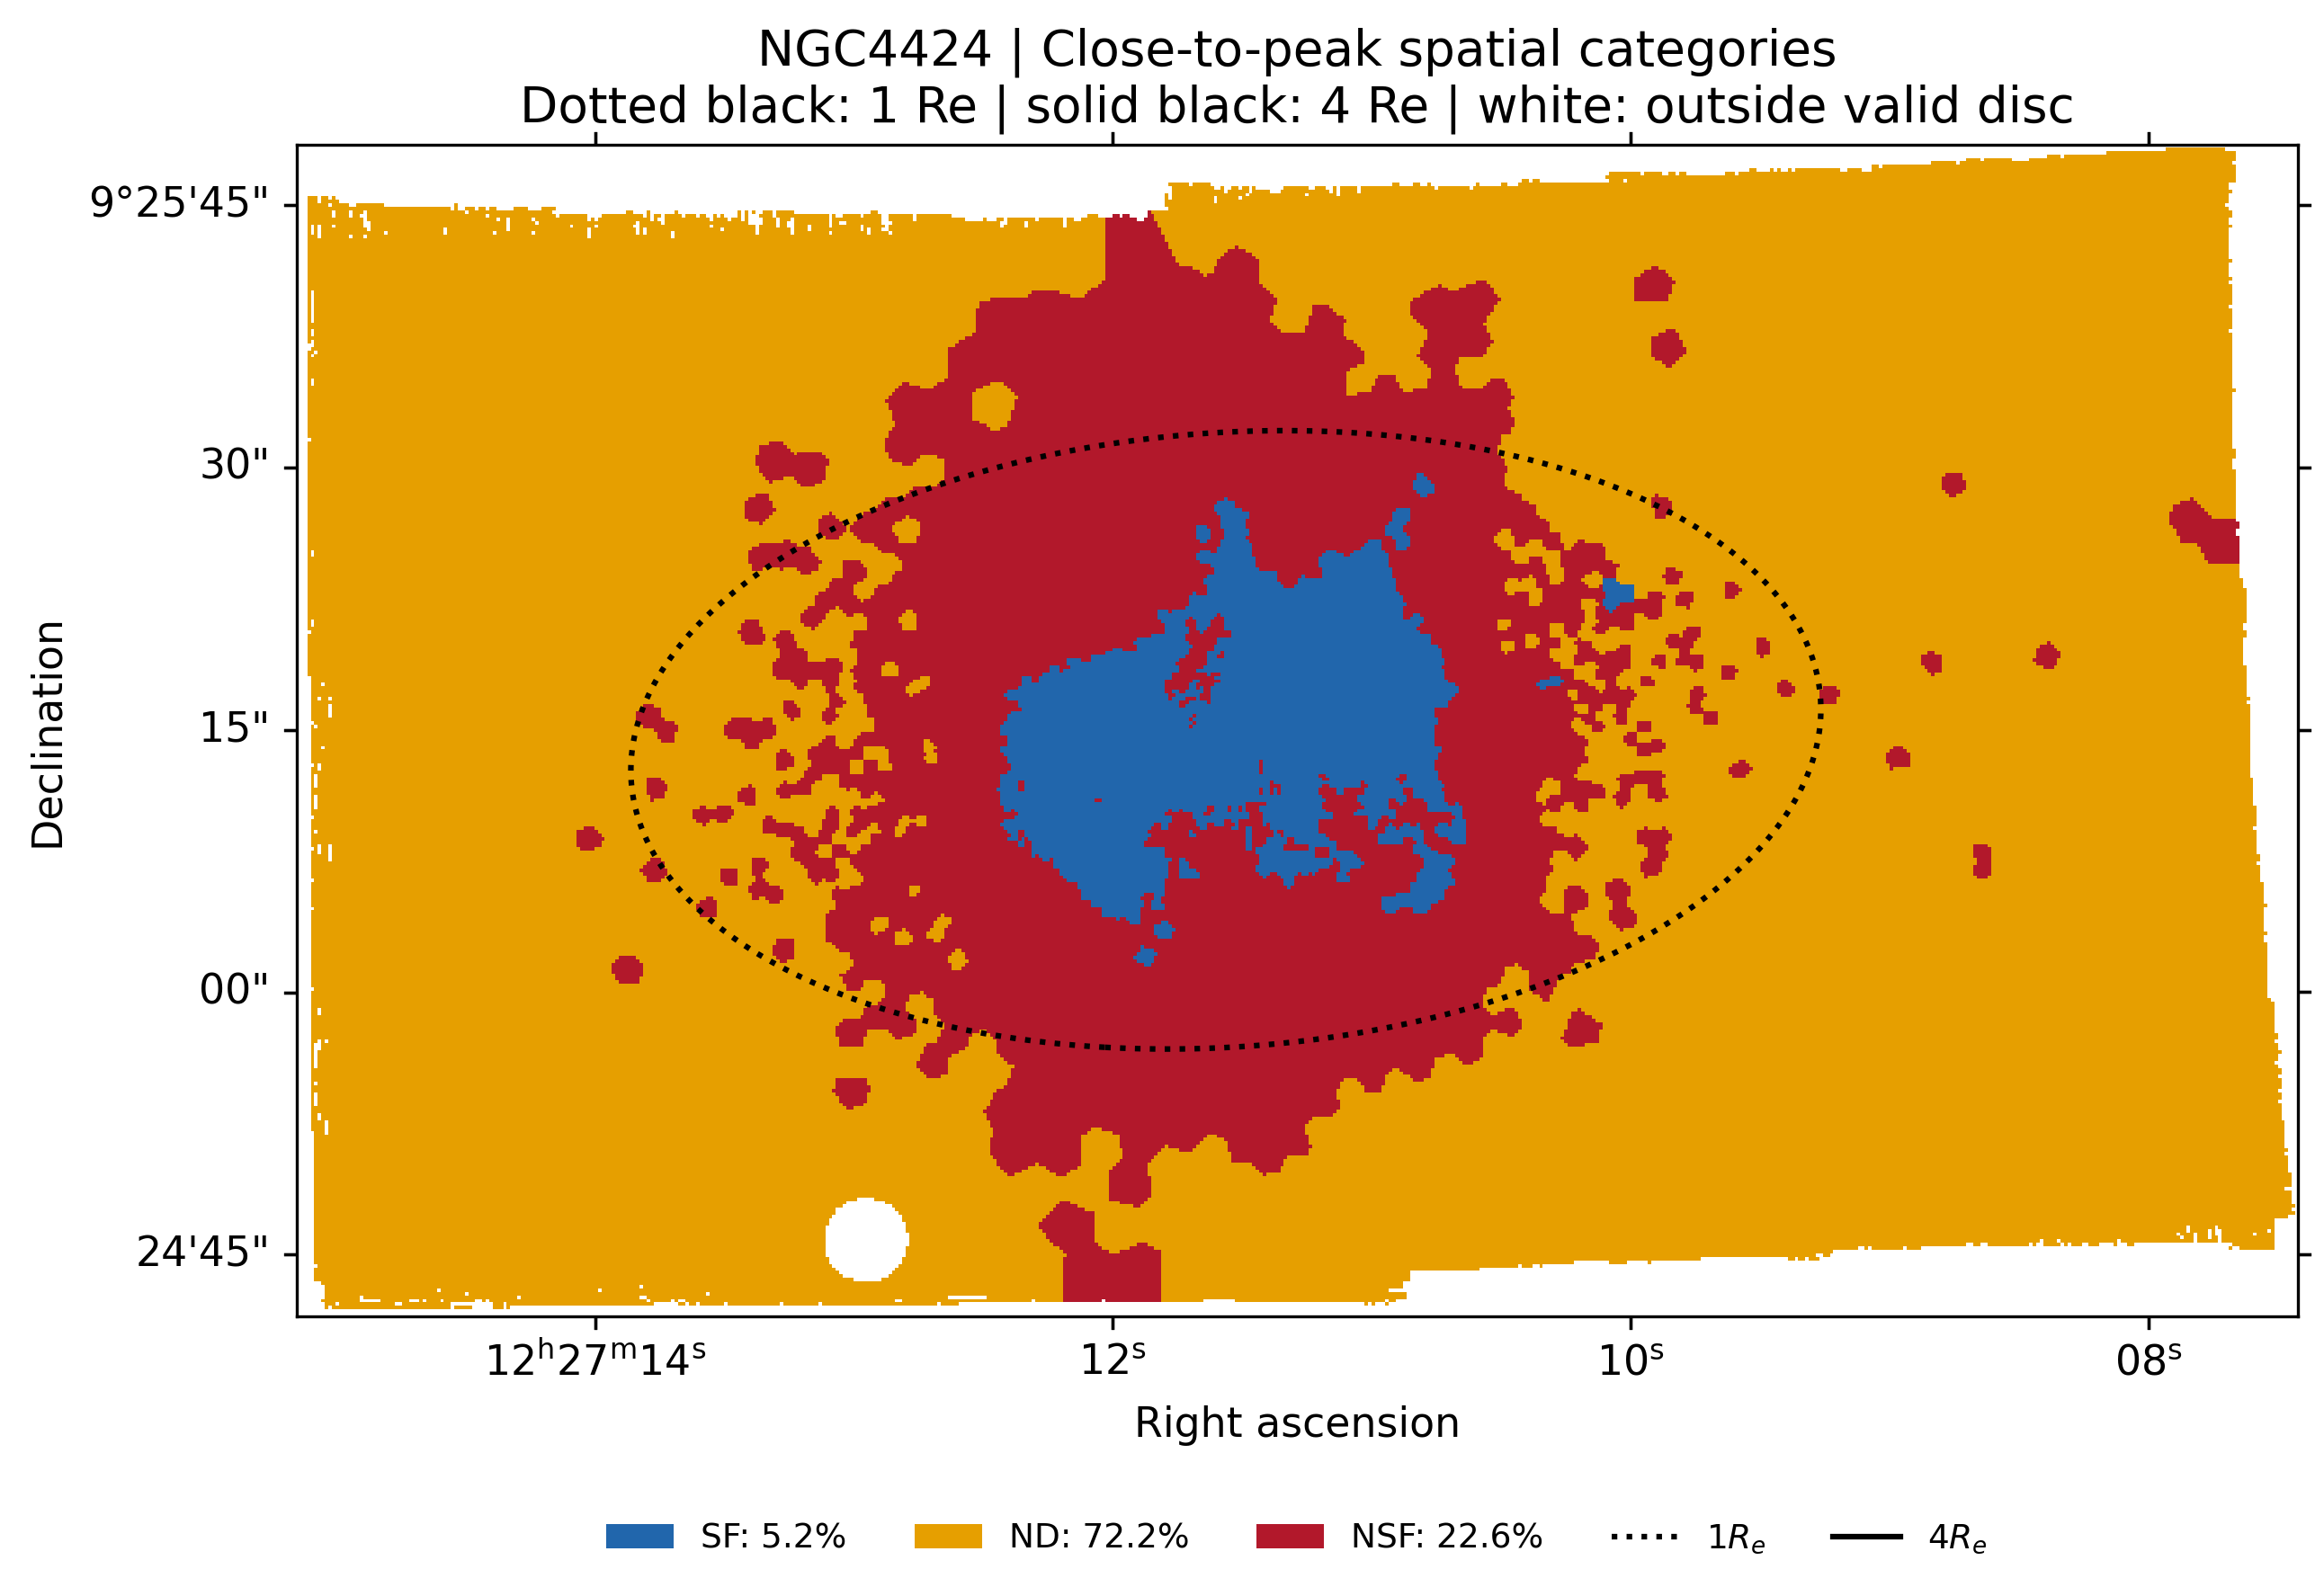

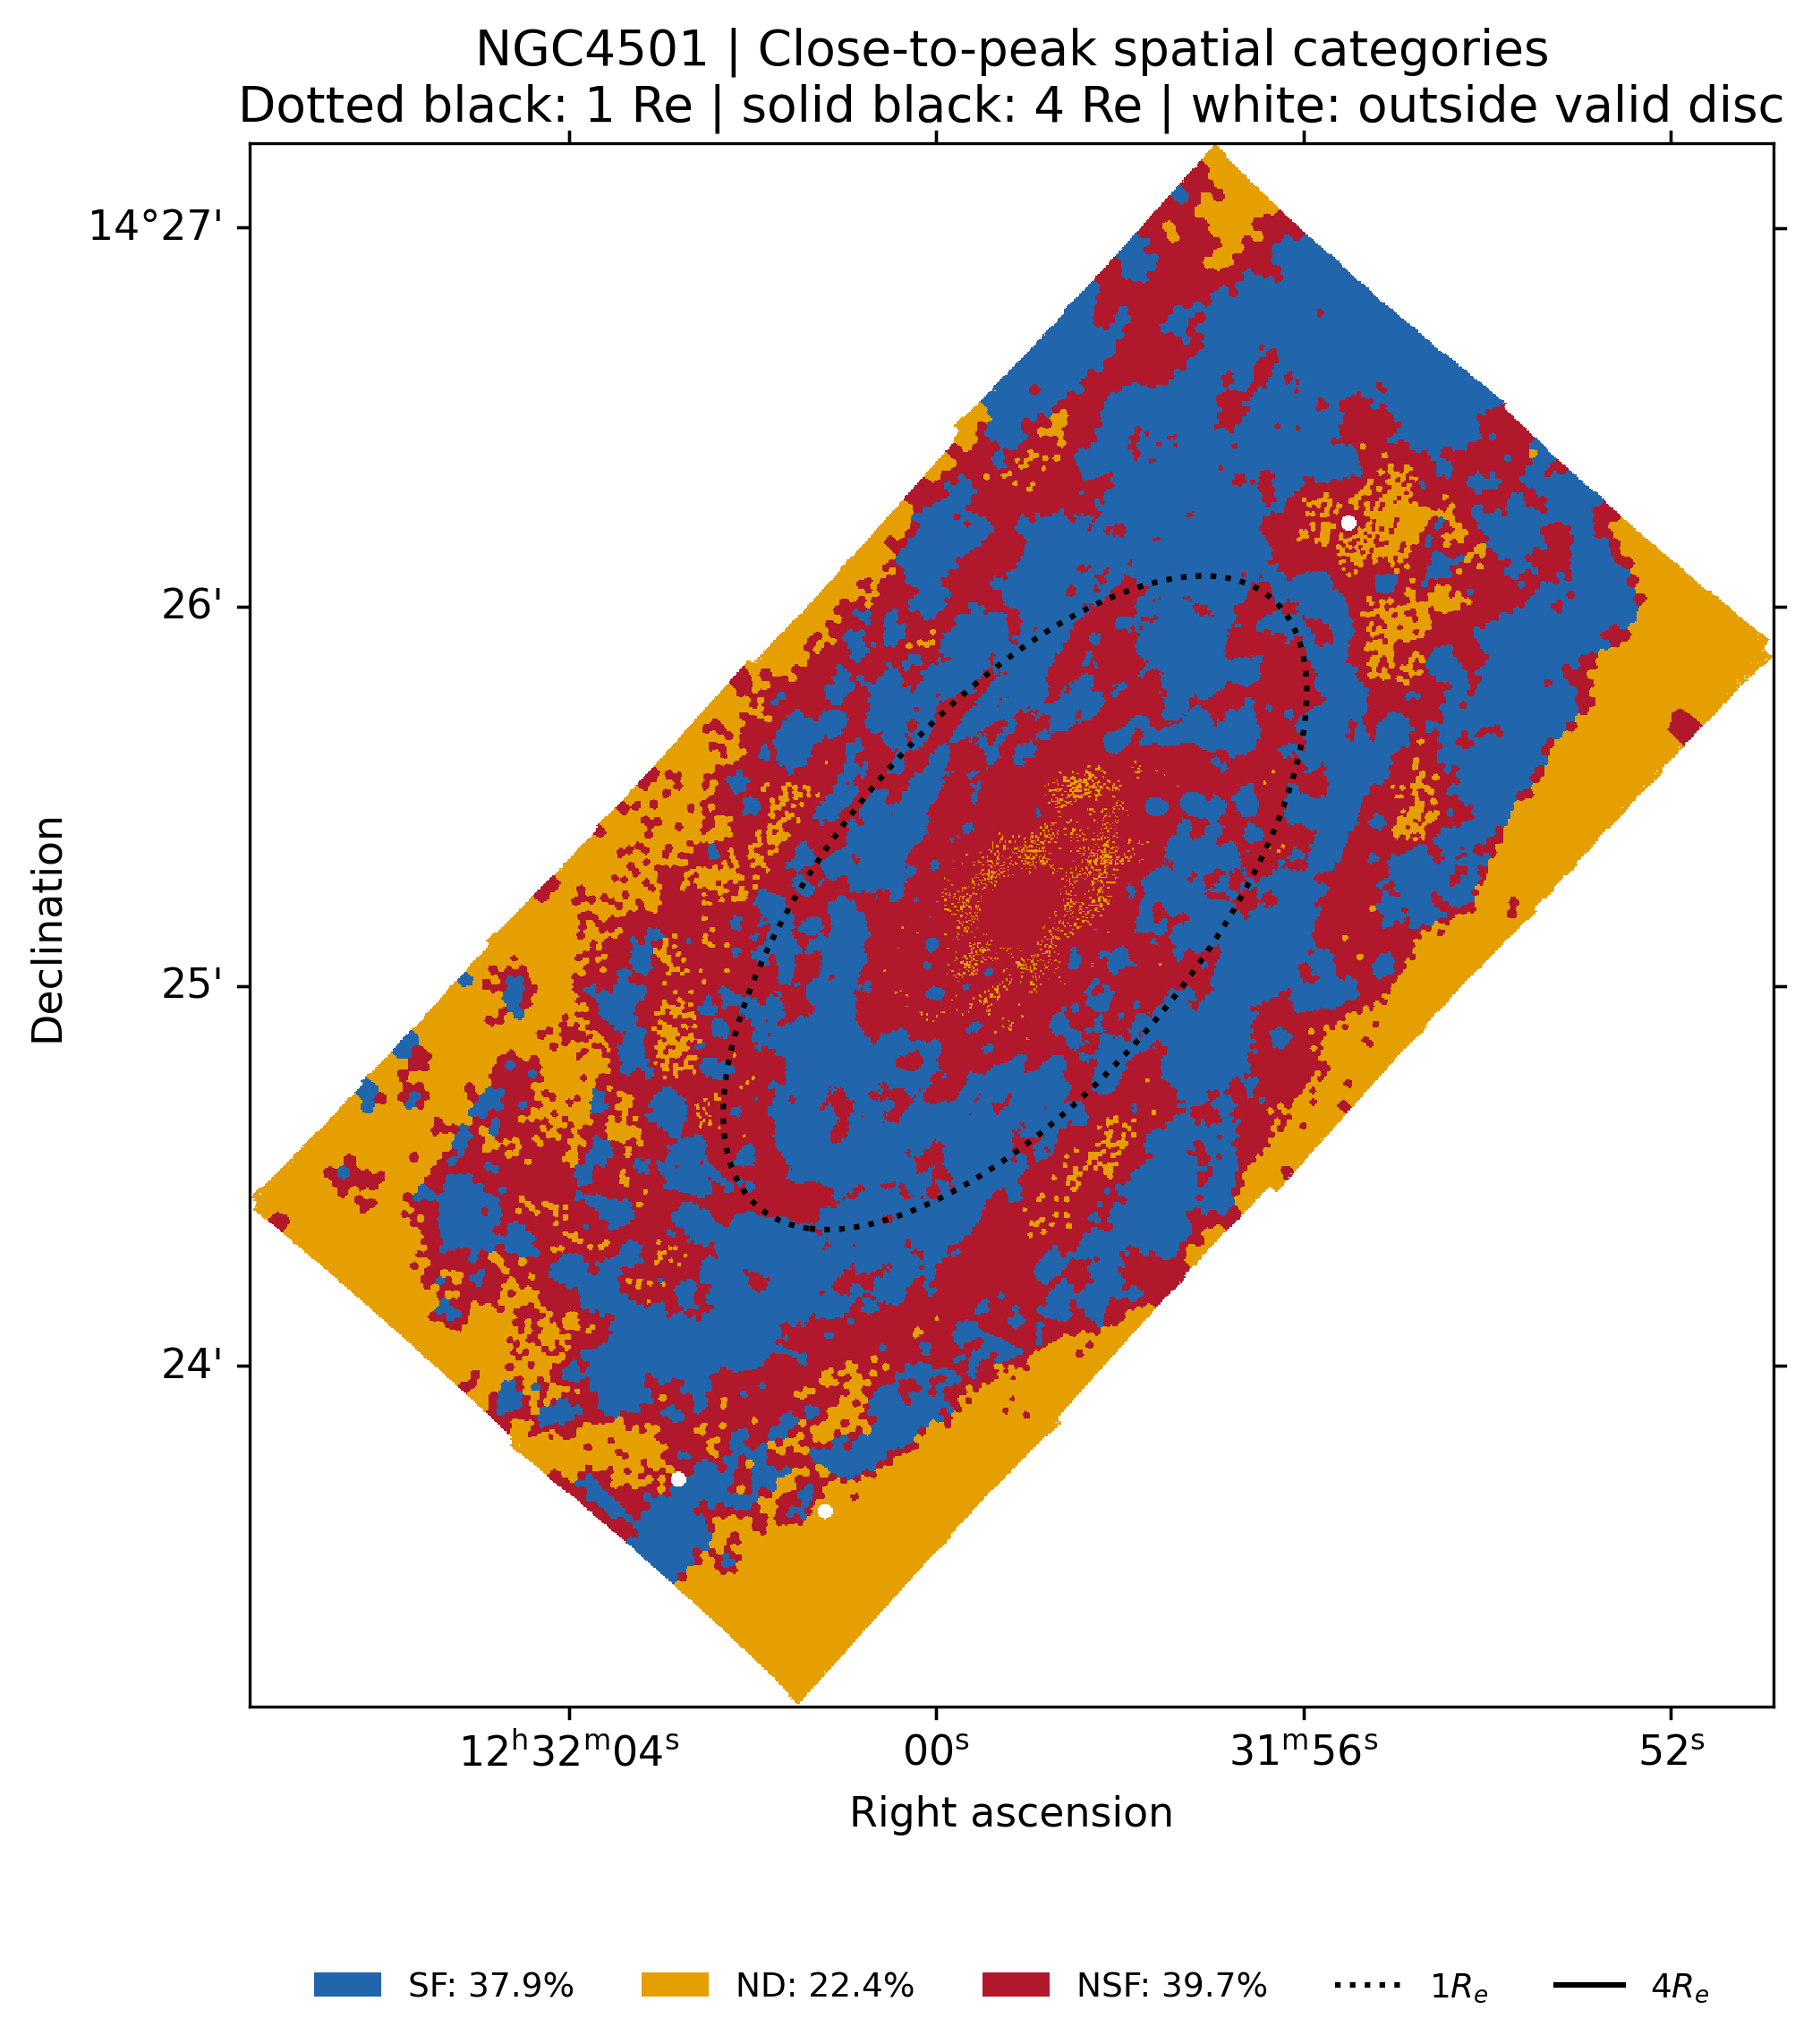

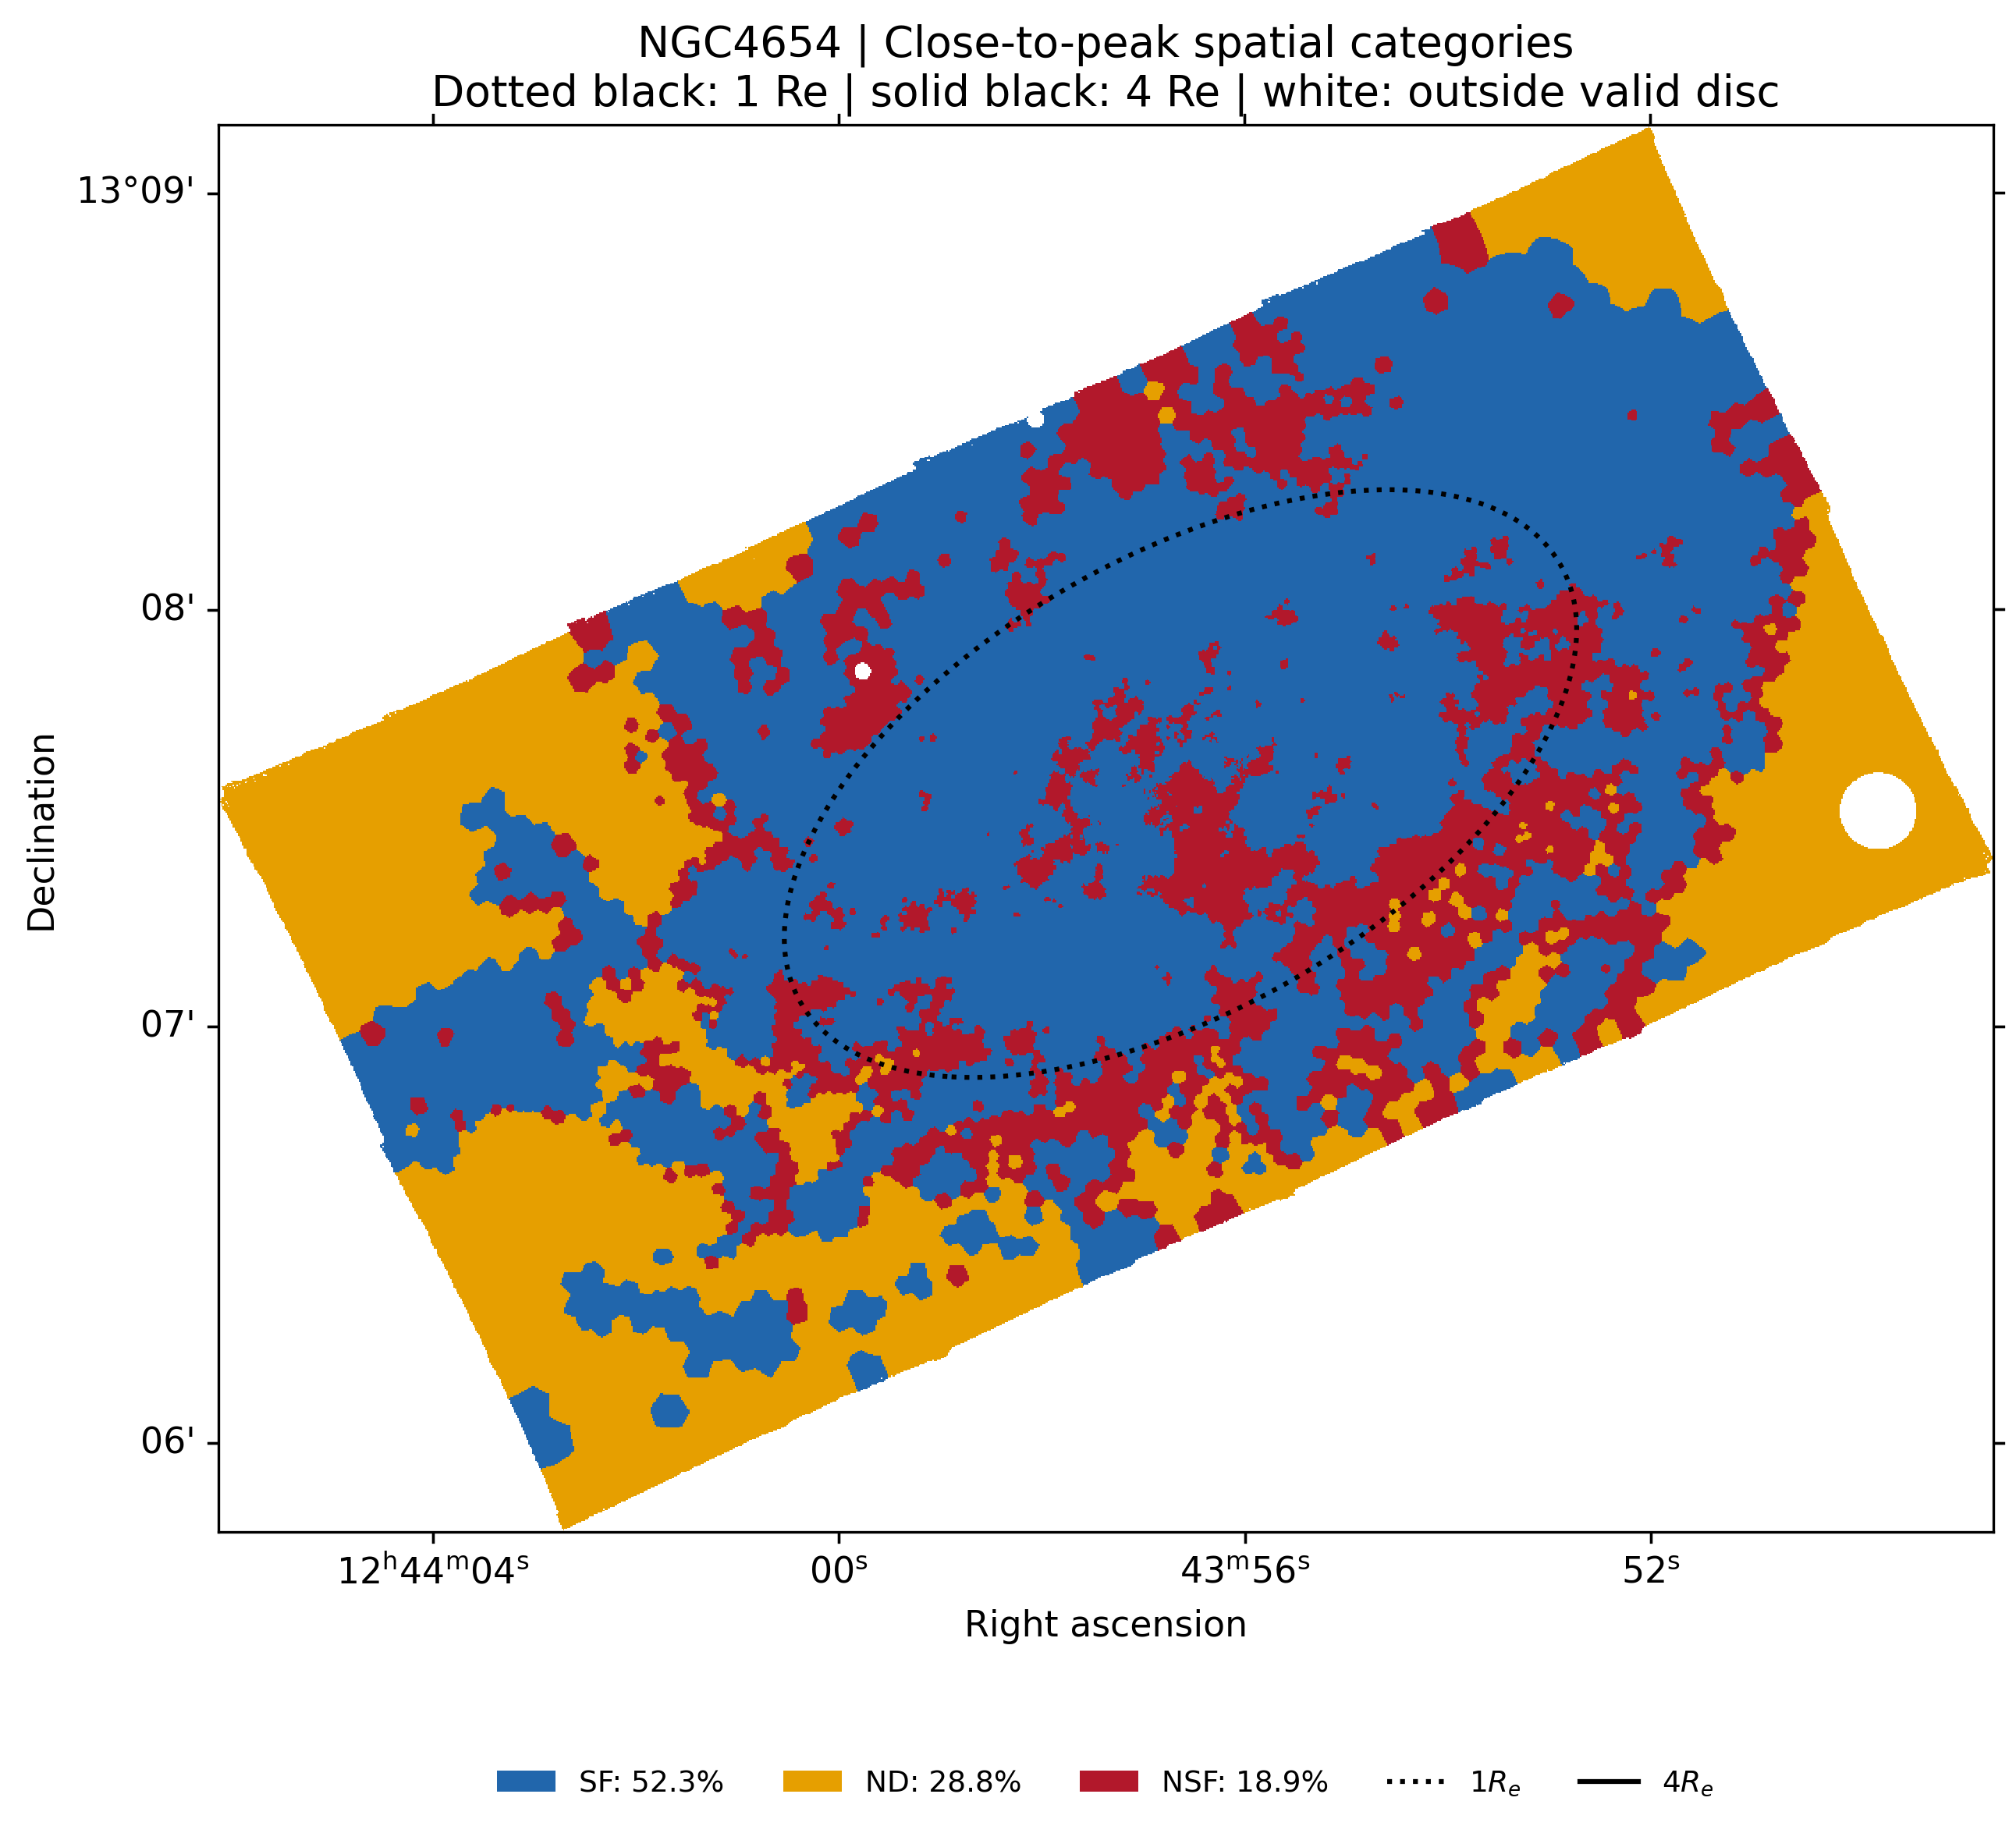

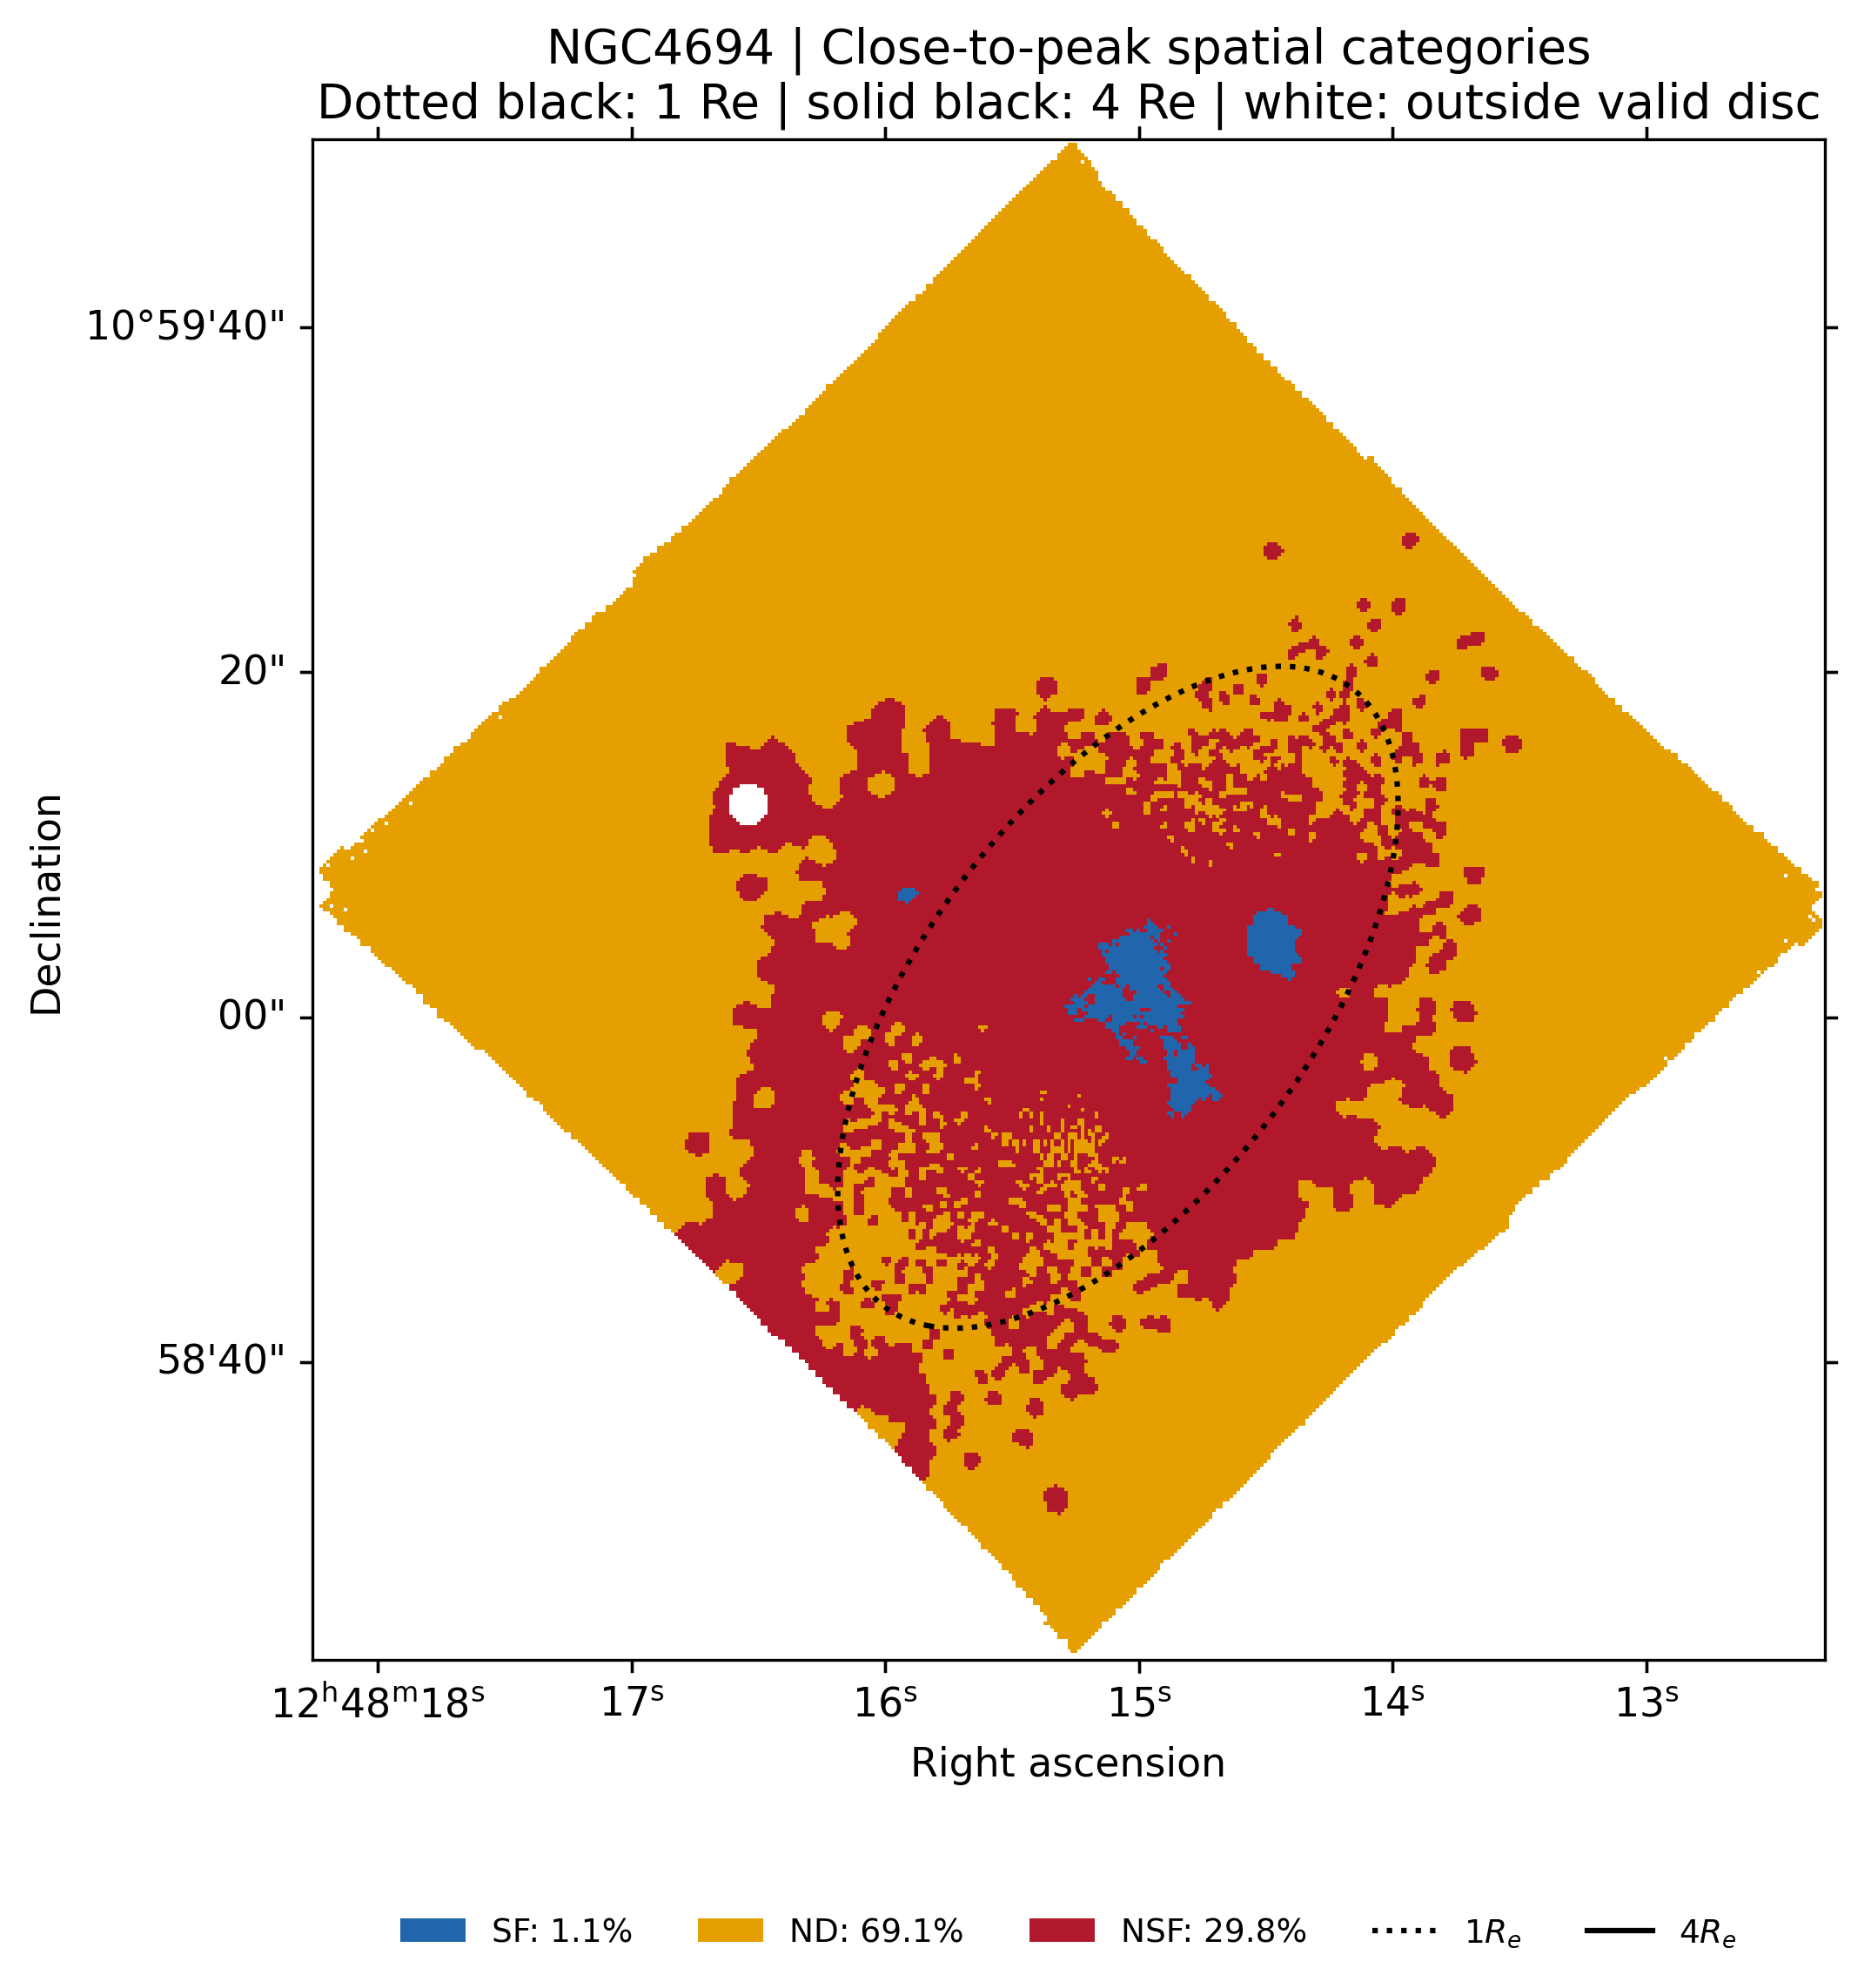

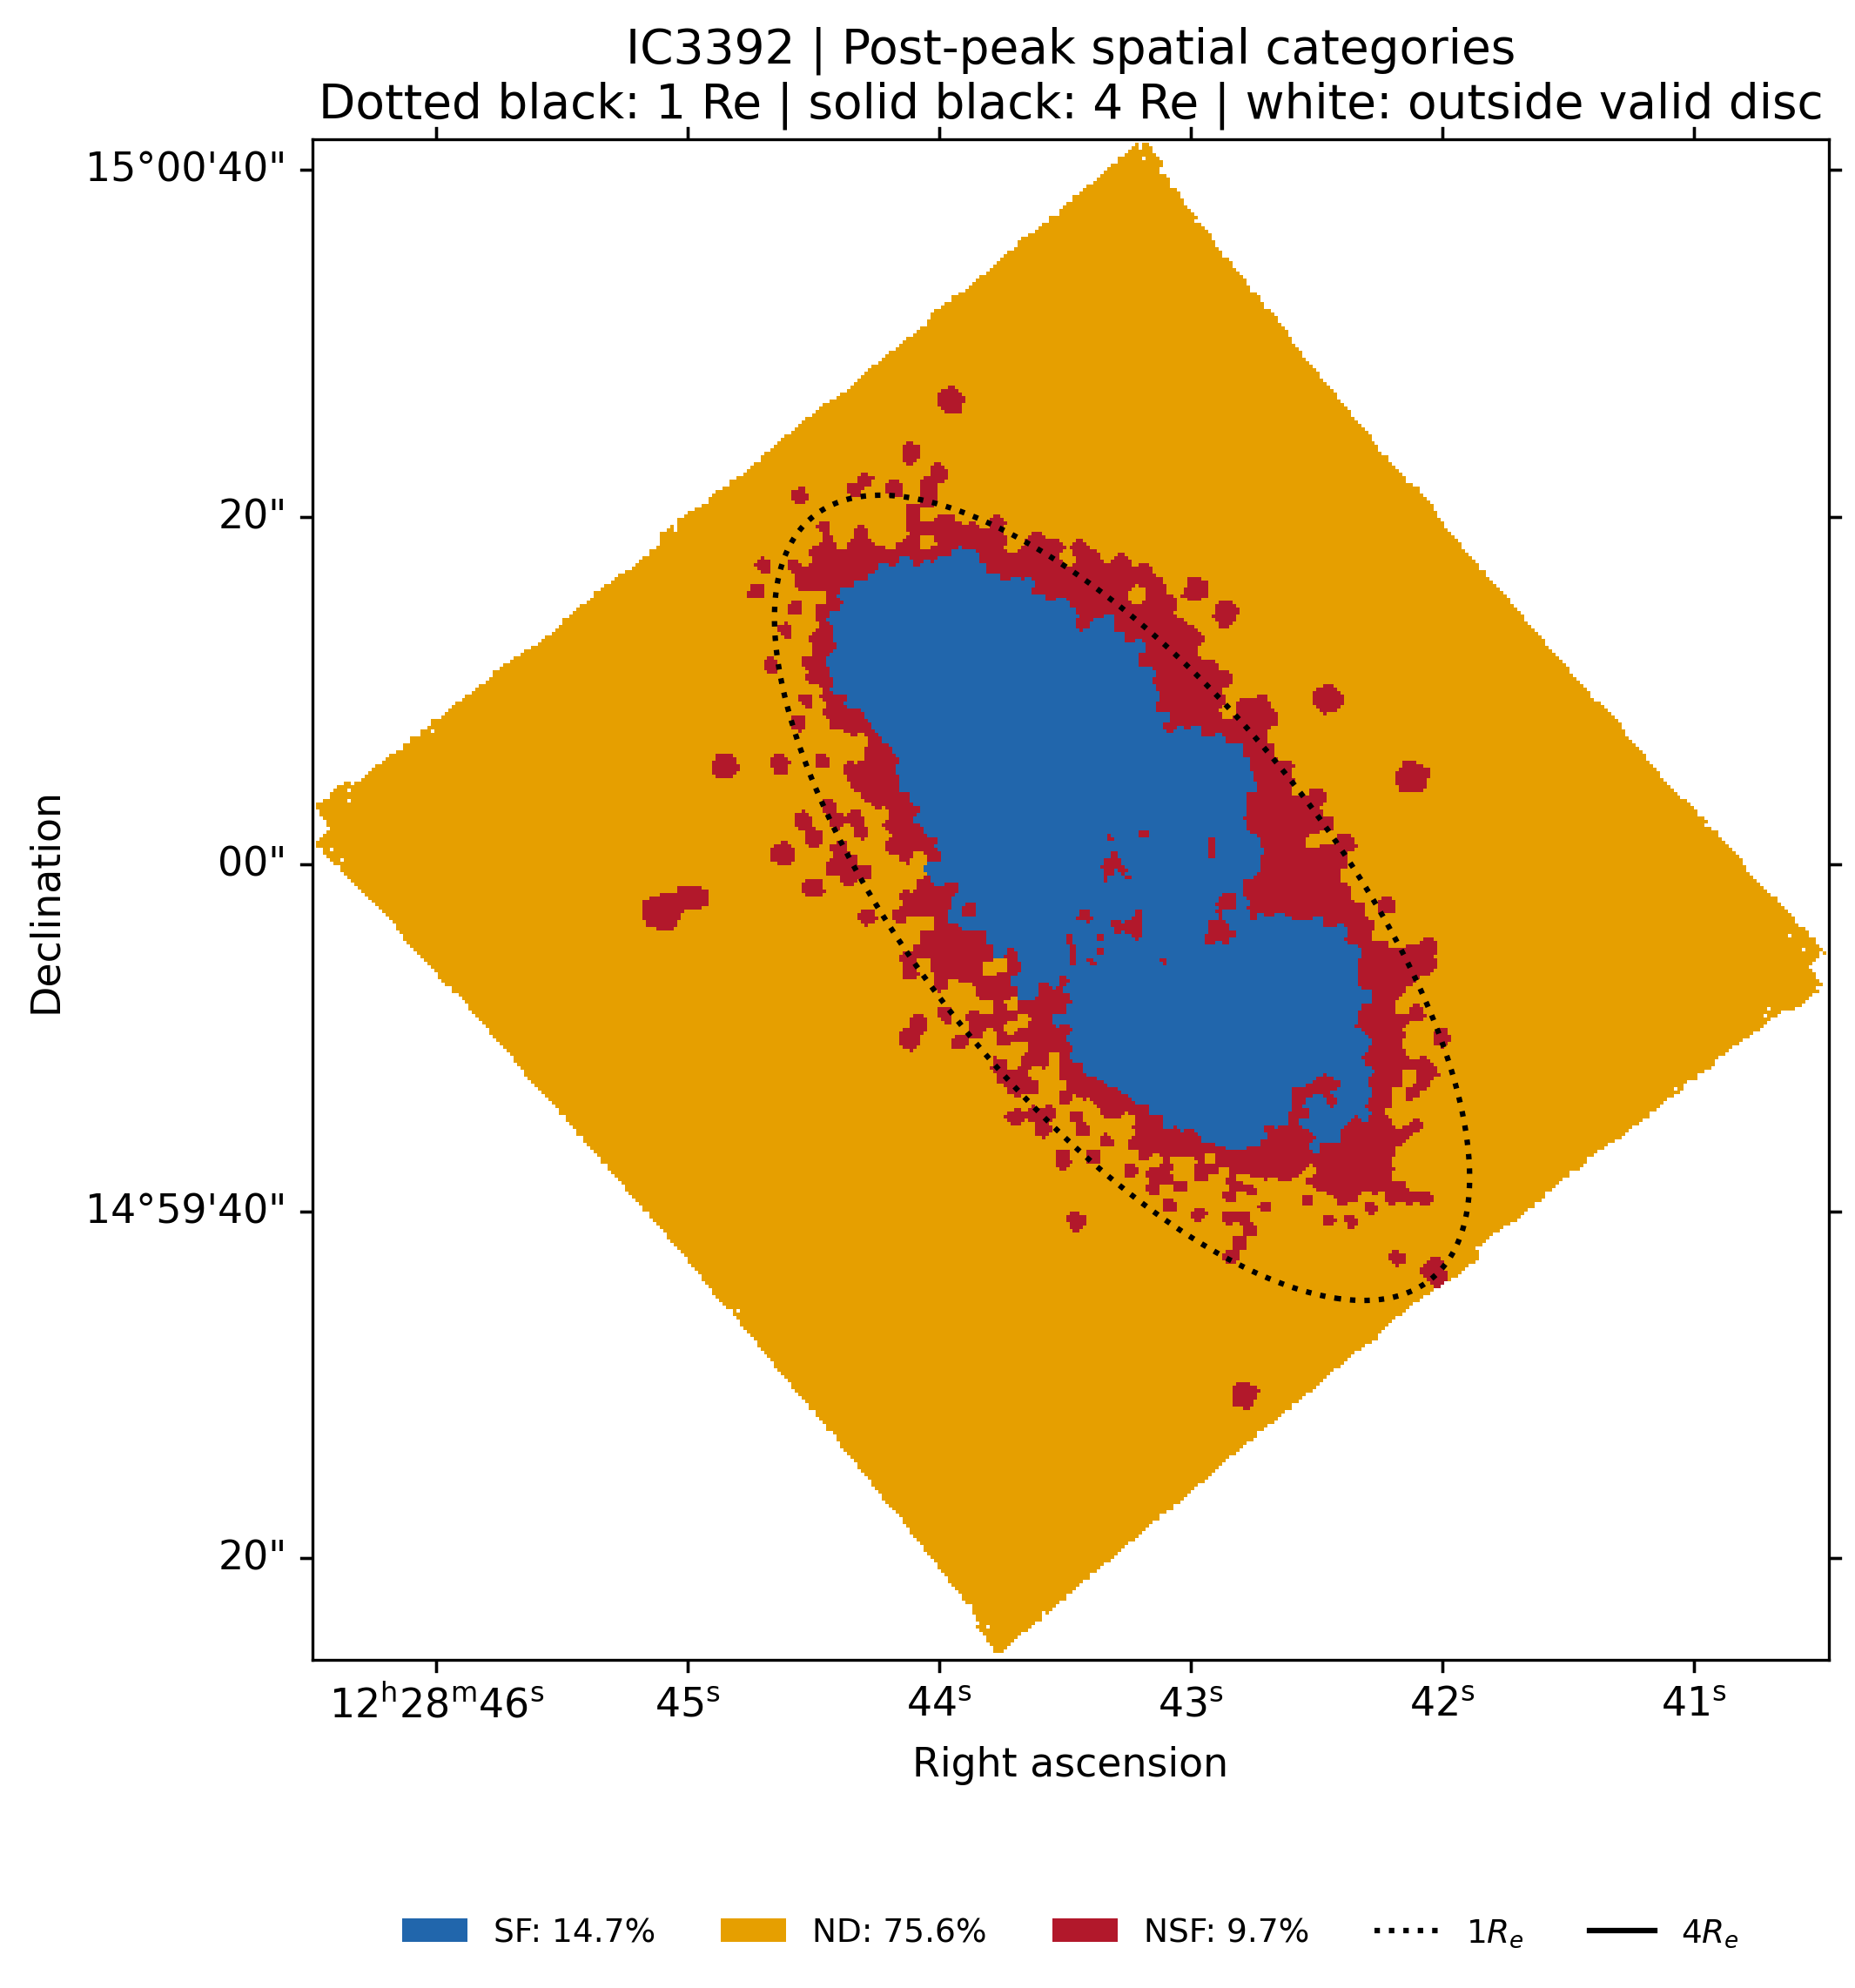

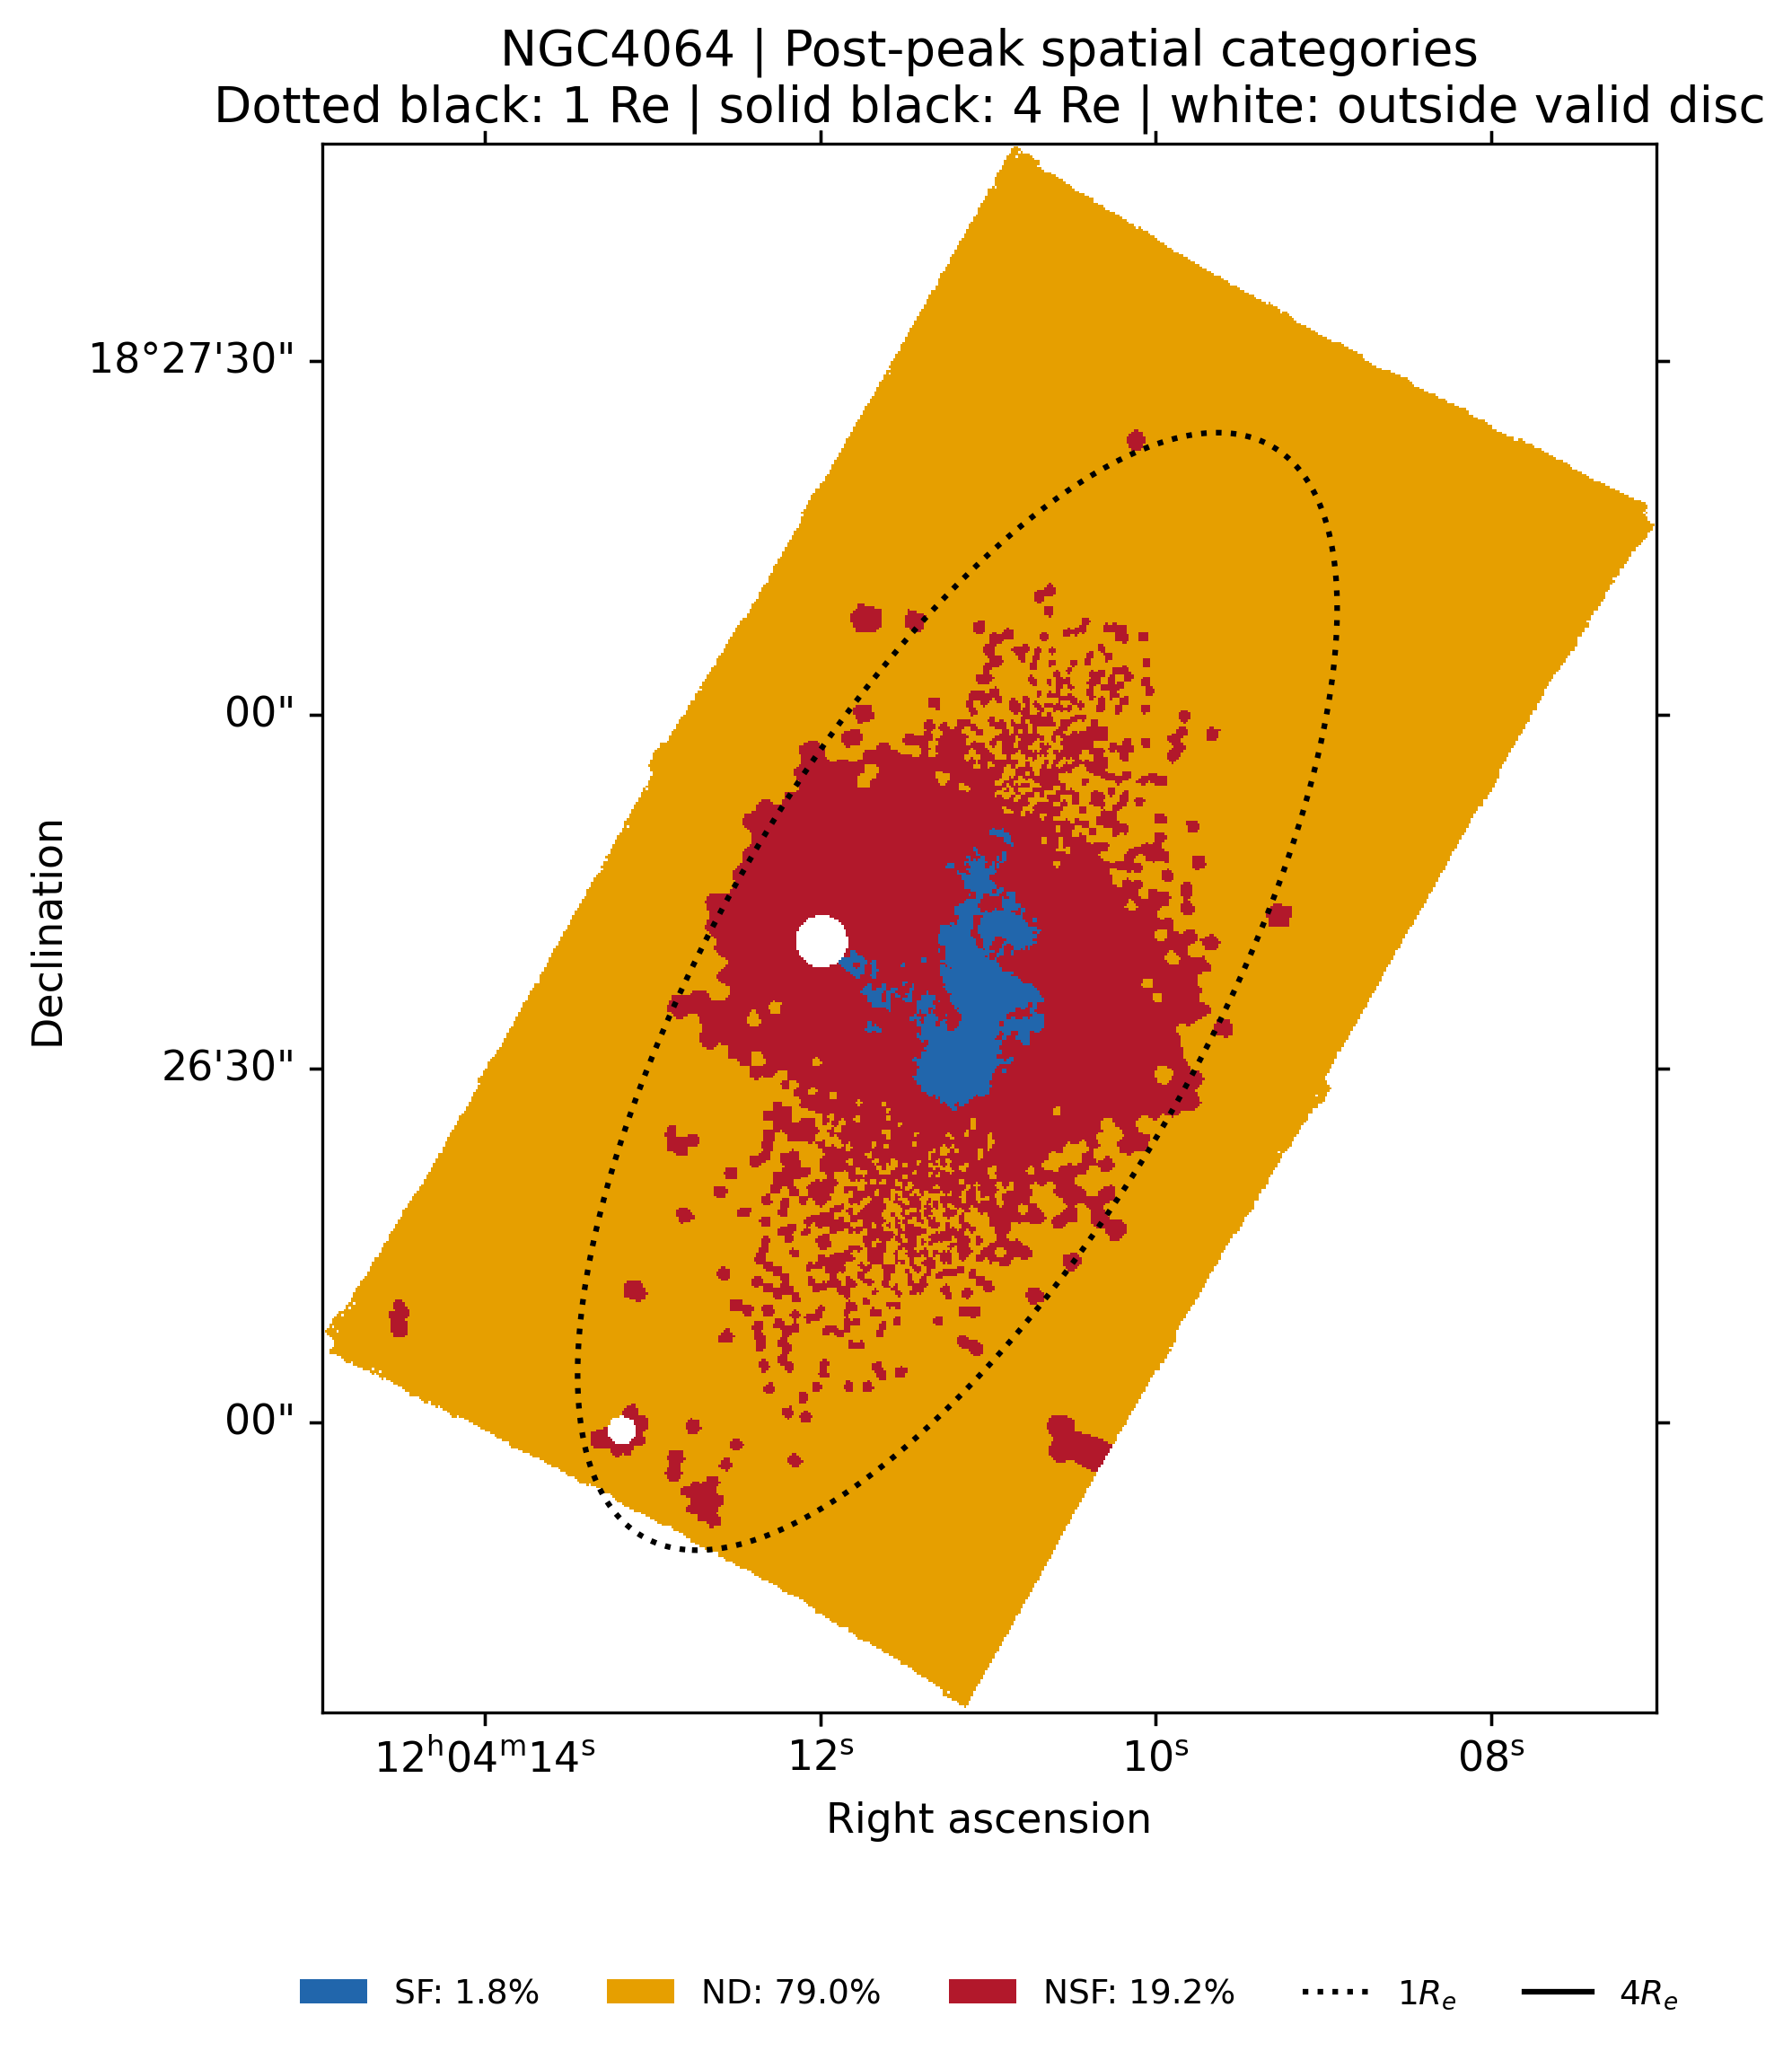

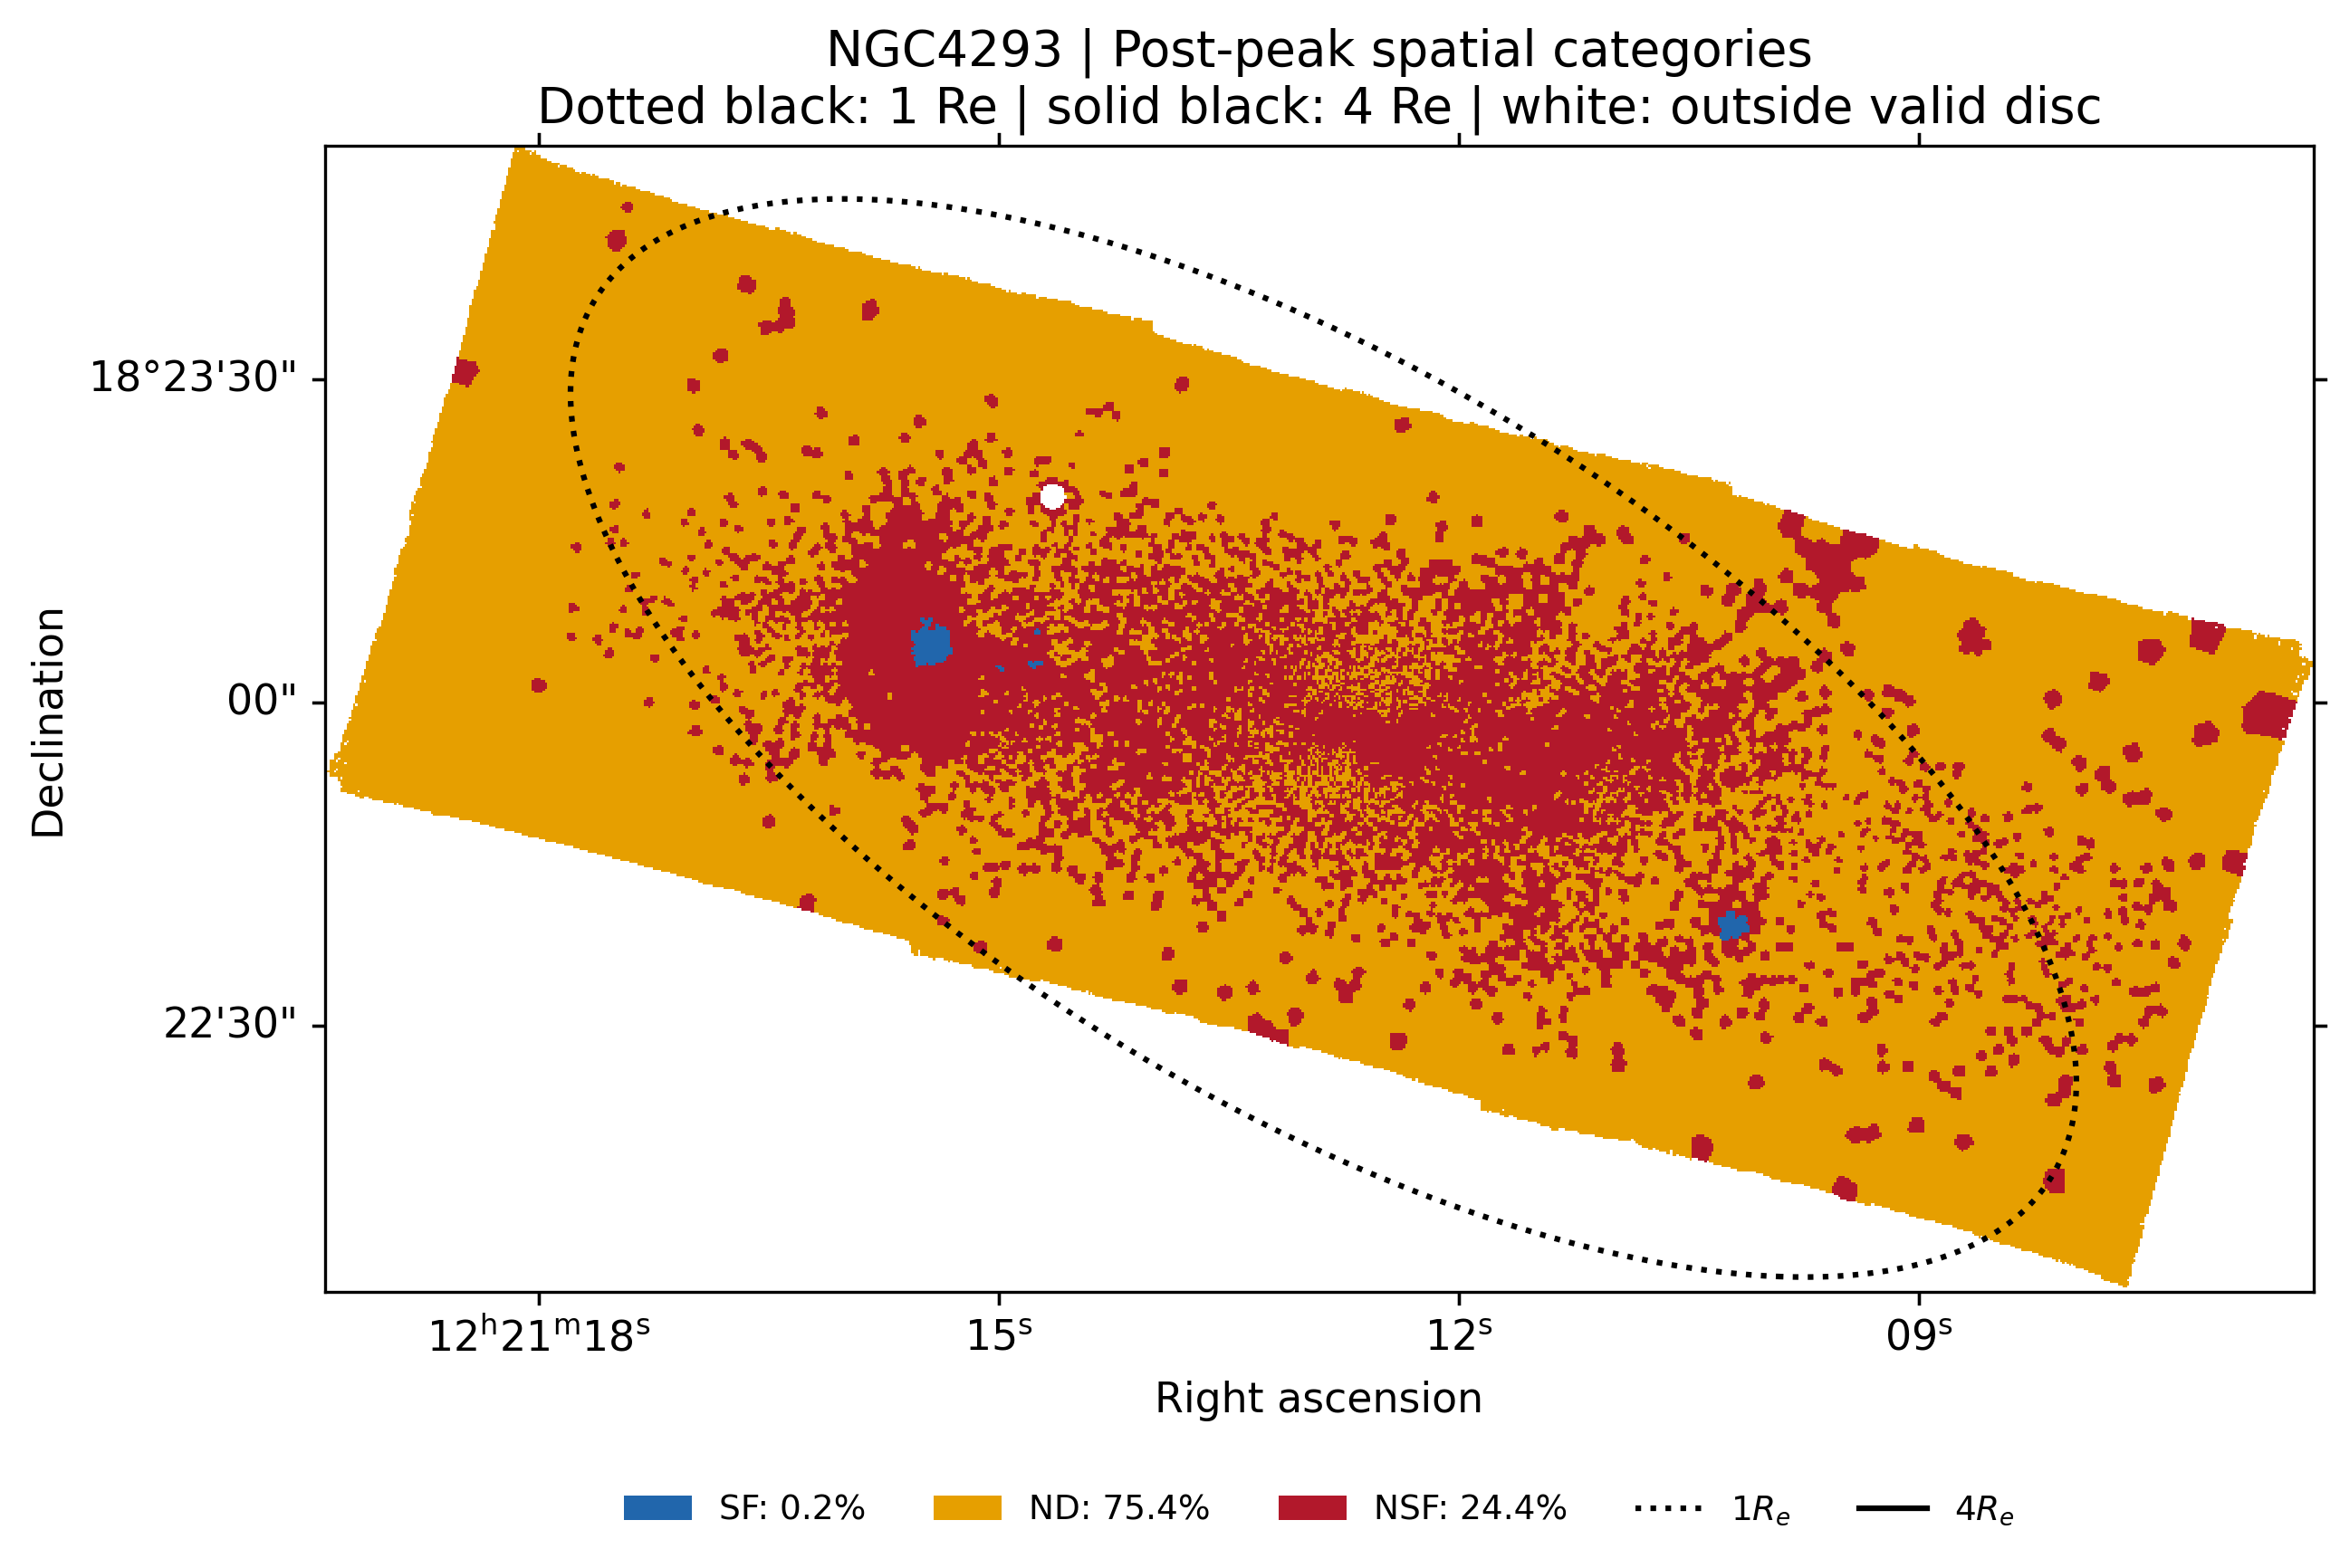

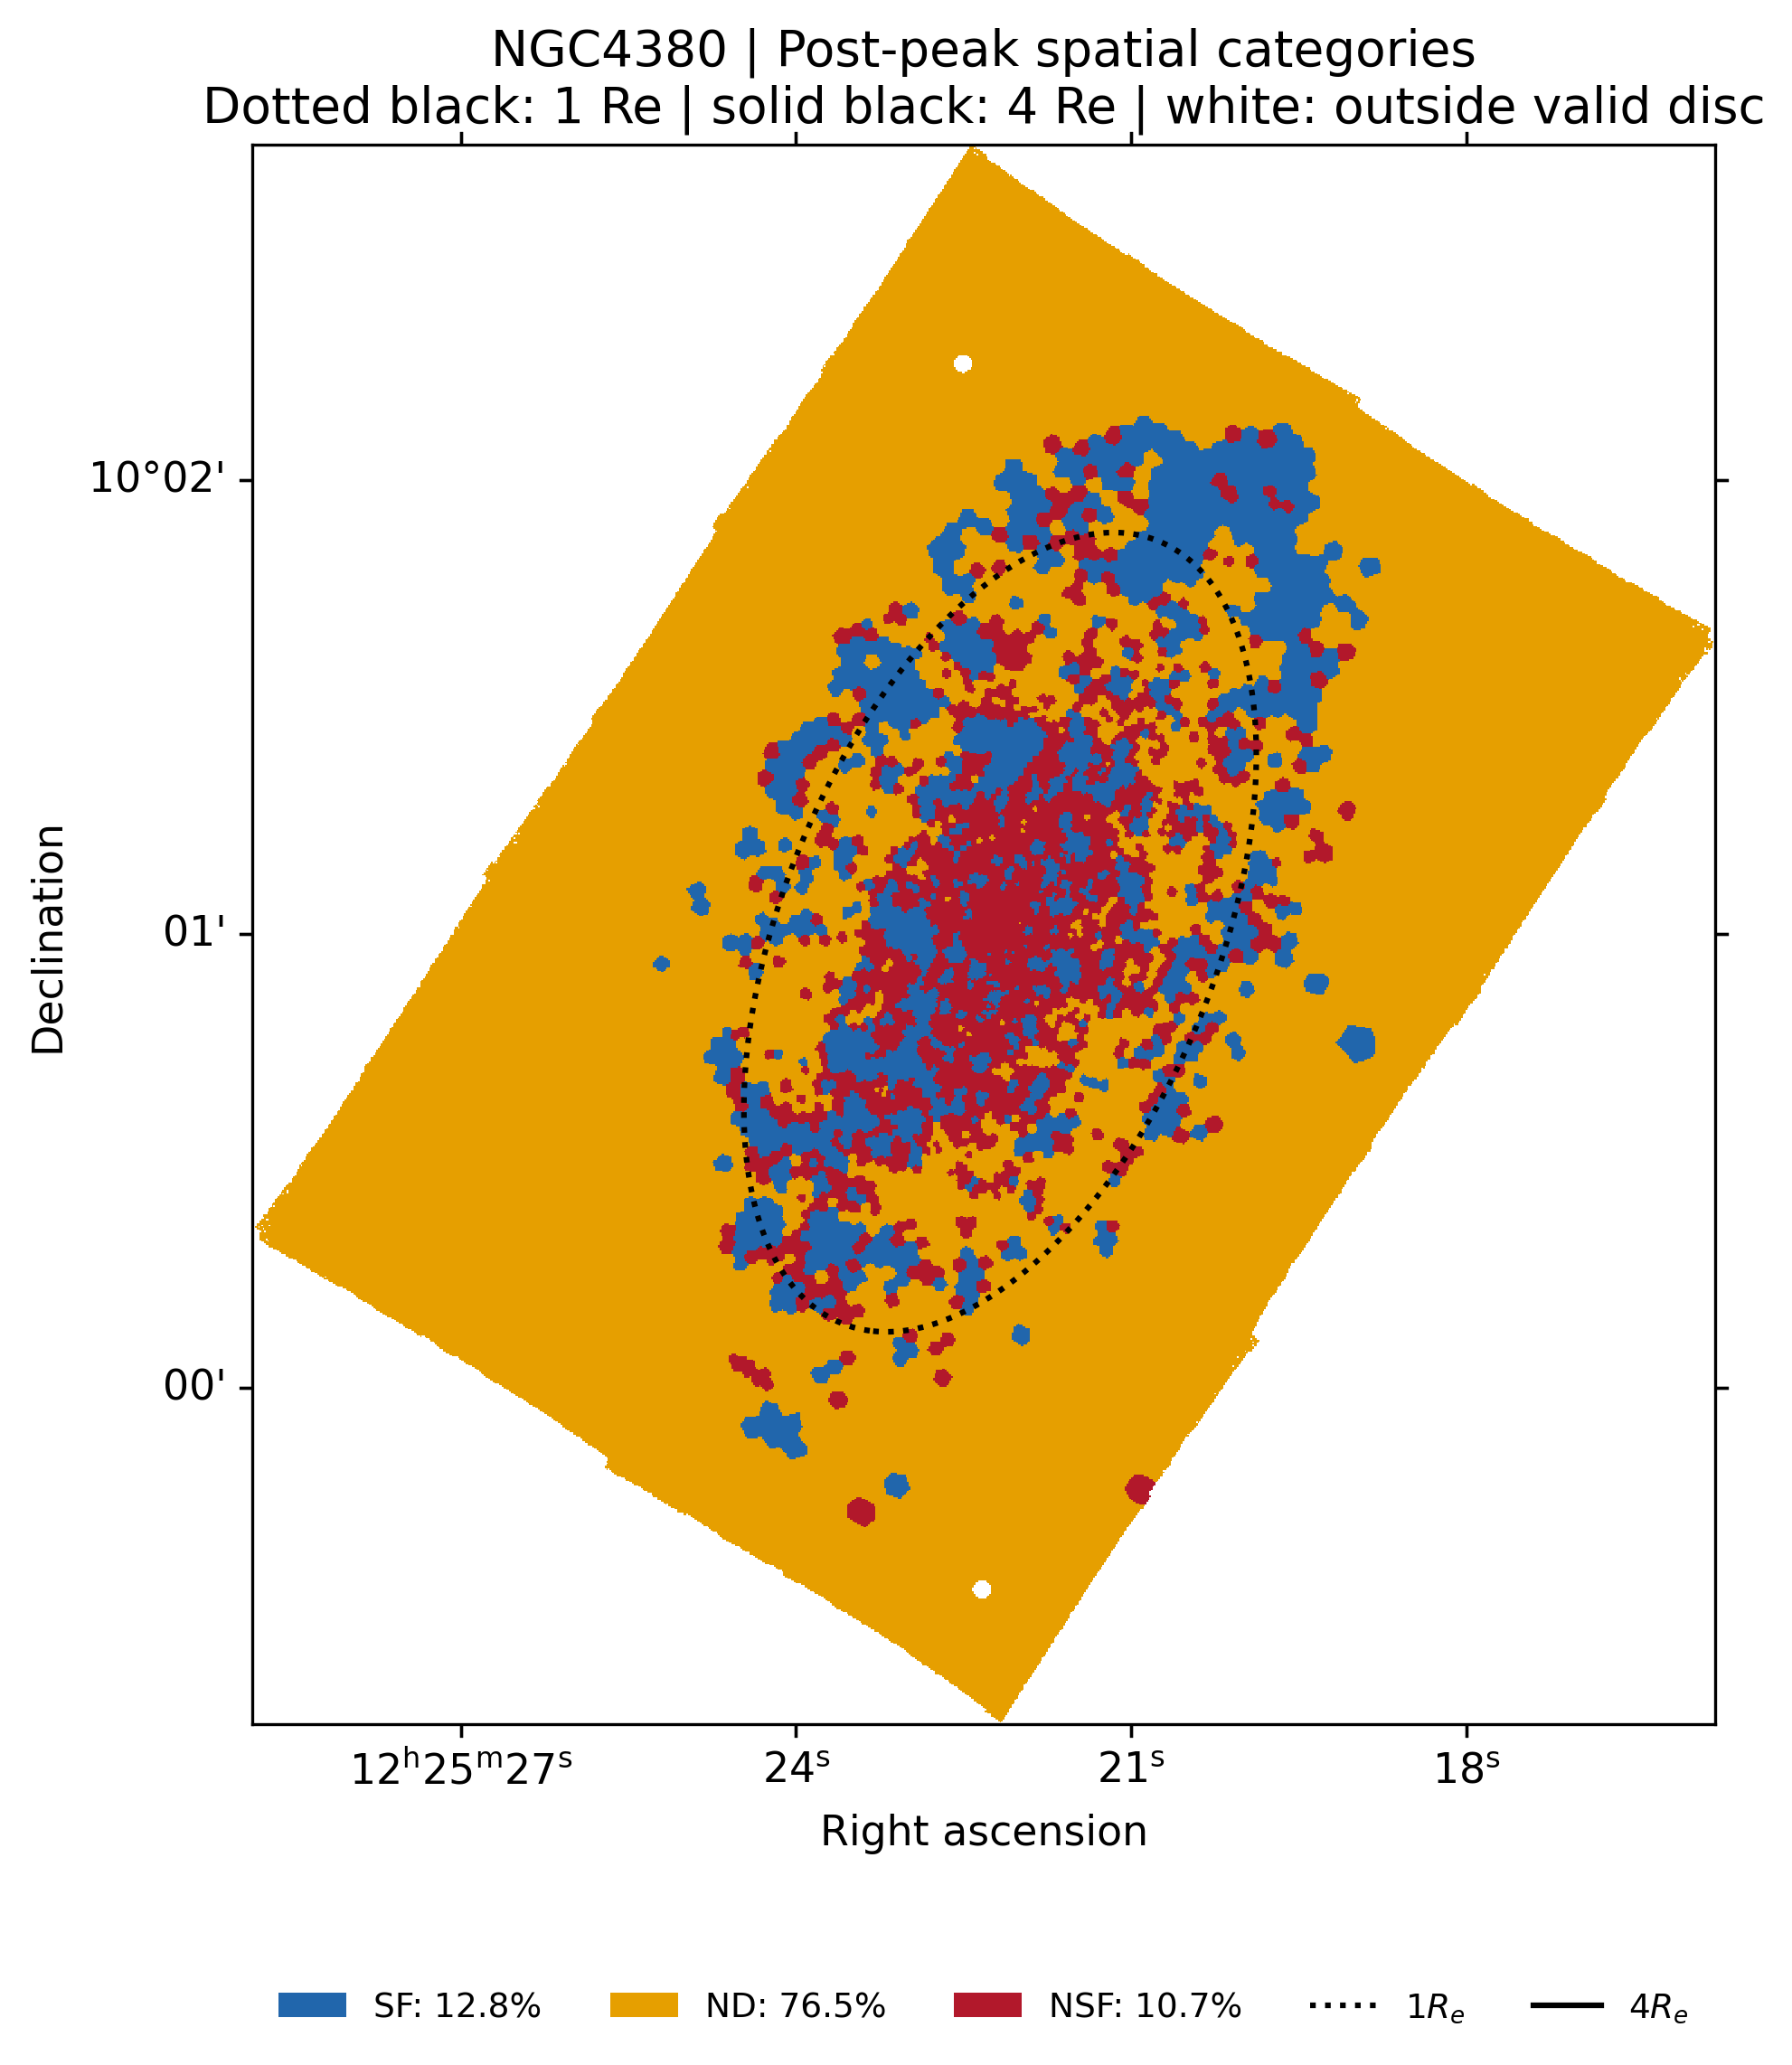

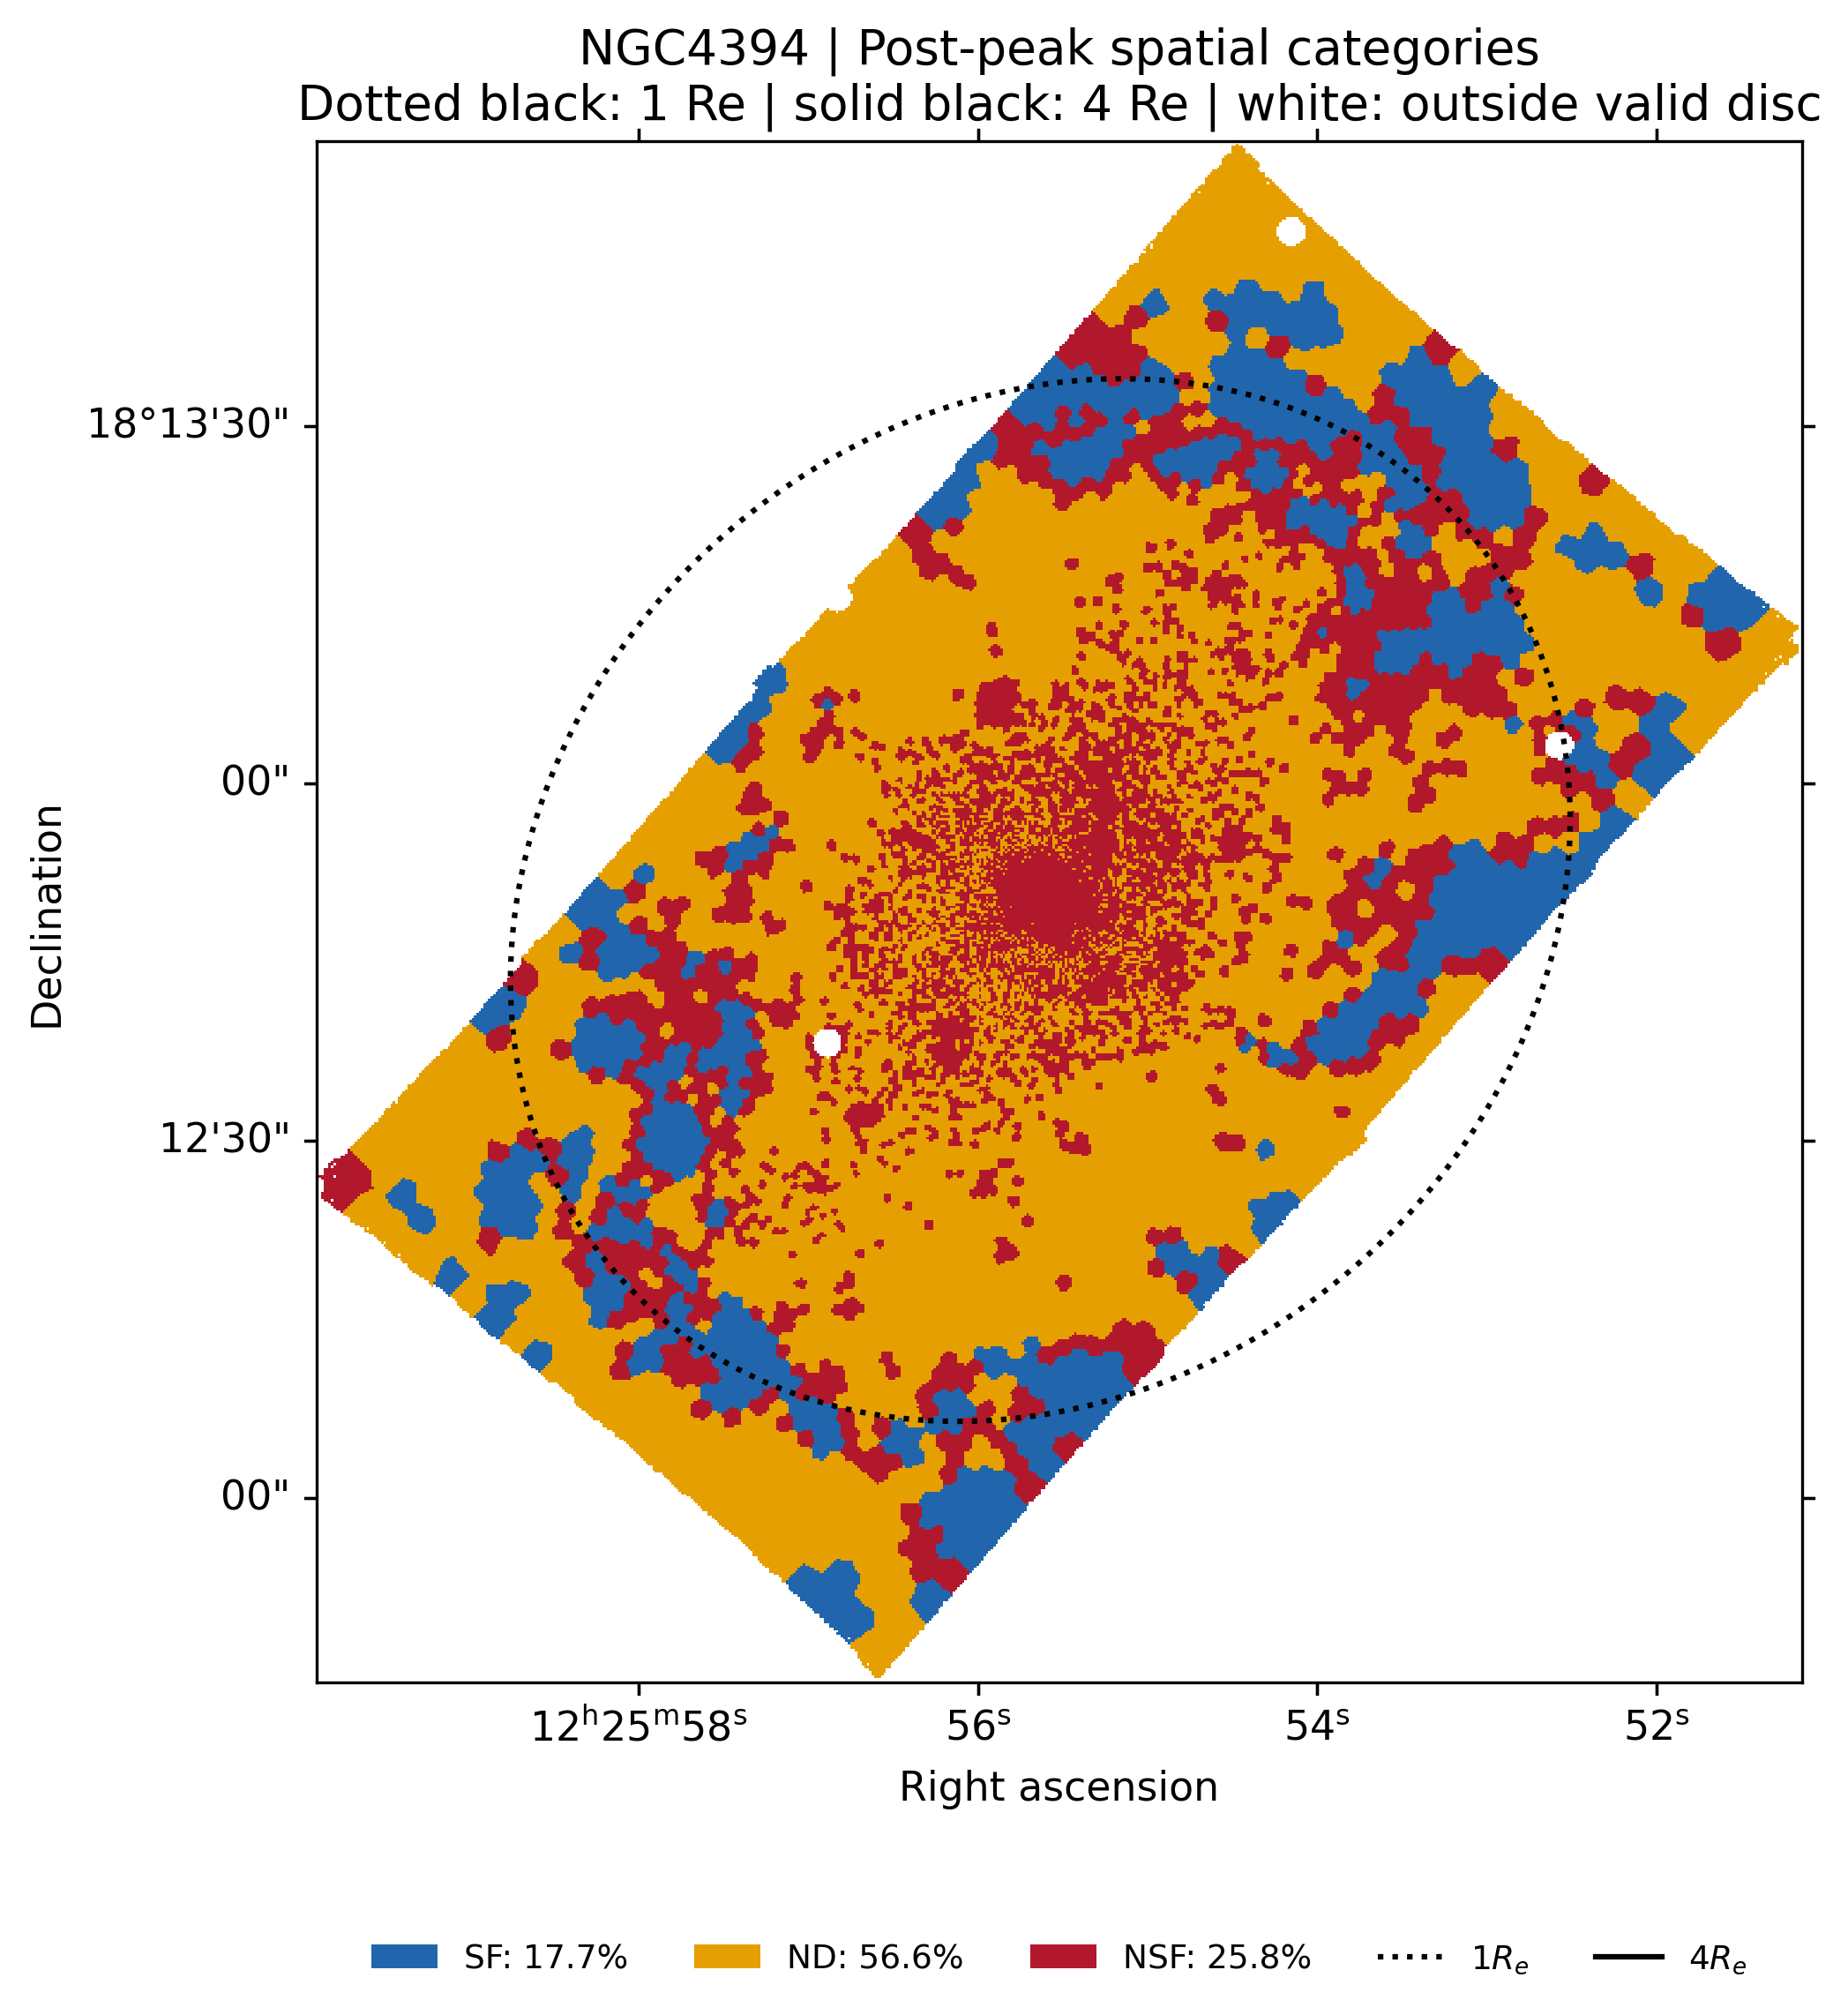

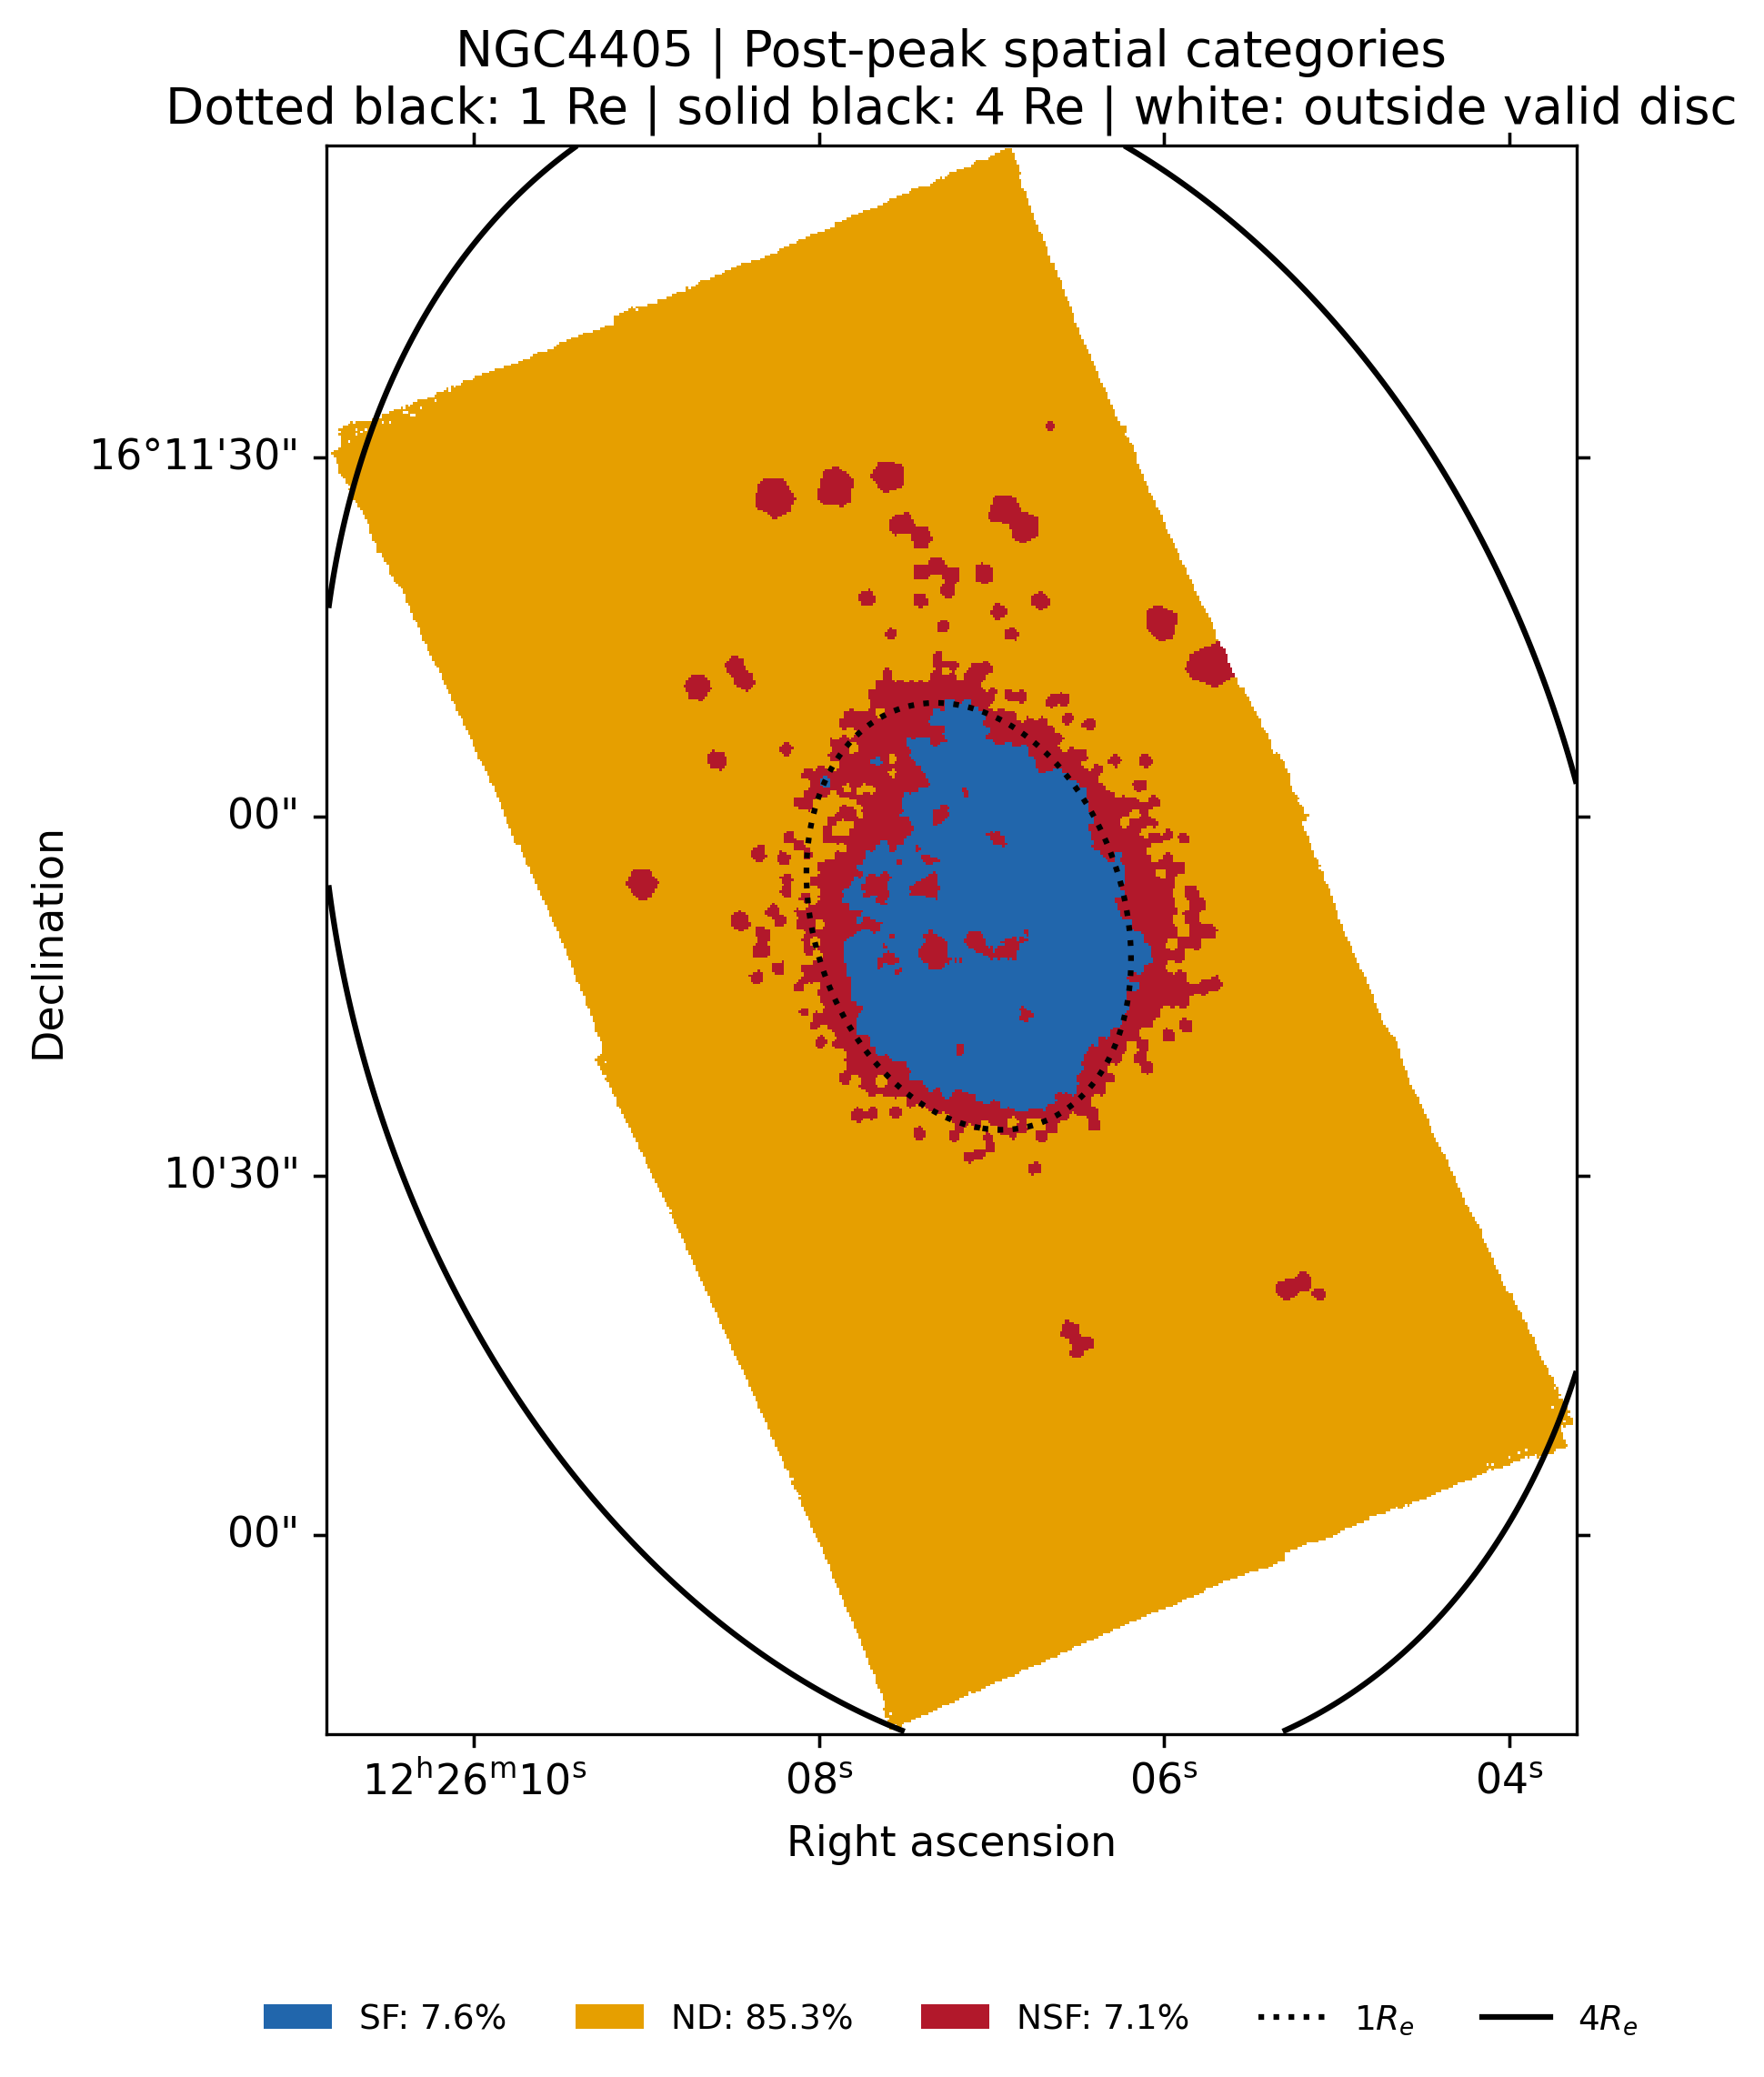

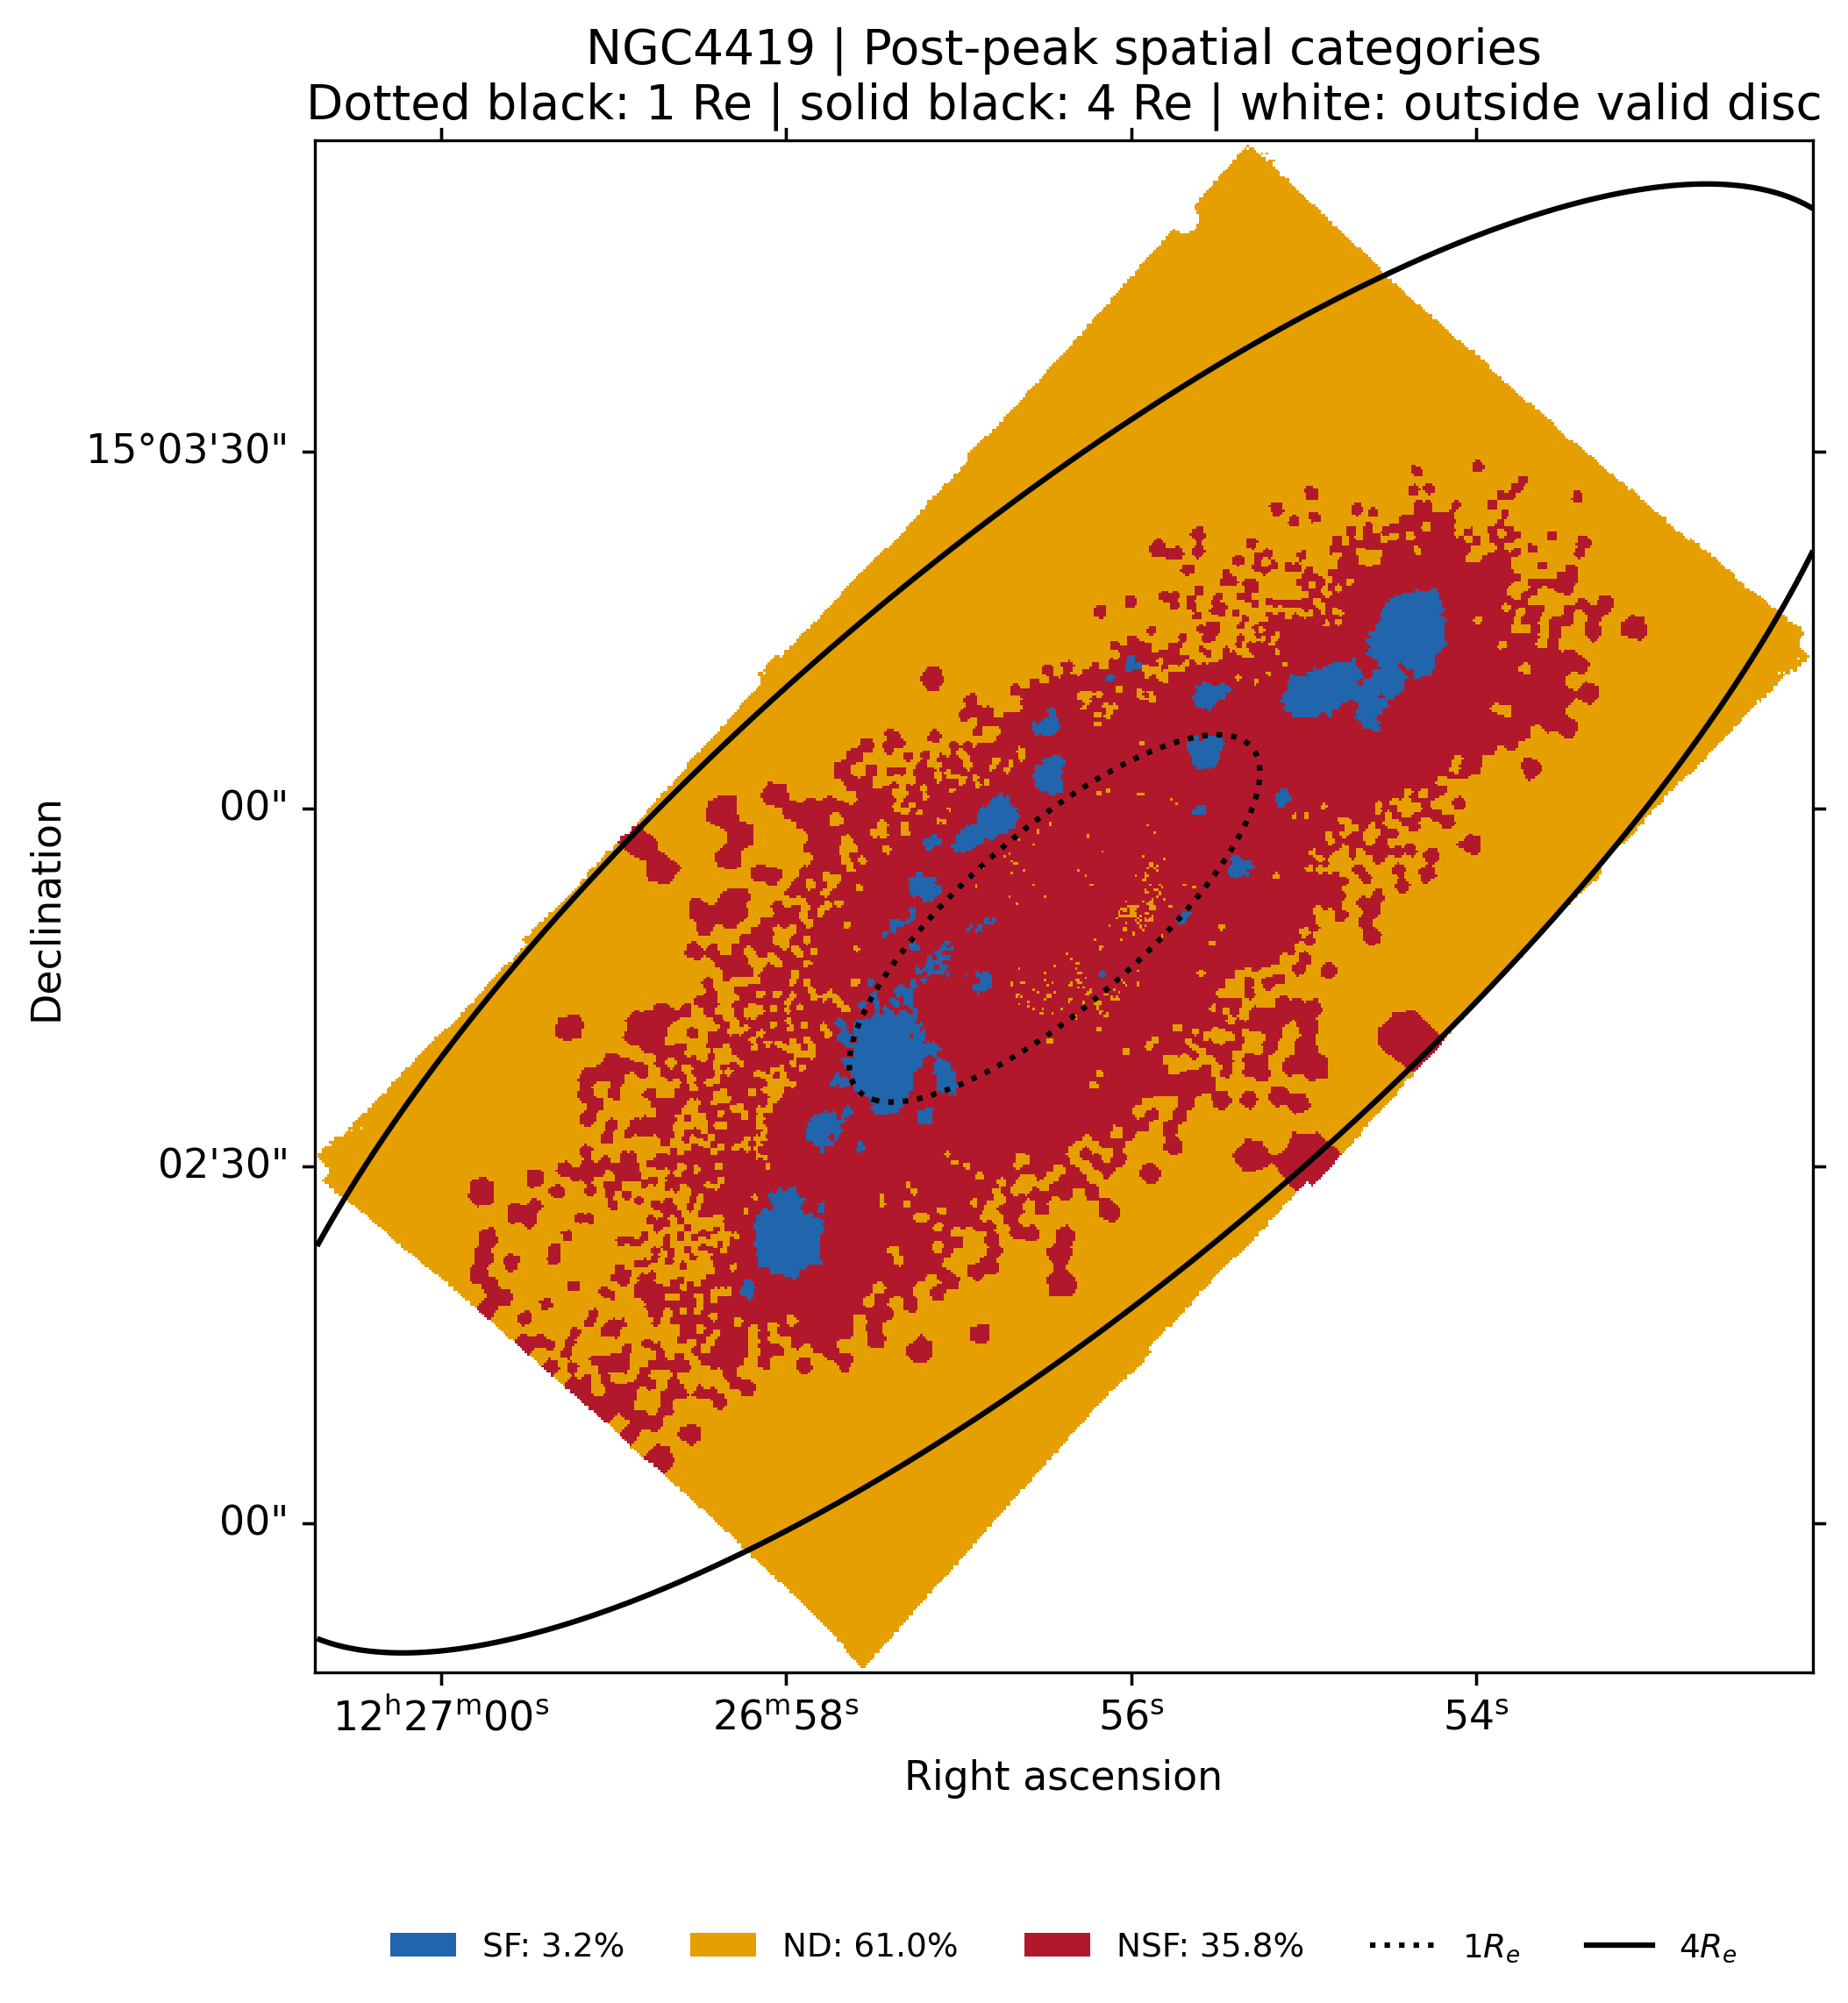

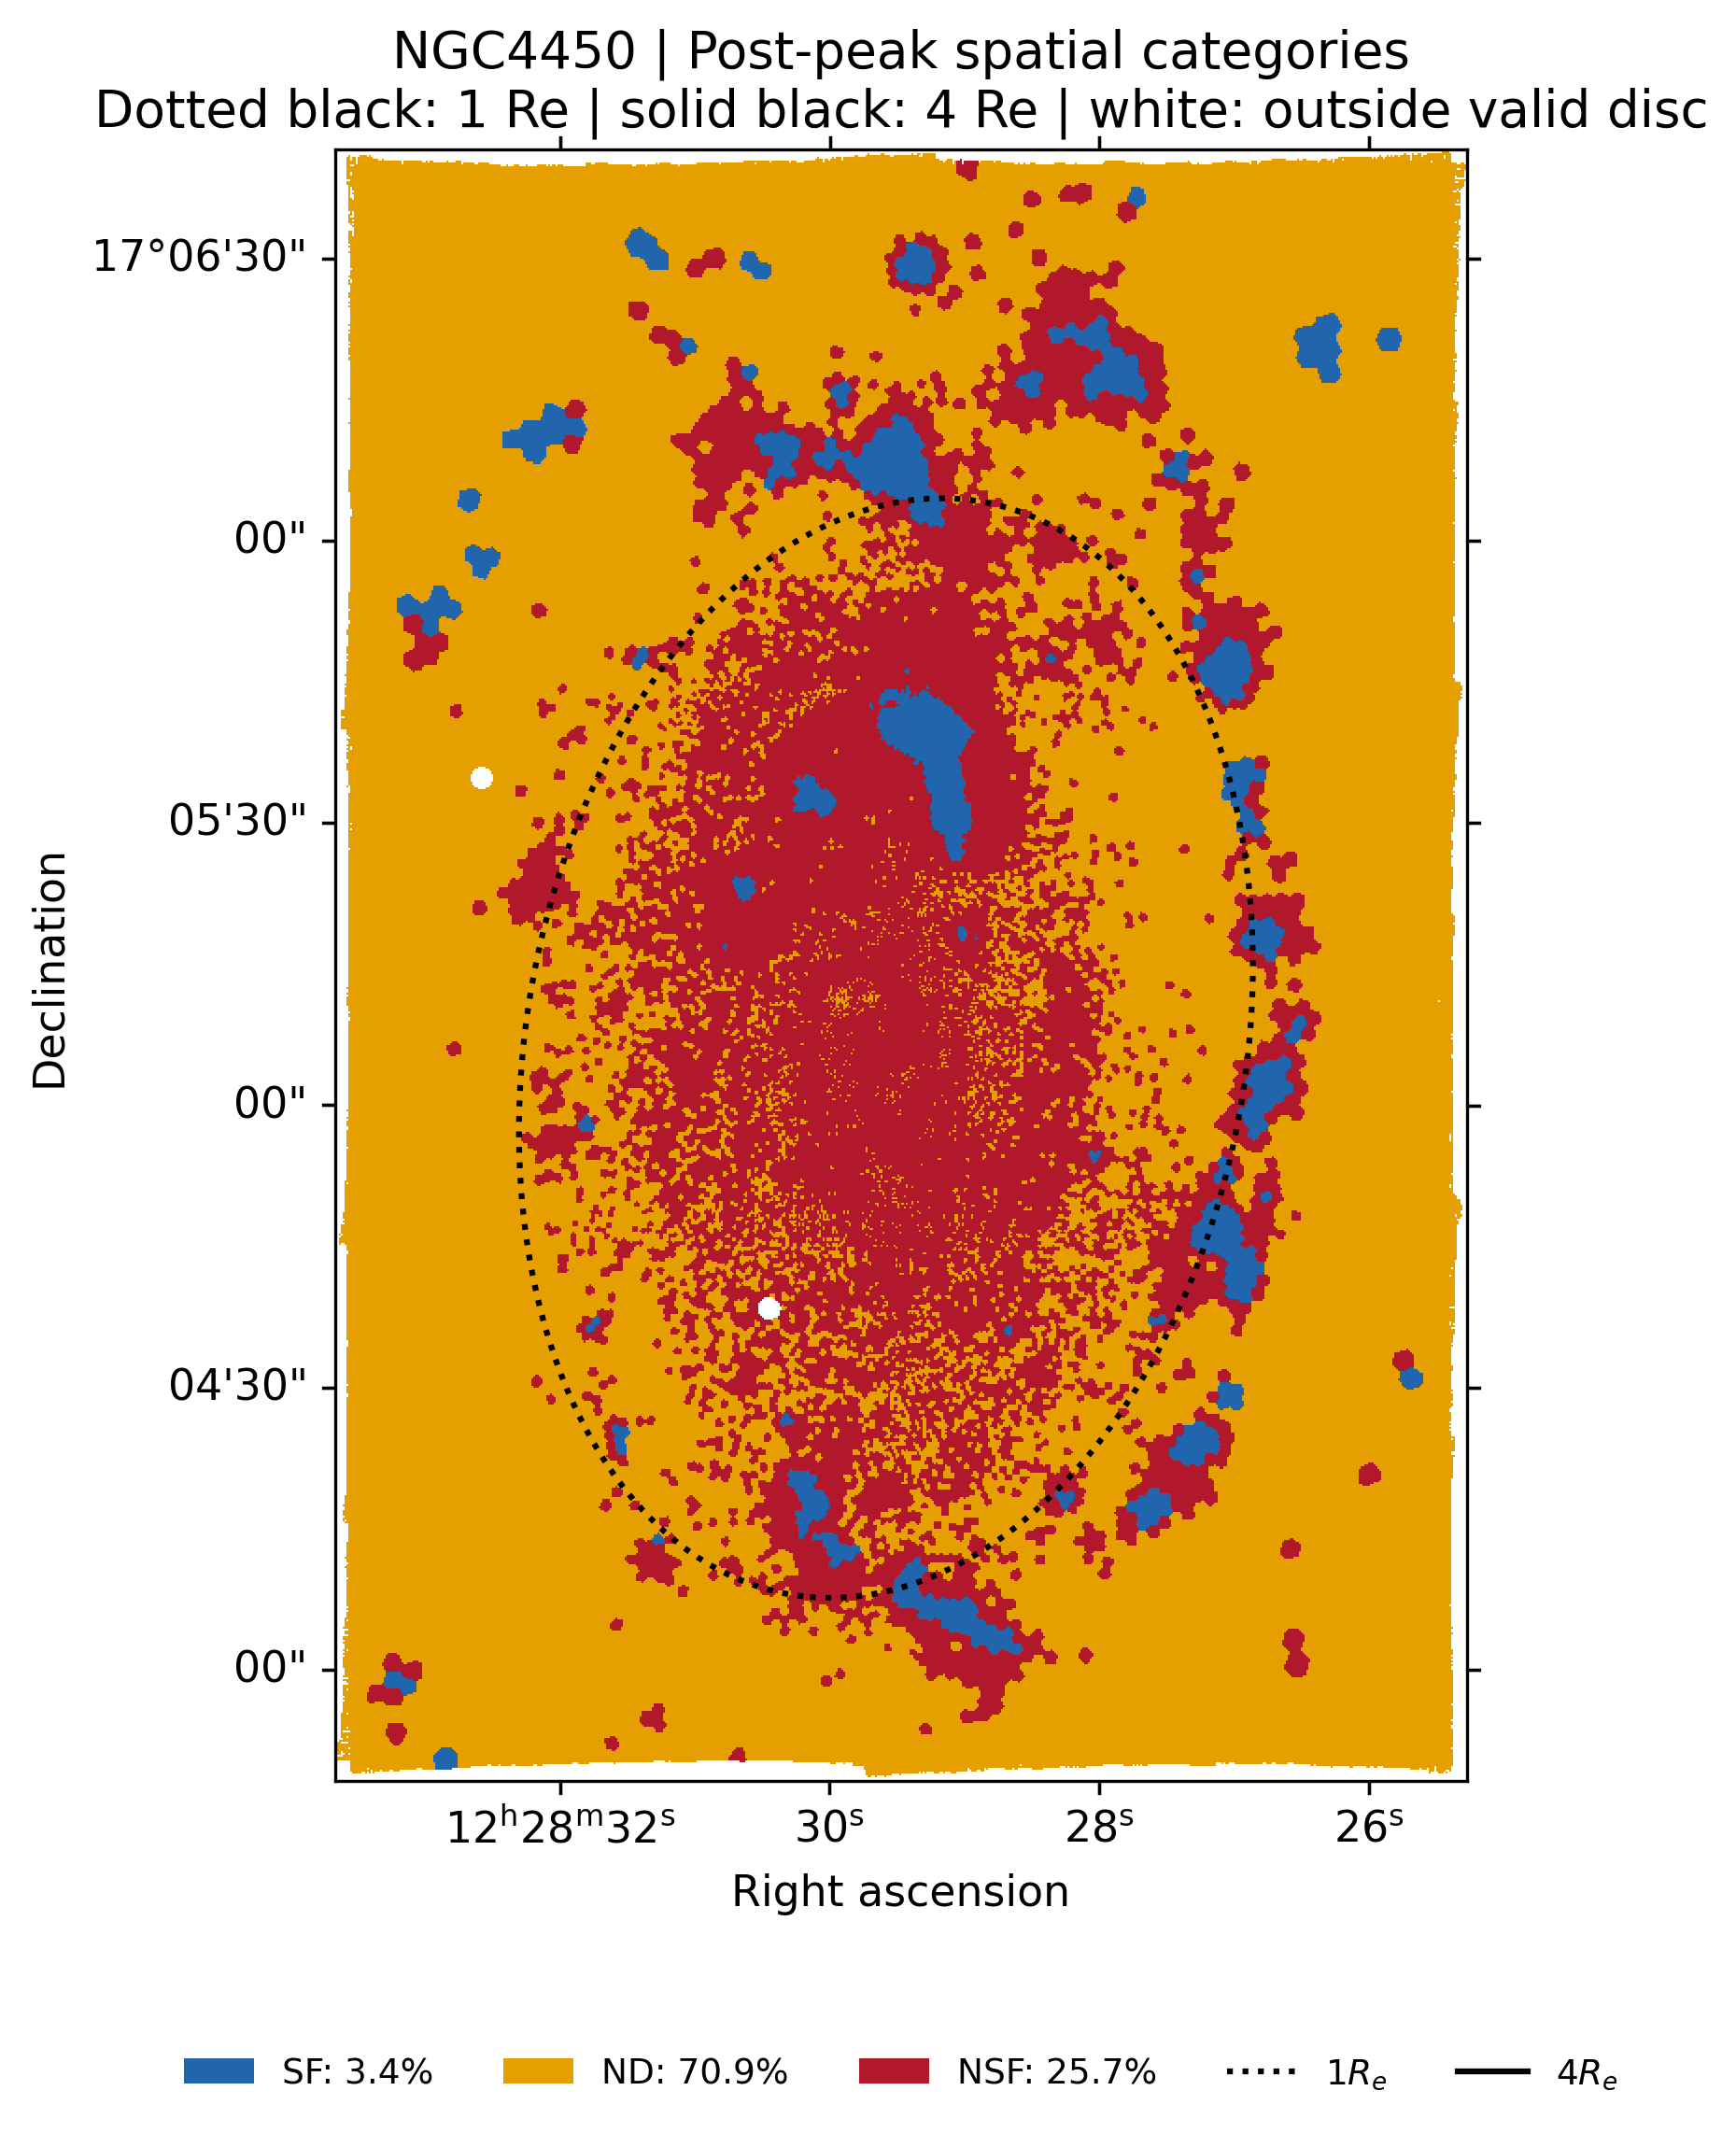

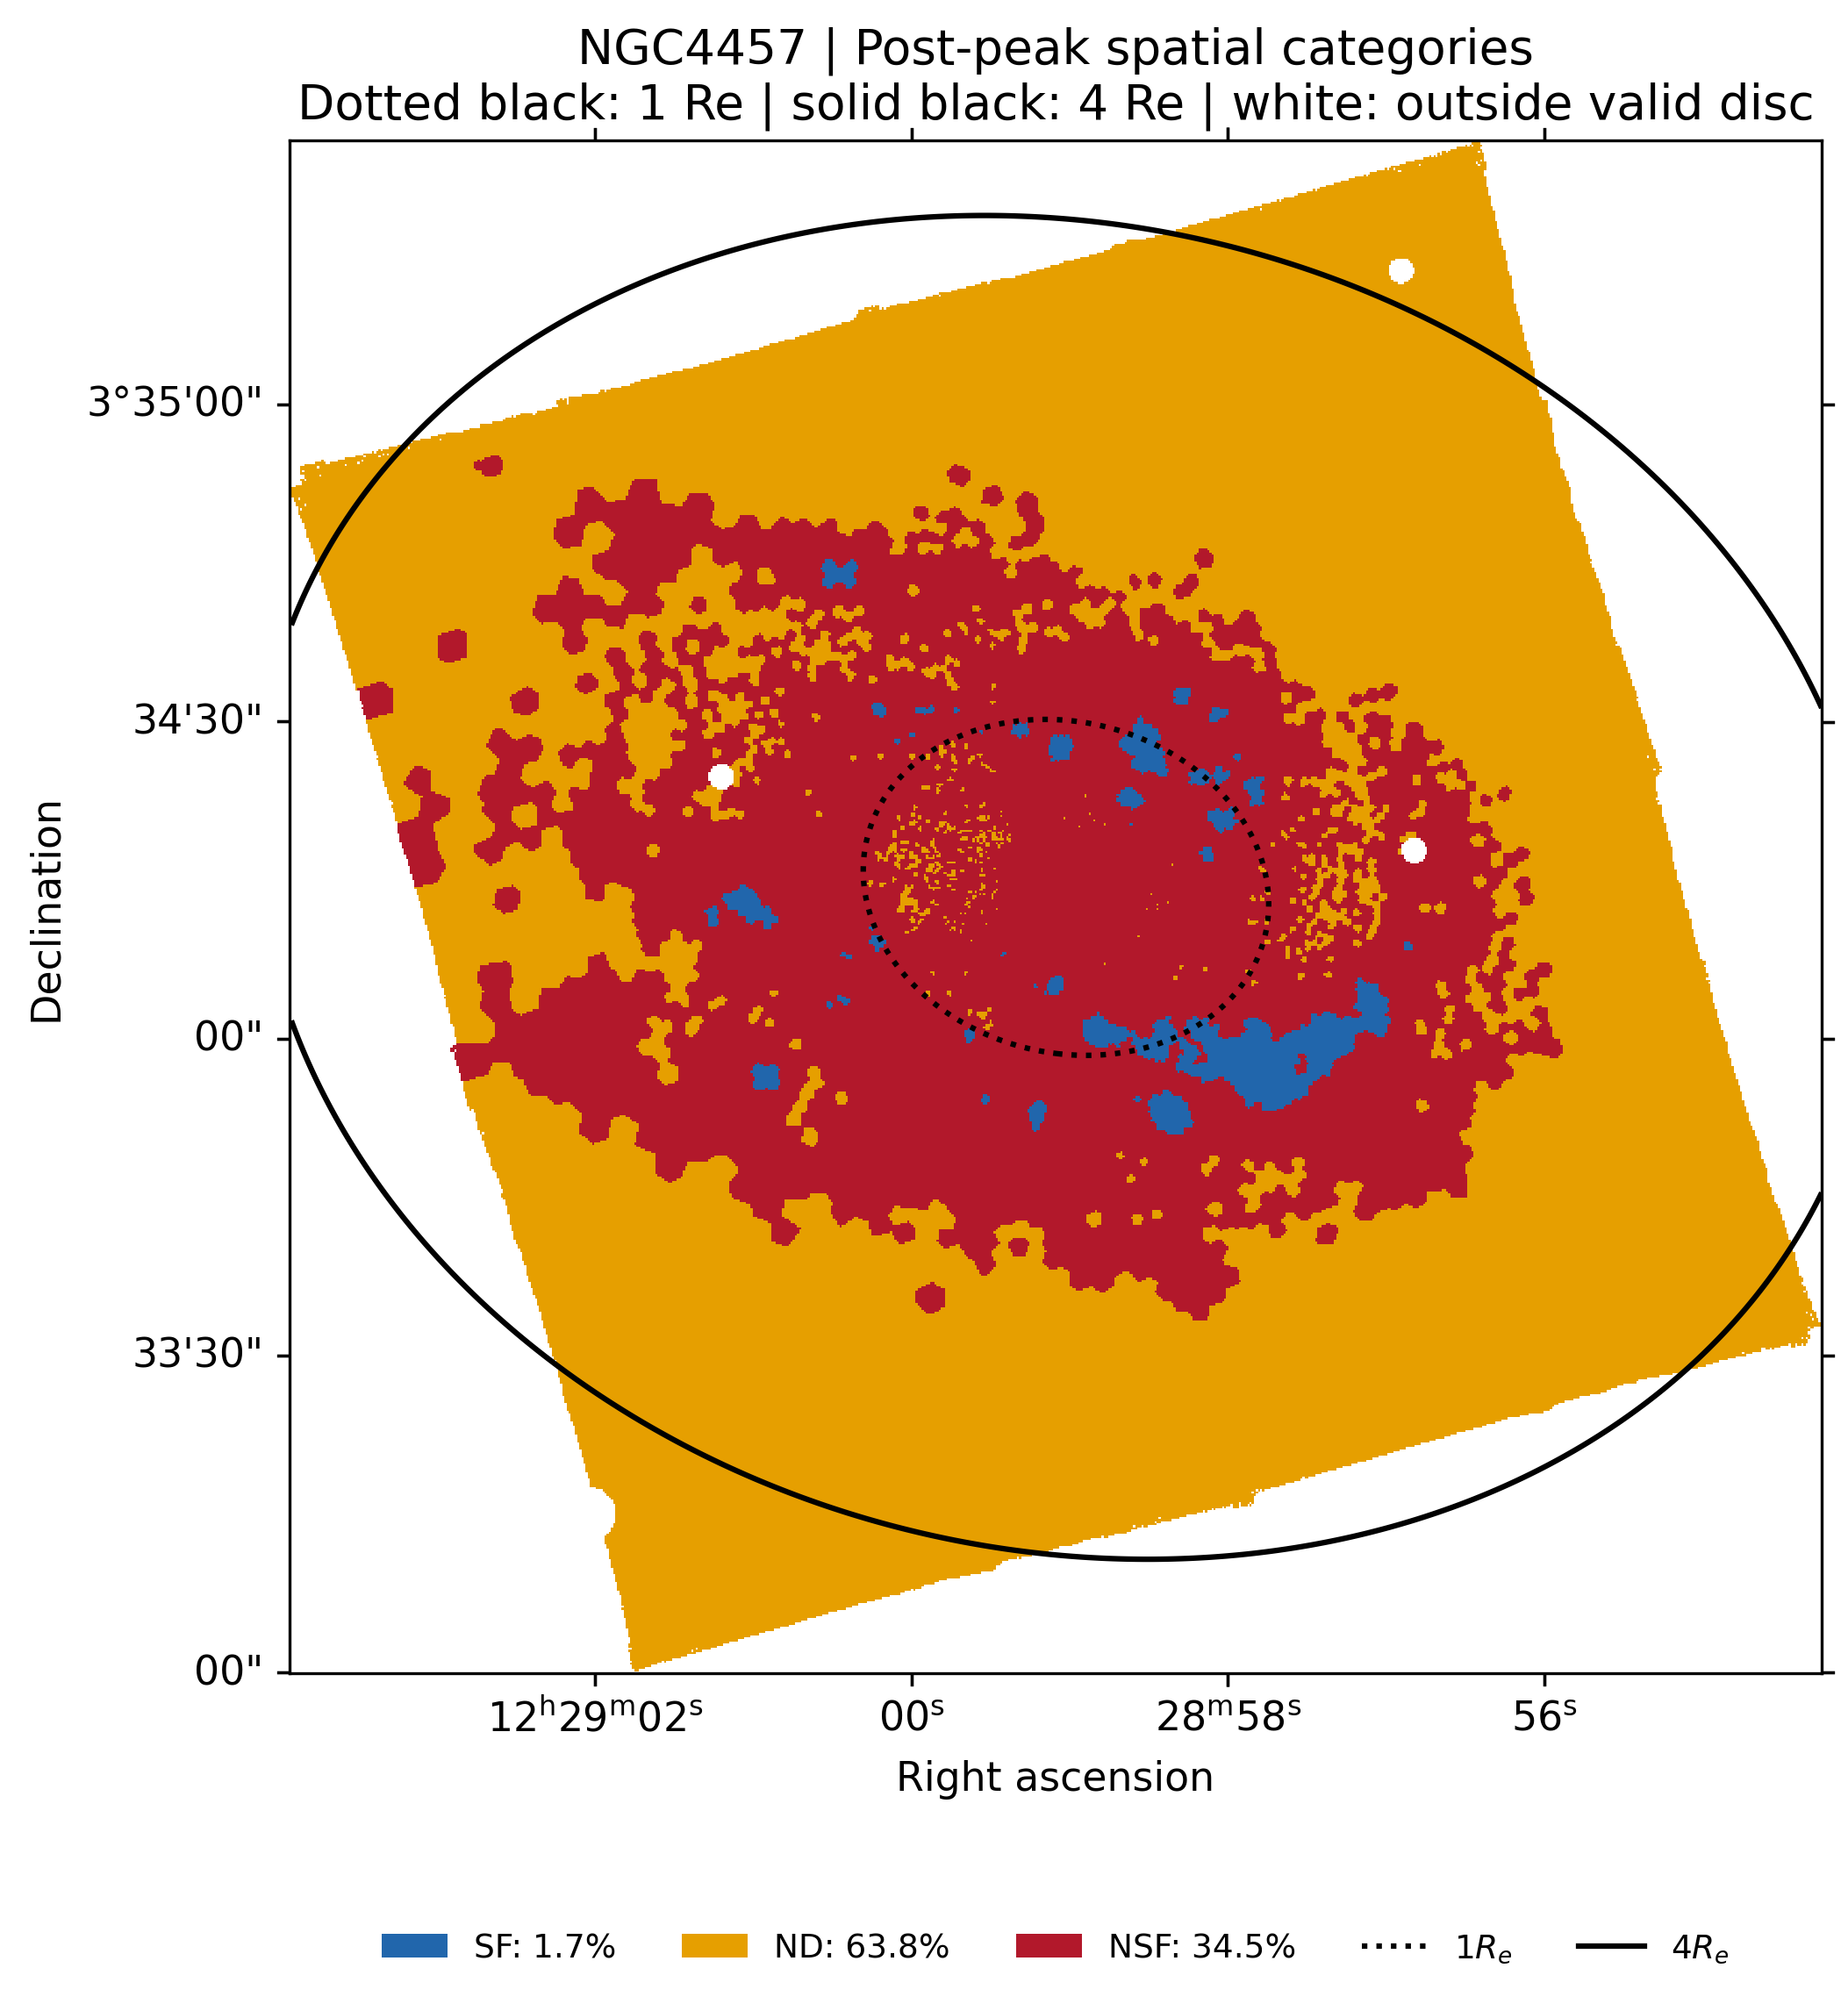

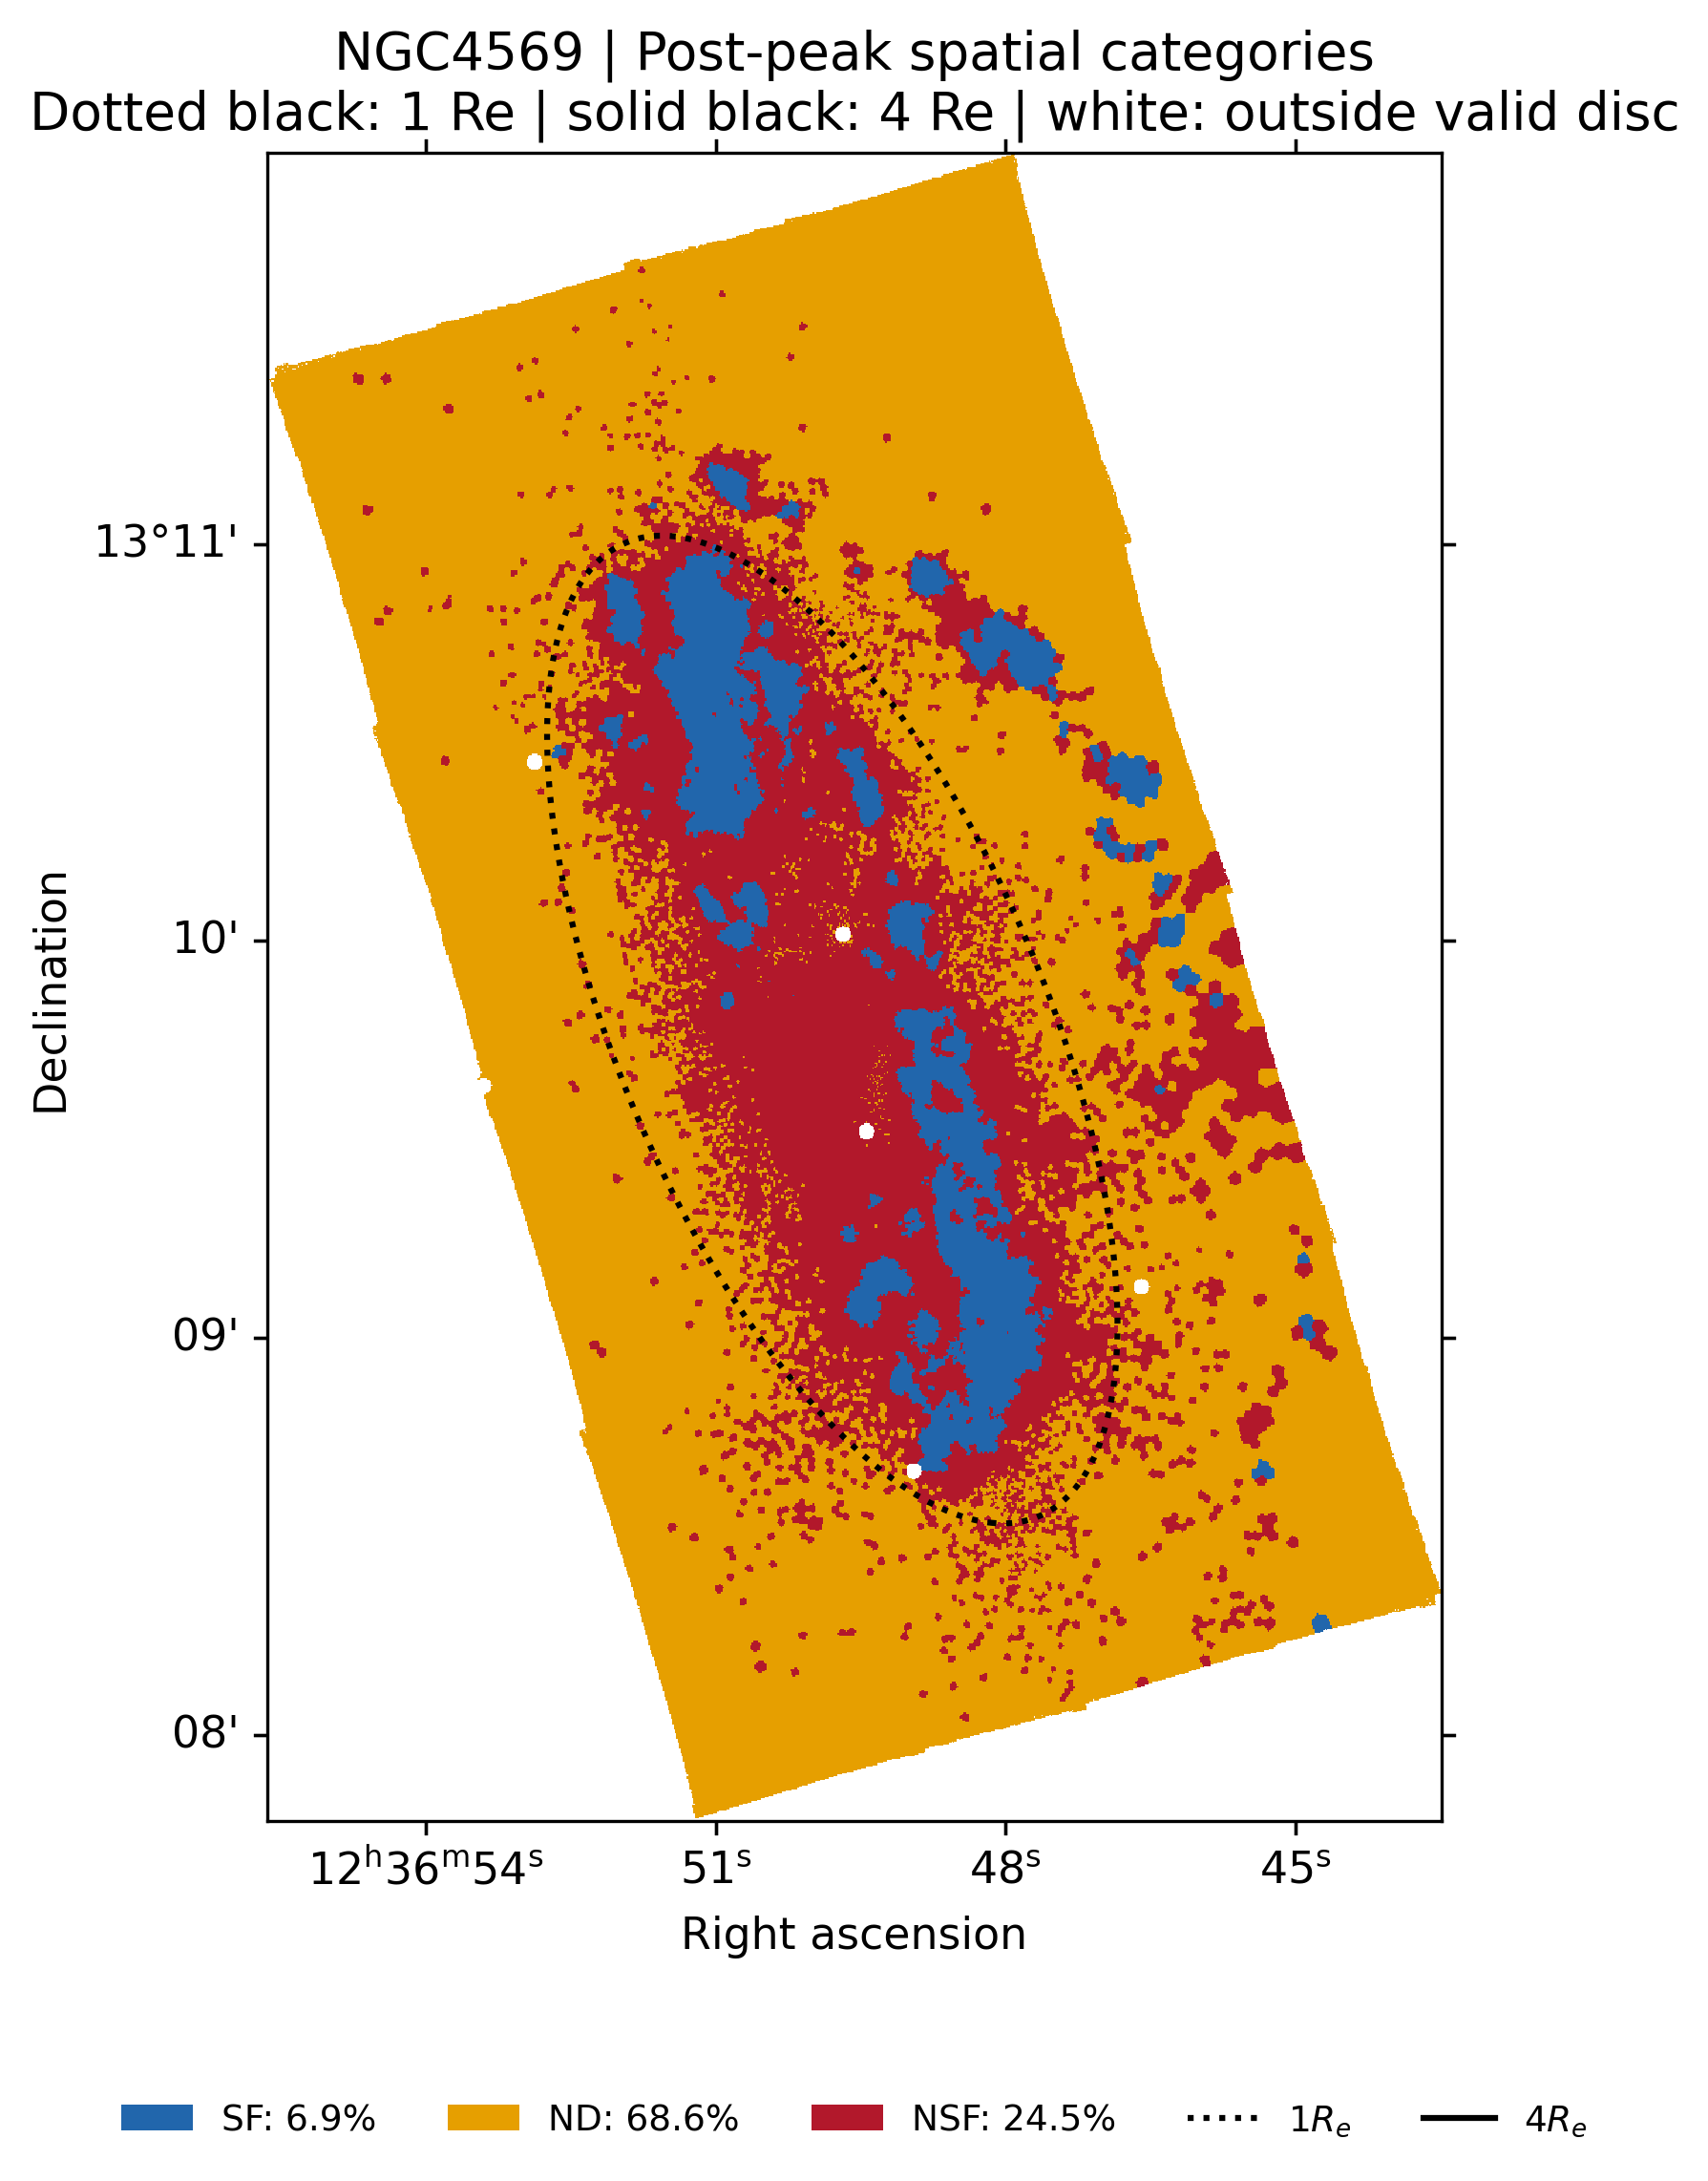

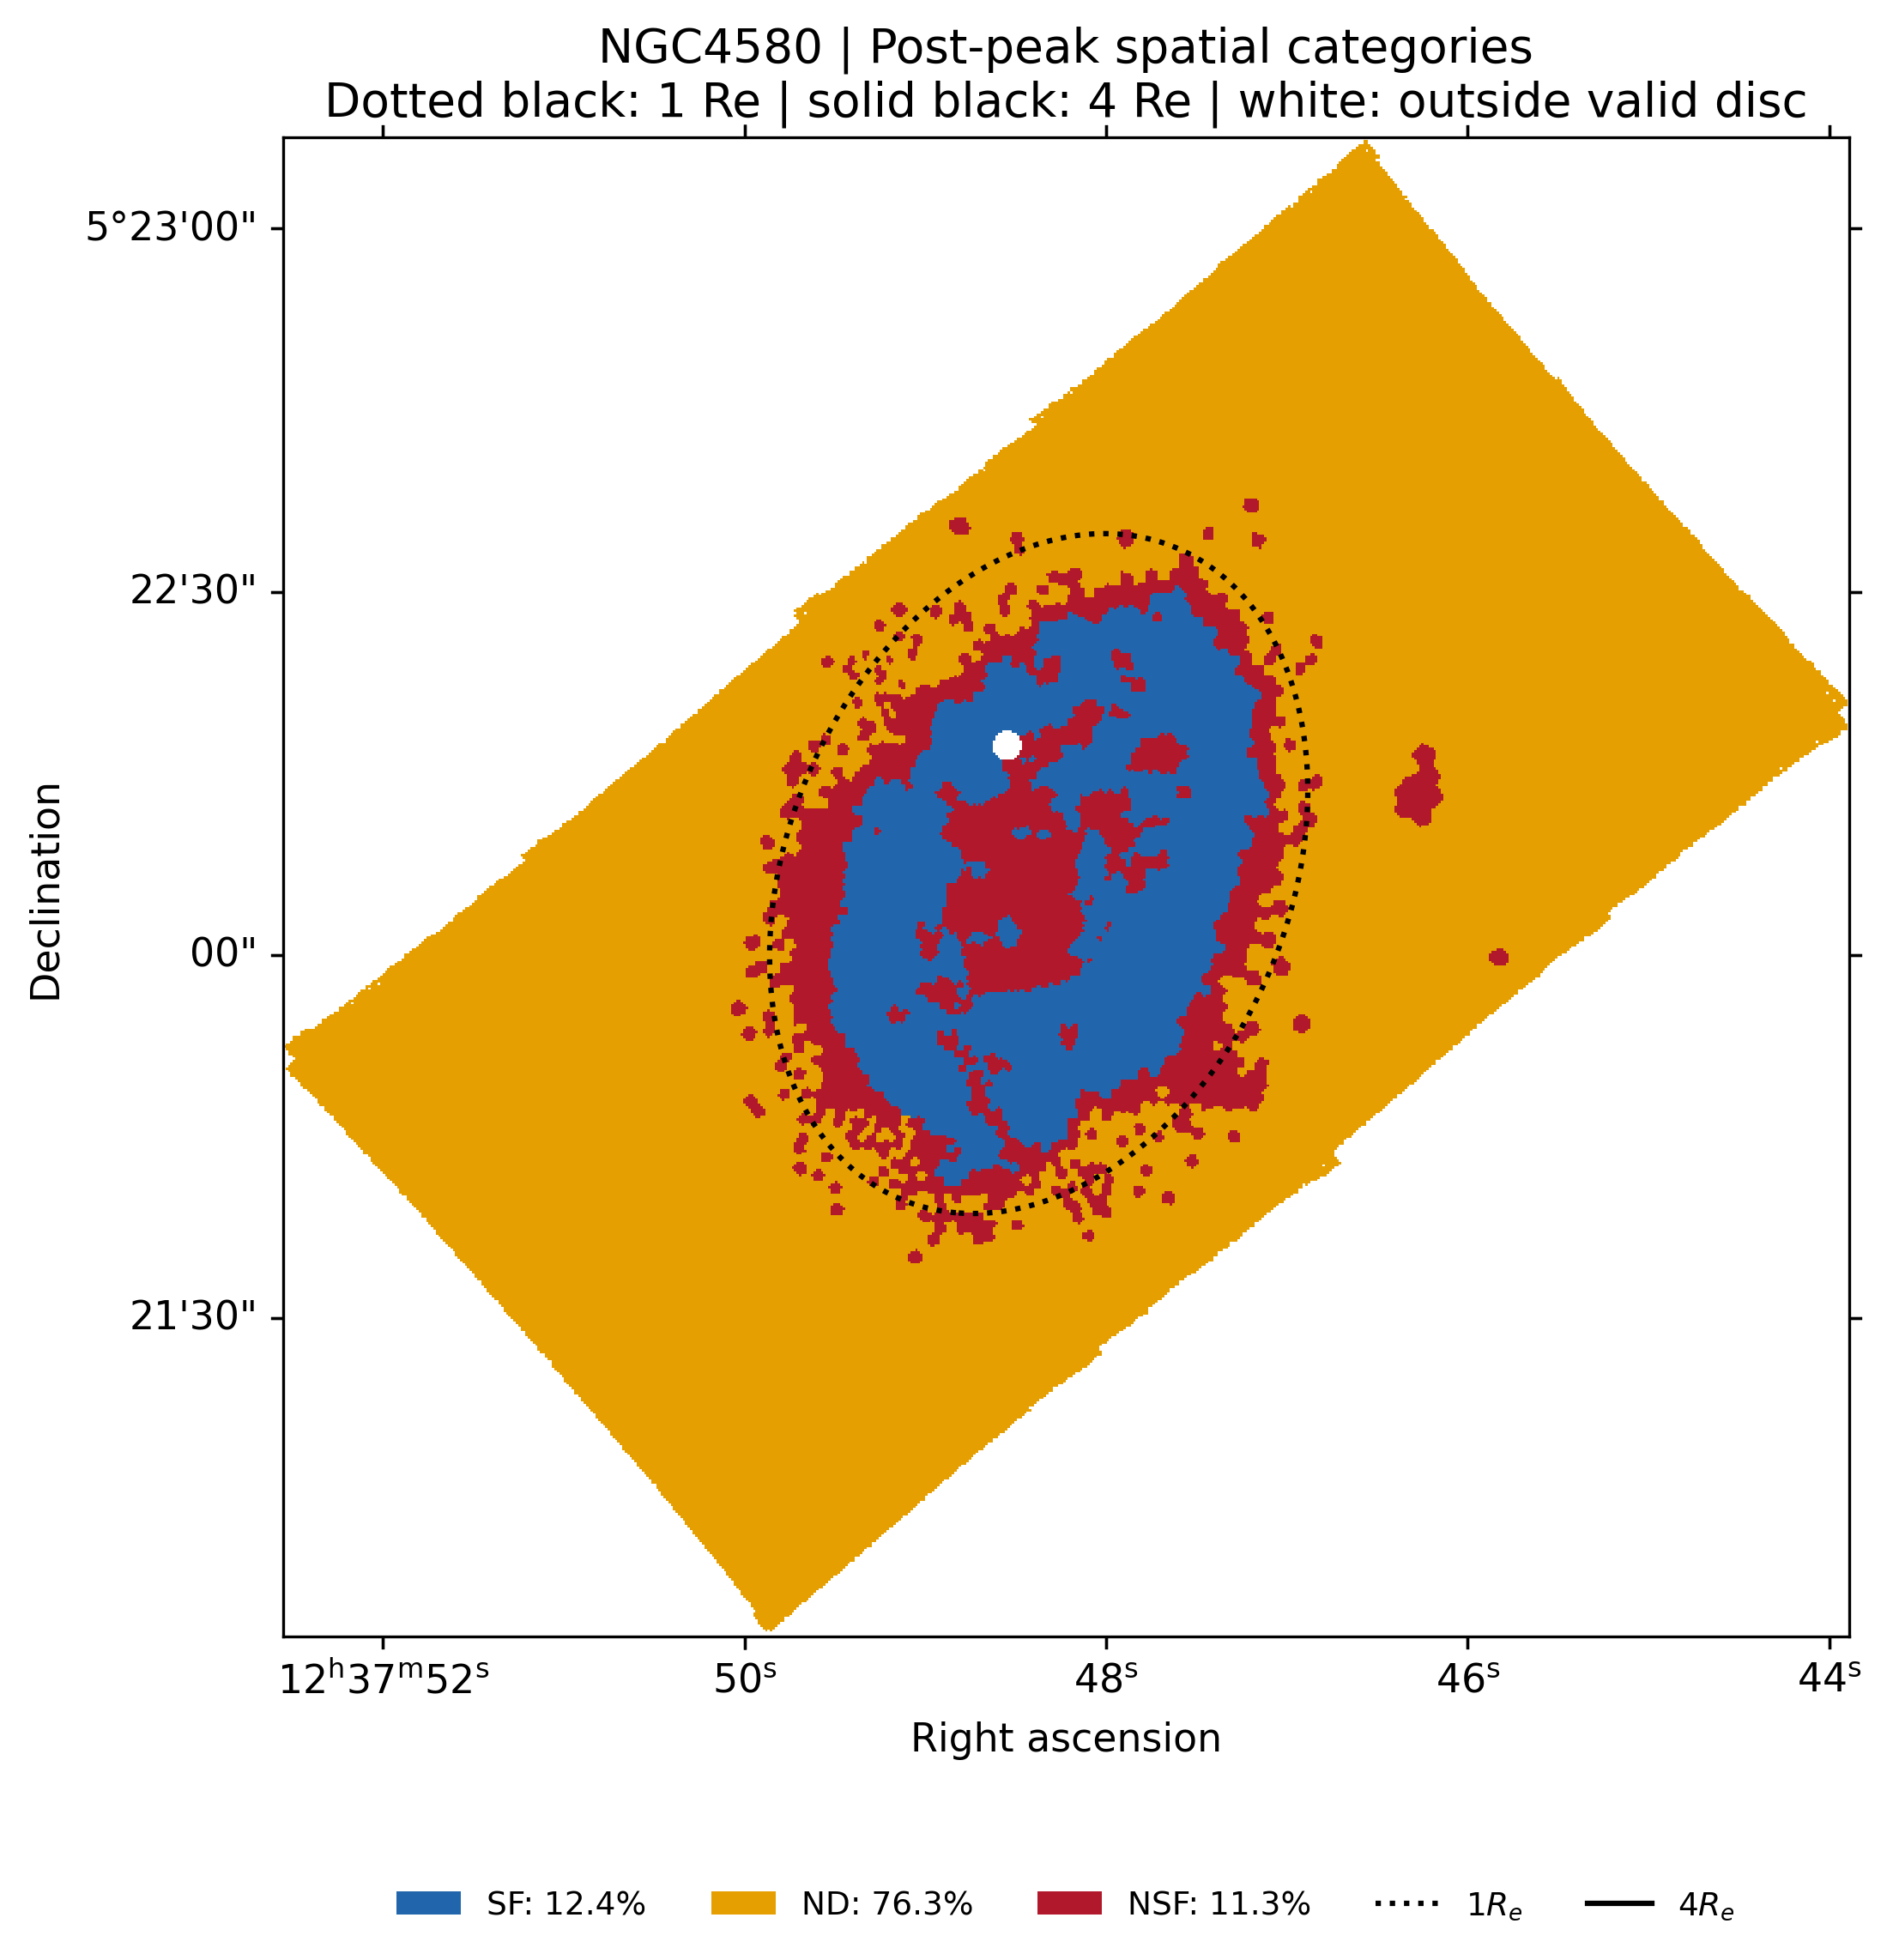

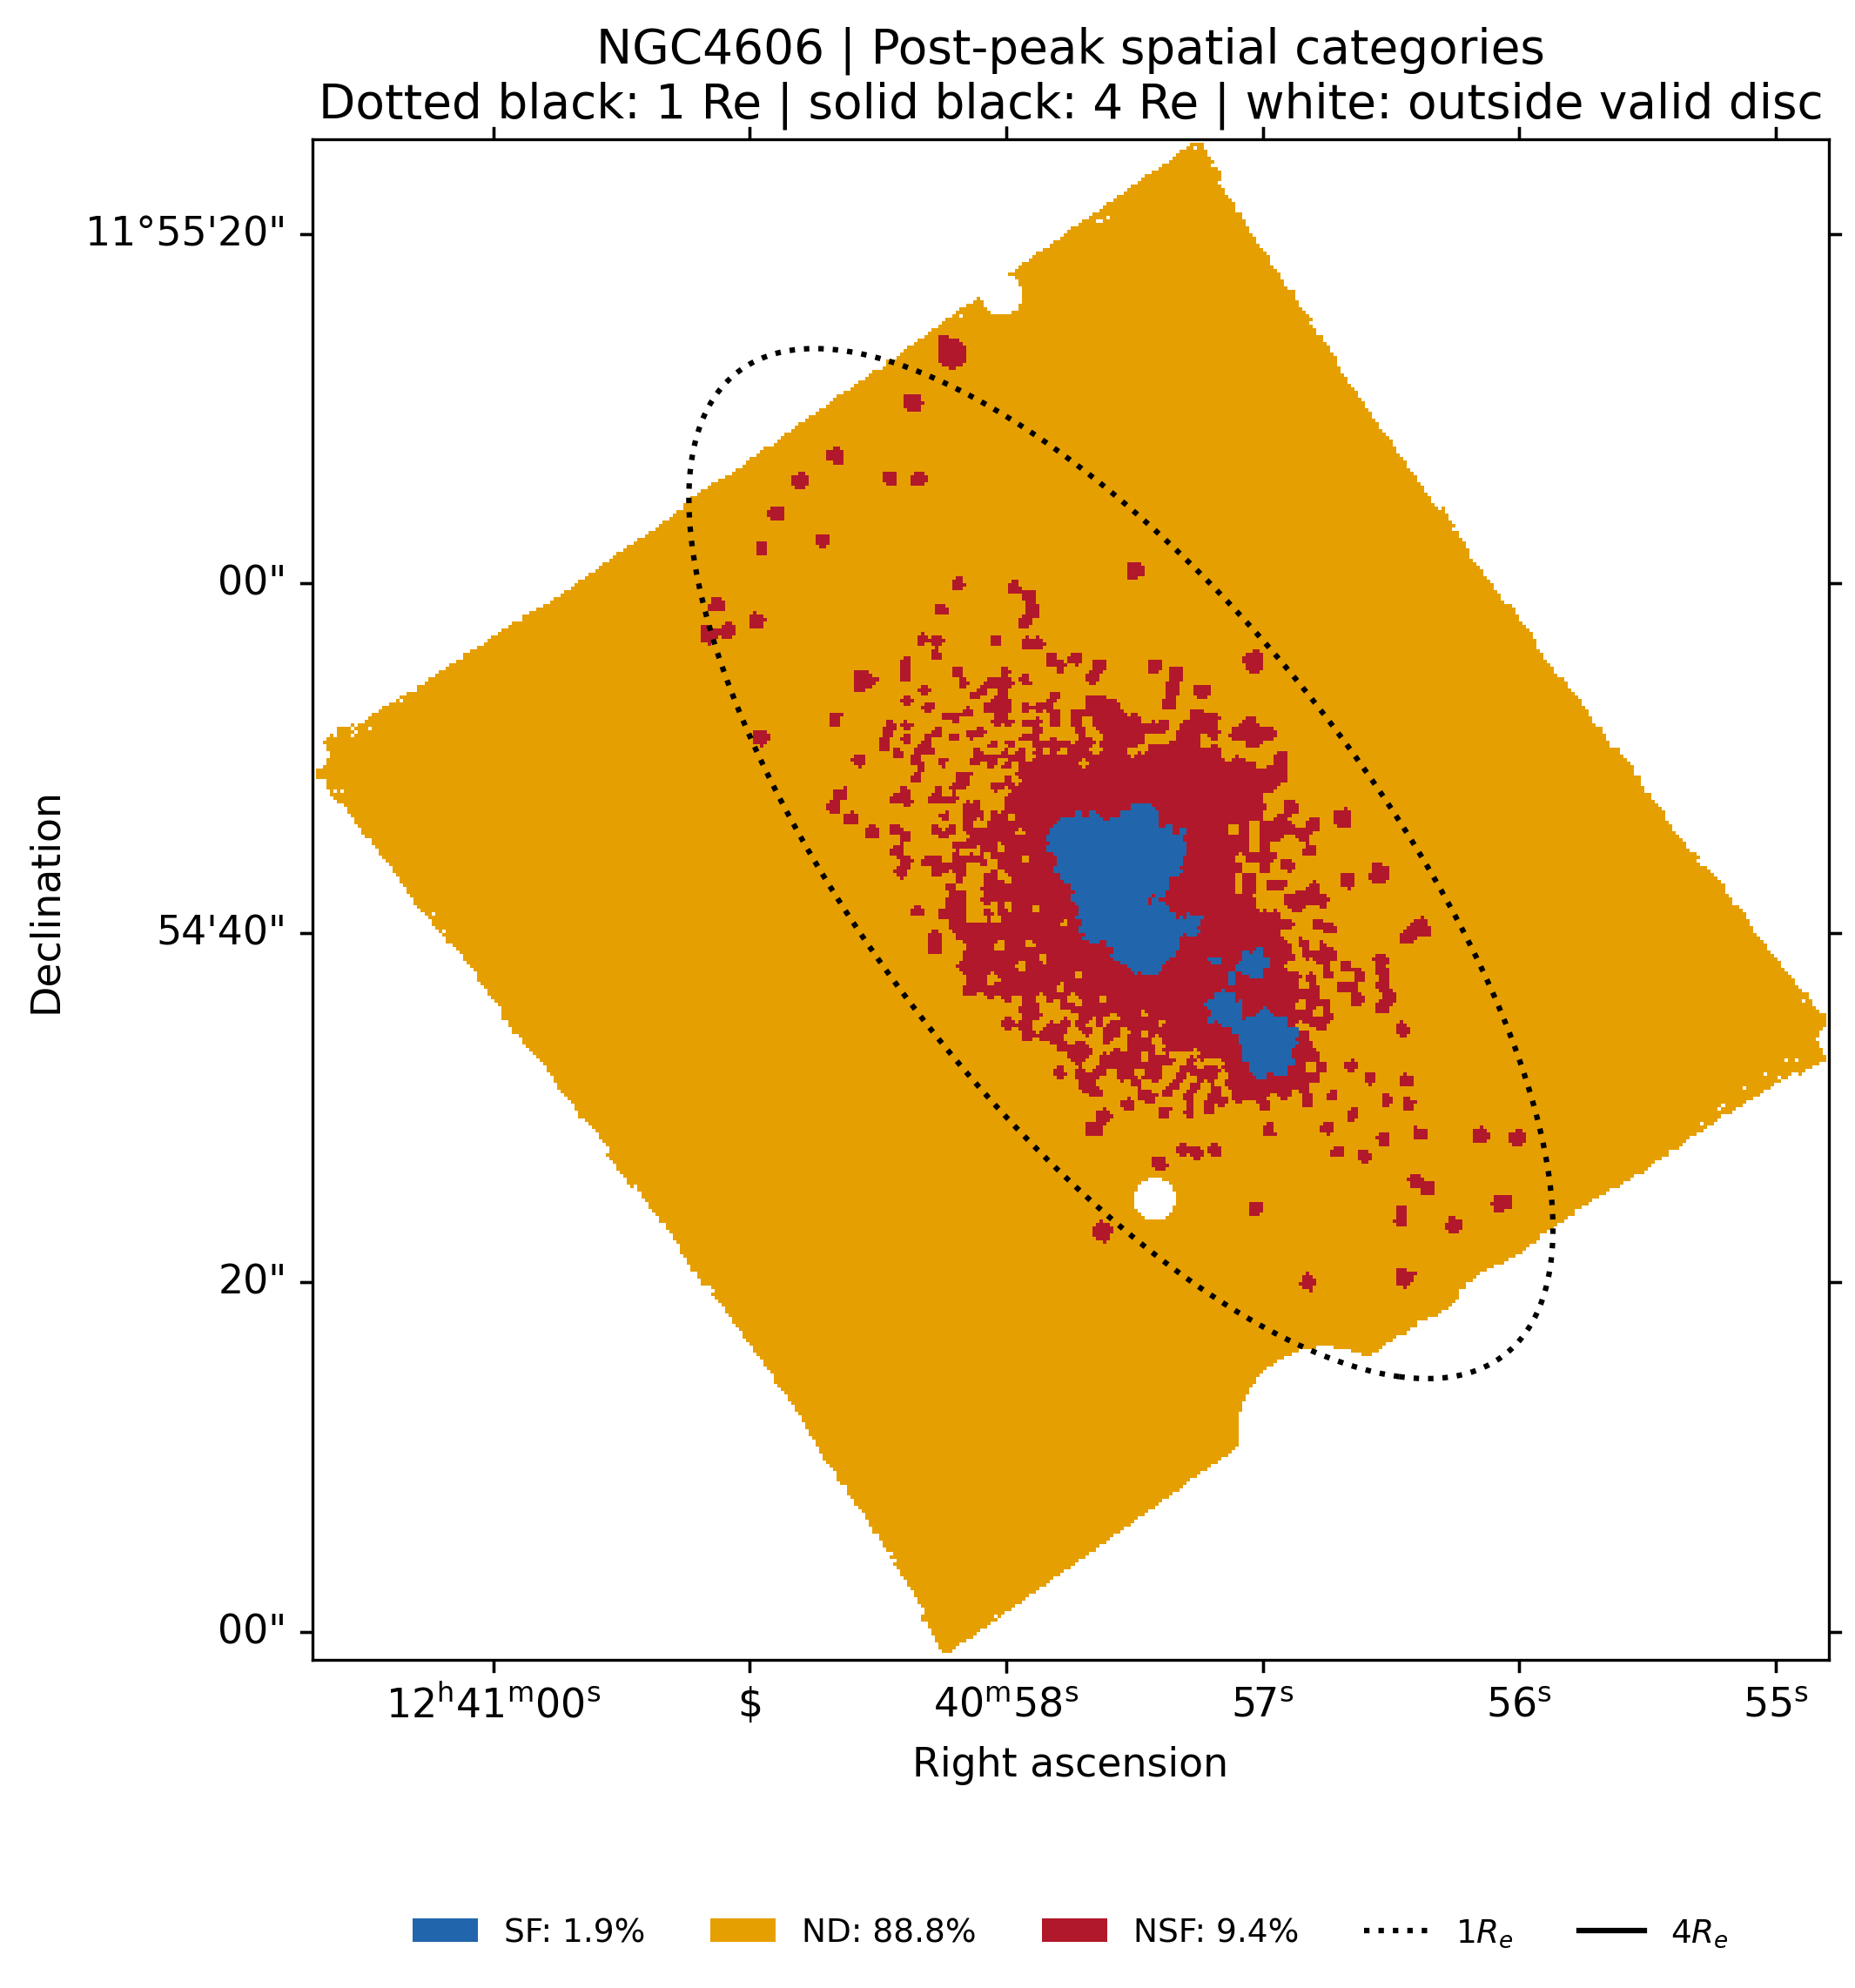

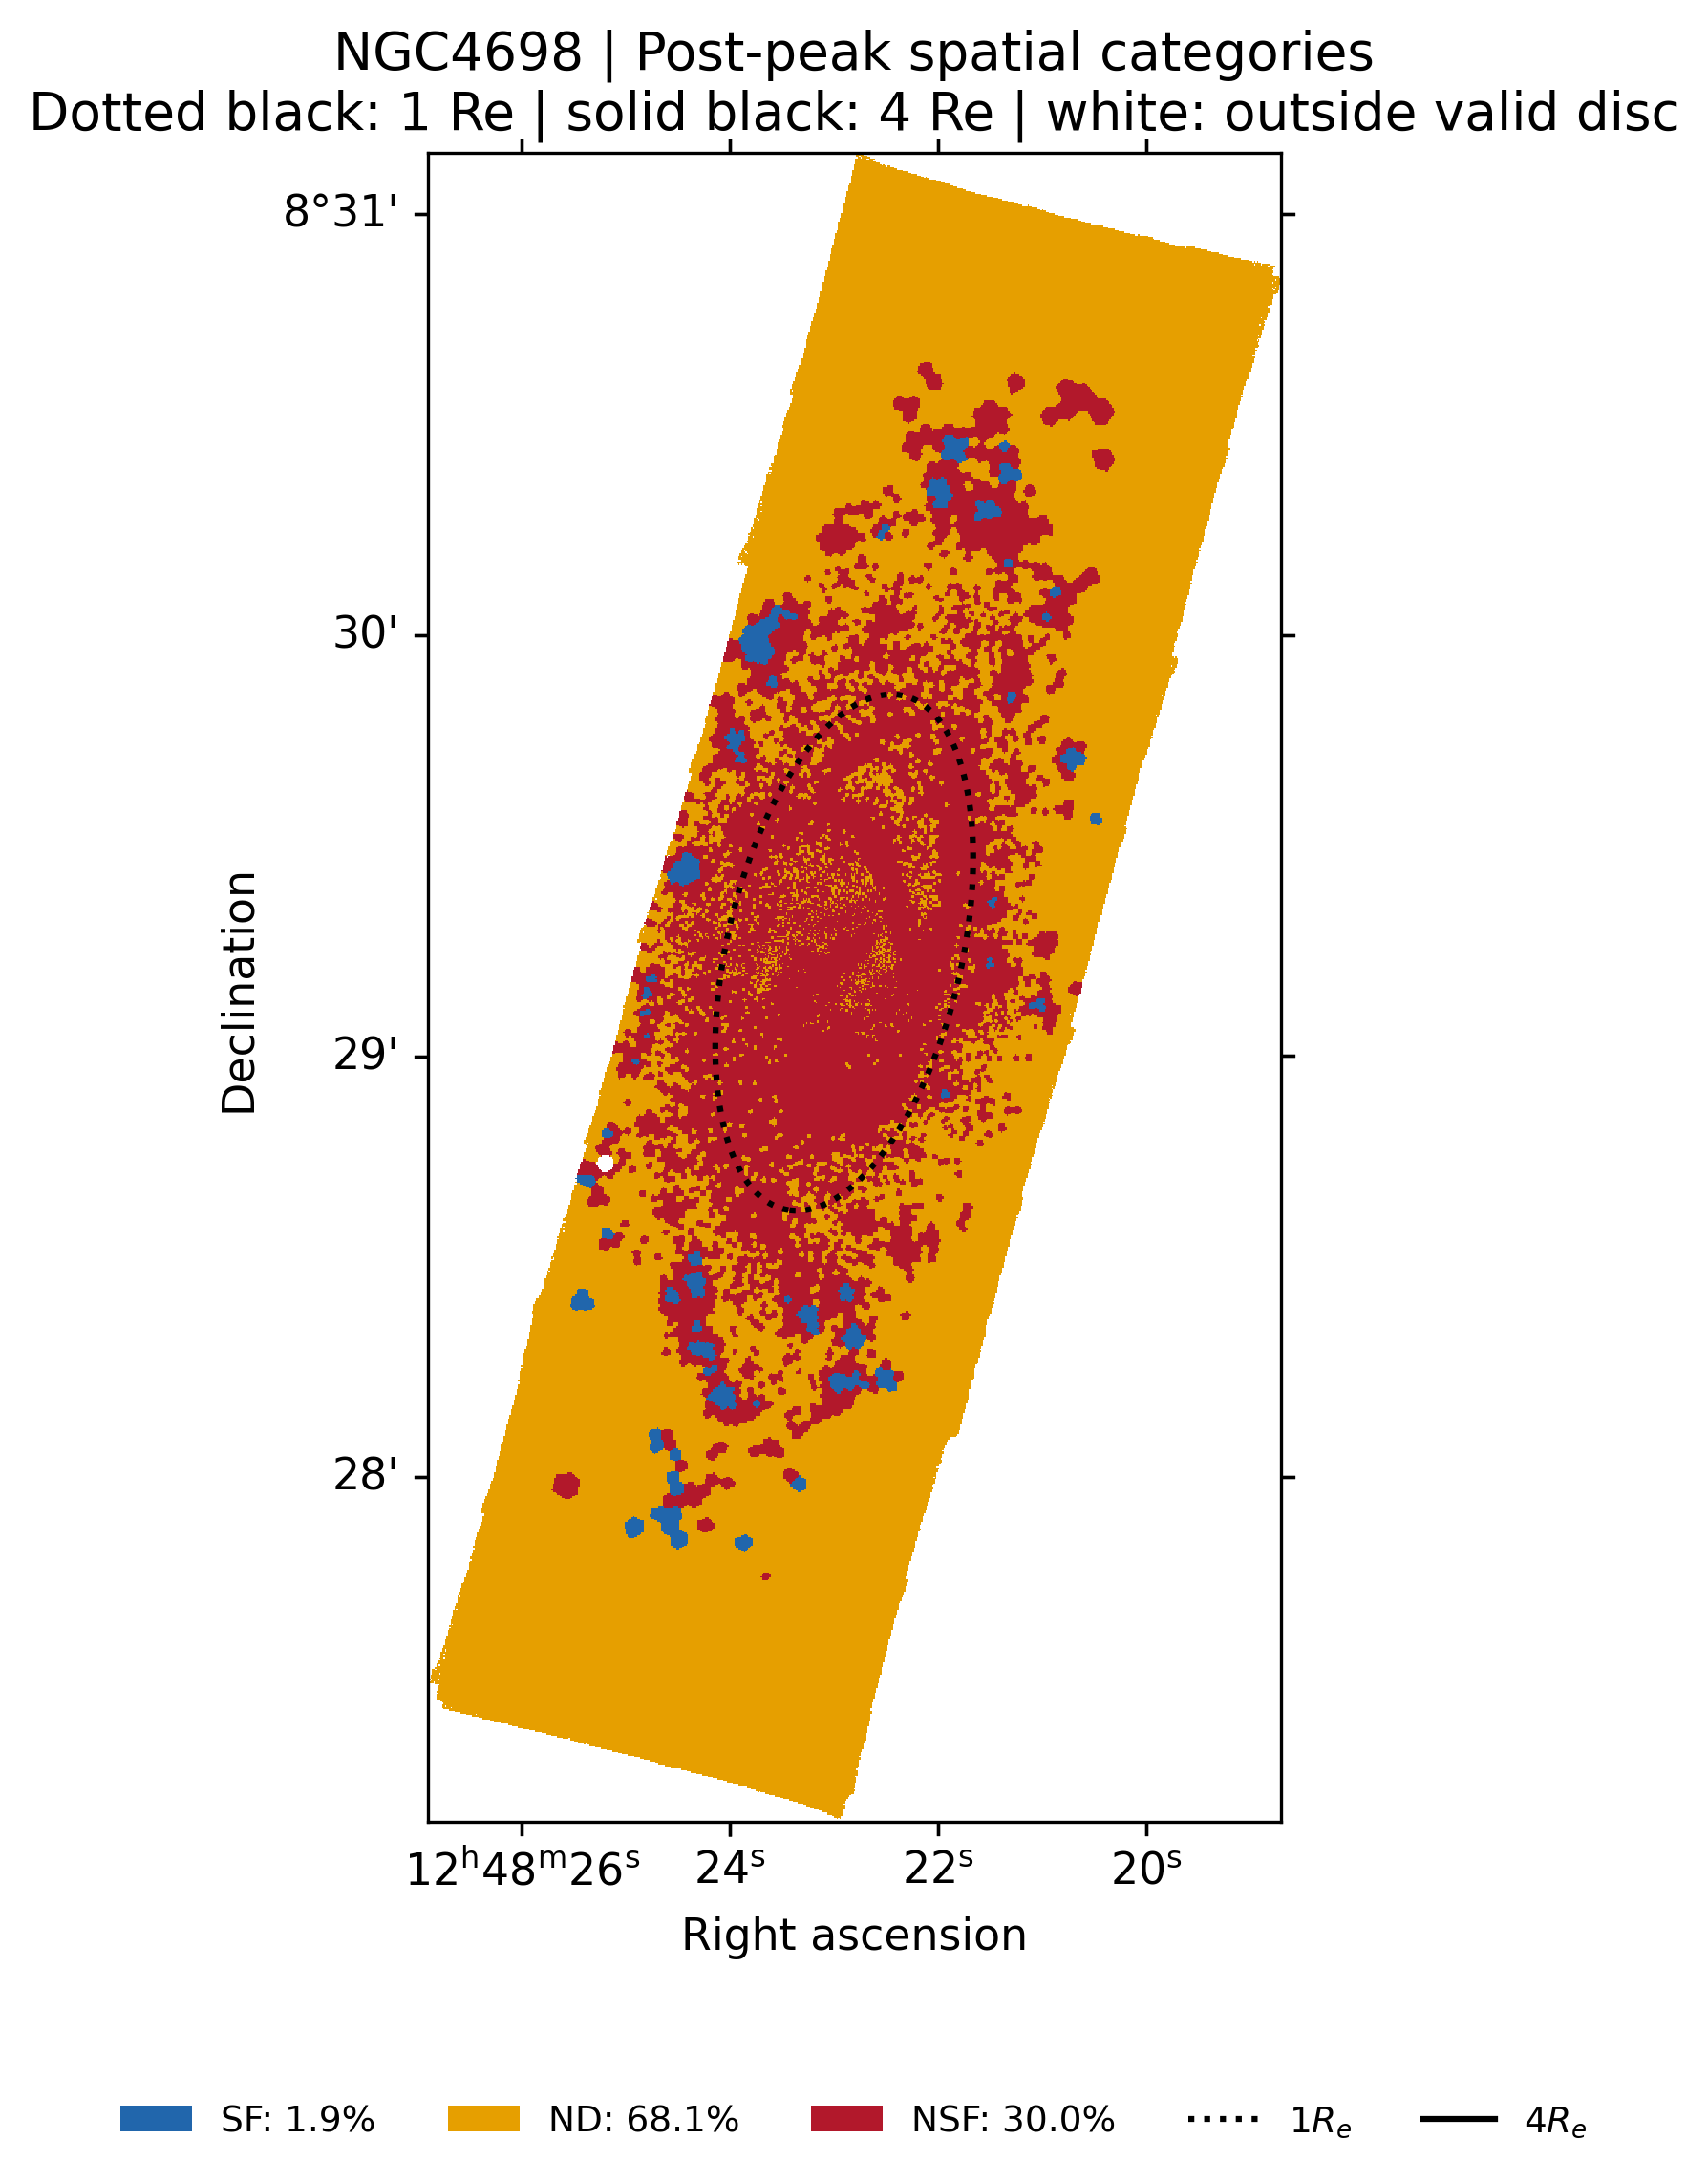

In [12]:
# Spatial SF/ND/NSF categories on the unchanged valid-disc footprint.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

spatial_category_labels = ("SF", "ND", "NSF")
spatial_category_keys = ("sf_mask", "nd_mask", "nsf_mask")
spatial_category_cmap = ListedColormap(
    [CATEGORY_COLORS[label] for label in spatial_category_labels]
)
spatial_category_cmap.set_bad("white")
spatial_category_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)
spatial_radius_levels = (1.0, 4.0)
spatial_radius_linestyles = (":", "-")

spatial_stage_rank = {"pre-peak": 0, "close-to-peak": 1, "post-peak": 2}
spatial_rows = (
    sample.assign(_spatial_stage_rank=sample["stage"].map(spatial_stage_rank))
    .sort_values(["_spatial_stage_rank", "GALID"])
)

for row in spatial_rows.itertuples(index=False):
    maps = load_galaxy_maps(row, geometry)
    valid = maps["valid_disc_mask"]
    category_map = np.full(valid.shape, np.nan)
    for code, key in enumerate(spatial_category_keys):
        category_map[valid & maps[key]] = code

    fig = plt.figure(figsize=(8.5, 7.5), layout="constrained")
    ax = fig.add_subplot(111, projection=WCS(maps["mass_header"]).celestial)
    ax.imshow(
        np.ma.masked_invalid(category_map), origin="lower", interpolation="nearest",
        cmap=spatial_category_cmap, norm=spatial_category_norm, aspect="equal",
    )
    radius_values = maps["radius_re"][valid]
    radius_min, radius_max = np.nanmin(radius_values), np.nanmax(radius_values)
    for level, linestyle in zip(spatial_radius_levels, spatial_radius_linestyles):
        if radius_min <= level <= radius_max:
            ax.contour(
                maps["radius_re"], levels=[level], colors="black",
                linestyles=linestyle, linewidths=1.5, origin="lower",
            )
    ax.coords[0].set_axislabel("Right ascension")
    ax.coords[1].set_axislabel("Declination")
    ax.set_title(
        f"{row.GALID} | {STAGE_LABELS[row.stage]} spatial categories\n"
        "Dotted black: 1 Re | solid black: 4 Re | white: outside valid disc"
    )
    handles = [
        Patch(
            facecolor=CATEGORY_COLORS[label], edgecolor="none",
            label=f"{label}: {np.count_nonzero(valid & maps[key]) / valid.sum():.1%}",
        )
        for label, key in zip(spatial_category_labels, spatial_category_keys)
    ]
    handles.extend([
        Line2D([0], [0], color="black", ls=":", lw=1.5, label=r"$1R_e$"),
        Line2D([0], [0], color="black", ls="-", lw=1.5, label=r"$4R_e$"),
    ])
    ax.legend(
        handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
        ncol=5, frameon=False, fontsize=9,
    )
    plt.show()
    plt.close(fig)
